In [1]:
! pip install obspy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 30.9 MB/s eta 0:00:00


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import obspy
print("obspy version: ",obspy.__version__)

obspy version:  1.5.1


In [2]:
from obspy.clients.fdsn import Client
earthscope=Client("EARTHSCOPE")
print(earthscope)

FDSN Webservice Client (base url: https://service.earthscope.org)
Available Services: 'dataselect' (v1.1.78), 'station' (v1.1.57)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.


In [3]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

usgs = Client("USGS")

start = UTCDateTime("2026-01-01")
end = UTCDateTime("2026-09-21")

catalog = usgs.get_events(
    starttime=start,
    endtime=end,
    minmagnitude=6.0
)

print(catalog)

100 Event(s) in Catalog:
2026-09-20T09:17:35.624000Z |  -5.902, +146.092 | 6.4  mww | manual
2026-09-17T14:19:52.210000Z | +52.859, -171.376 | 6.5  mww | manual
...
2026-01-02T13:58:15.741000Z | +16.798,  -99.394 | 6.5  mww | manual
2026-01-01T01:53:01.809000Z | -45.612,  +96.359 | 6.0  mww | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'


In [4]:
for event in catalog:
    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    print(
        "Time:",
        origin.time,
        "| Lat:", round(origin.latitude, 2),
        "| Lon:", round(origin.longitude, 2),
        "| Depth:", round(origin.depth / 1000, 1), "km",
        "| M:", magnitude.mag
    )

Time: 2026-09-20T09:17:35.624000Z | Lat: -5.9 | Lon: 146.09 | Depth: 104.3 km | M: 6.4
Time: 2026-09-17T14:19:52.210000Z | Lat: 52.86 | Lon: -171.38 | Depth: 98.0 km | M: 6.5
Time: 2026-09-11T21:23:55.907000Z | Lat: -4.98 | Lon: 106.87 | Depth: 372.0 km | M: 6.5
Time: 2026-09-03T11:17:24.056000Z | Lat: 52.26 | Lon: -169.41 | Depth: 35.0 km | M: 6.3
Time: 2026-09-02T23:46:56.213000Z | Lat: -56.07 | Lon: -27.85 | Depth: 111.0 km | M: 6.2
Time: 2026-08-24T14:10:17.347000Z | Lat: -6.66 | Lon: 127.42 | Depth: 10.0 km | M: 6.0
Time: 2026-08-23T13:44:53.389000Z | Lat: 41.85 | Lon: 142.8 | Depth: 41.0 km | M: 6.0
Time: 2026-08-22T08:22:37.923000Z | Lat: -60.32 | Lon: -47.56 | Depth: 10.0 km | M: 6.2
Time: 2026-08-20T18:00:18.619000Z | Lat: -14.57 | Lon: -73.65 | Depth: 99.0 km | M: 6.7
Time: 2026-08-16T03:20:19.914000Z | Lat: -14.5 | Lon: 167.25 | Depth: 146.0 km | M: 6.1
Time: 2026-08-15T10:54:51.798000Z | Lat: 2.99 | Lon: 98.99 | Depth: 175.0 km | M: 6.9
Time: 2026-08-14T22:28:37.743000Z | L

In [5]:
event_time = UTCDateTime("2026-07-17T14:48:39.881000Z")

print("Event time:", event_time)

Event time: 2026-07-17T14:48:39.881000Z


In [6]:
stations = earthscope.get_stations(
    starttime=event_time - 60,
    endtime=event_time + 600,
    level="channel",
    latitude=14.57,
    longitude=-92.96,
    maxradius=10
)

print(stations)

Inventory created at 2026-09-23T12:50:14.449600Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (14):
			CU, G, GE, GI, II, IU, MG, MU, MX, NU, OV, SV, SY, TC
		Stations (244):
			CU.TGUH (Tegucigalpa, Honduras)
			G.HDC (Heredia, Costa Rica)
			G.UNM (Unam - Mexico, Mexico)
			GE.BOA (GEOFON Station Boaco, Nicaragua)
			GE.BOAB (INETER/GEOFON Station Boaco, Nicaragua)
			GI.AVCS (Chisec, Alta Verapax)
			GI.AVPA (Panzos, Alta Verapaz)
			GI.CHIE (Esquipulas, Chiquimula)
			GI.CMSM (San Martin Jilotepeque, Chimaltenango)
			GI.ESTQ (Tiquisate, Escuintla)
			GI.GCG3 (INSIVUMEH, Guatemala)
			GI.GUMI (Lo de Coy, Mixco, Guatemala)
			GI.GUNB (GUNB)
			GI.GUSP (San Jose Pinula, Guatemala)
			GI.GUVC (Villa Canales, Guatemala)
			GI.HUBA (Santa Cruz Barillas, Huehuetenango)
			GI.HUCU (Cuilco, Huehuetenango)
			GI.HUEH (Huehu

In [7]:
from math import radians, sin, cos, asin, sqrt

def distance_deg(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))

    return c * 180 / 3.141592653589793


station_list = []

for net in stations:
    # Ignore synthetic stations
    if net.code == "SY":
        continue

    for sta in net:
        channels = [cha.code for cha in sta]

        # We want a vertical component
        if "BHZ" in channels or "HHZ" in channels:

            distance = distance_deg(
                14.57,
                -92.96,
                sta.latitude,
                sta.longitude
            )

            station_list.append(
                (
                    distance,
                    net.code,
                    sta.code,
                    sta.latitude,
                    sta.longitude,
                    "BHZ" if "BHZ" in channels else "HHZ"
                )
            )

station_list.sort()

for row in station_list[:20]:
    print(row)

(1.225342816869424, 'GI', 'RETA', 14.524621, -91.694939, 'HHZ')
(1.28807518966878, 'GI', 'HUCU', 15.407847, -91.947188, 'HHZ')
(1.3579464204685345, 'GI', 'SUCU', 14.56, -91.557, 'HHZ')
(1.5945701343951102, 'GI', 'HUEH', 15.318176, -91.502541, 'HHZ')
(1.7611583096415253, 'GI', 'ESTQ', 14.15158, -91.19408, 'HHZ')
(1.8867712357167563, 'MX', 'CCIG', 16.281799, -92.136803, 'BHZ')
(2.0340201632723227, 'GI', 'HUBA', 15.816578, -91.294484, 'HHZ')
(2.1063852799680585, 'GI', 'CMSM', 14.782826, -90.793703, 'HHZ')
(2.177596334653952, 'GI', 'SASJ', 14.483898, -90.712236, 'HHZ')
(2.285366854927362, 'GI', 'GUMI', 14.621, -90.599, 'HHZ')
(2.3833211768029425, 'GI', 'GUVC', 14.532, -90.498, 'HHZ')
(2.4721610116484958, 'GI', 'SRIX', 14.171699, -90.441307, 'HHZ')
(2.530577222427194, 'GI', 'GUNB', 14.595731, -90.345306, 'HHZ')
(2.5470758760092433, 'GI', 'QCIX', 16.003414, -90.777245, 'HHZ')
(2.558350770467267, 'GI', 'GUSP', 14.552, -90.3168, 'HHZ')
(2.696203216057268, 'GI', 'SROR', 14.231059, -90.198398, '

In [8]:
import requests

url = "https://service.earthscope.org/irisws/fedcatalog/1/query"

params = {
    "targetservice": "dataselect",
    "format": "text",
    "cha": "HHZ",
    "latitude": 14.57,
    "longitude": -92.96,
    "maxradius": 10,
    "starttime": str(event_time - 10),
    "endtime": str(event_time + 120),
    "includeavailability": "true",
    "matchtimeseries": "true",
    "nodata": 404
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)
print(response.text)

Status code: 200
#Network | Station | Location | Channel | Latitude | Longitude | Elevation | Depth | Azimuth | Dip | SensorDescription | Scale | ScaleFreq | ScaleUnits | SampleRate | StartTime | EndTime

#DATACENTER=GEOFON,http://geofon.gfz-potsdam.de
GE|BOAB||HHZ|12.4493|-85.6659|381.0|5.0|0.0|-90.0|UNKNOWN|5.934596804162023E8|1.0|m/s|100.0|2025-05-13T08:49:53|2599-12-31T23:59:59
NU|ACON||HHZ|11.968|-85.174|107.0|0.0|0.0|-90.0|GFZ:NU1980:Trillium-40/g=1500|1.5E9|0.1|M/S|100.0|2006-09-08T00:00:00|2008-01-01T00:00:00
NU|BLUN||HHZ|12.0052|-83.7763|50.0|0.0|0.0|-90.0|GFZ:NU1980:Trillium-40/g=1500|1.5E9|0.1|M/S|100.0|2006-09-08T00:00:00|2599-12-31T23:59:59
NU|BOAB||HHZ|12.4493|-85.6659|381.0|5.0|0.0|-90.0|GFZ:NU1980:STS-2/N/g=1500|1.5E9|0.02|M/S|100.0|2004-01-01T00:00:00|2599-12-31T23:59:59
NU|CNGN||HHZ|12.5|-86.6985|515.0|0.0|0.0|-90.0|GFZ:NU1980:Trillium-40/g=1500|1.5E9|0.1|M/S|100.0|2006-09-08T00:00:00|2008-01-01T00:00:00
NU|CRIN||HHZ|12.7|-87.05|685.0|0.0|0.0|-90.0|GFZ:NU1980:Trillium

In [9]:
import requests

url = "https://service.earthscope.org/irisws/fedcatalog/1/query"

params = {
    "net": "GI",
    "sta": "RETA",
    "loc": "--",
    "cha": "HHZ",
    "starttime": str(event_time - 60),
    "endtime": str(event_time + 600),
    "targetservice": "dataselect",
    "format": "request",
    "includeoverlaps": "true"
}

response = requests.get(url, params=params)

print("Status:", response.status_code)
print(response.text)

Status: 200

DATACENTER=IRISDMC,https://www.earthscope.org/data/
DATASELECTSERVICE=https://service.earthscope.org/fdsnws/dataselect/1/
GI RETA -- HHZ 2026-07-17T14:47:39 2026-07-17T14:58:39





In [10]:
from obspy import UTCDateTime

candidate_stations = [
    ("GI", "RETA"),
    ("GI", "HUCU"),
    ("GI", "SUCU"),
    ("GI", "HUEH"),
    ("GI", "ESTQ"),
    ("MX", "CCIG"),
    ("GI", "HUBA"),
    ("GI", "CMSM"),
    ("GI", "SASJ"),
    ("GI", "GUMI"),
    ("GI", "GUVC"),
    ("GI", "SRIX"),
    ("GI", "GUNB"),
    ("GI", "QCIX"),
    ("GI", "GUSP"),
    ("GI", "SROR"),
    ("GI", "AVCS"),
    ("GI", "JAMO"),
    ("SV", "NUBE"),
    ("SV", "RBDL")
]

successful = []

for network, station in candidate_stations:

    try:
        st = earthscope.get_waveforms(
            network=network,
            station=station,
            location="--",
            channel="HHZ",
            starttime=event_time - 60,
            endtime=event_time + 600
        )

        print("DATA FOUND:", network, station)
        print(st)

        successful.append((network, station, st))

    except Exception:
        print("No data:", network, station)

print("\nSuccessful stations:", len(successful))

No data: GI RETA
DATA FOUND: GI HUCU
1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples
DATA FOUND: GI SUCU
1 Trace(s) in Stream:
GI.SUCU..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
No data: GI HUEH
No data: GI ESTQ
No data: MX CCIG
No data: GI HUBA
No data: GI CMSM
No data: GI SASJ
No data: GI GUMI
DATA FOUND: GI GUVC
1 Trace(s) in Stream:
GI.GUVC..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
No data: GI SRIX
No data: GI GUNB
DATA FOUND: GI QCIX
1 Trace(s) in Stream:
GI.QCIX..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
DATA FOUND: GI GUSP
1 Trace(s) in Stream:
GI.GUSP..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
DATA FOUND: GI SROR
1 Trace(s) in Stream:
GI.SROR..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 H

In [11]:
st_hucu = earthscope.get_waveforms(
    network="GI",
    station="HUCU",
    location="--",
    channel="HHZ",
    starttime=event_time - 60,
    endtime=event_time + 600
)

print(st_hucu)

1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples


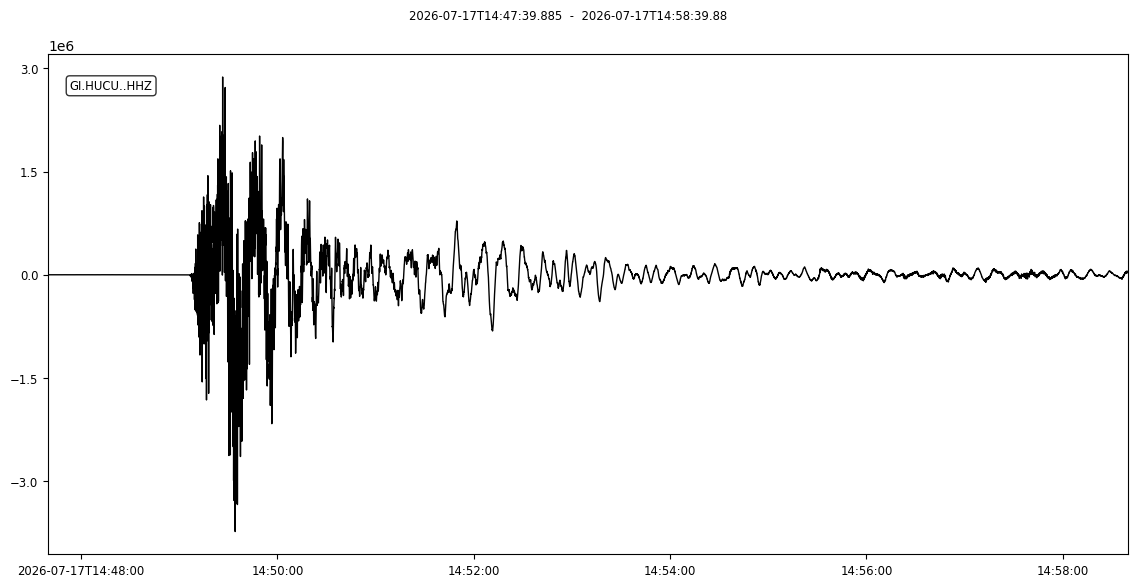

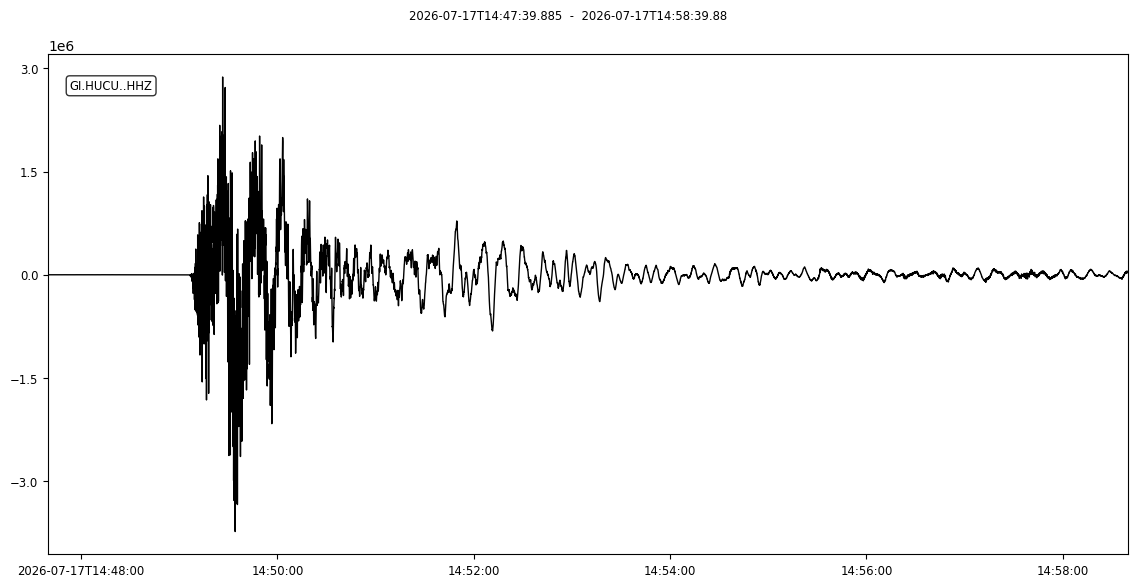

In [12]:
st_hucu.plot(

    size=(1200,600),
    equal_scale=False

)

In [13]:
st_processed = st_hucu.copy()
print(st_processed)

1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples


In [14]:
"""dtrending: Real seismic recordings can contain a slow baseline drift. Ideally, the signal should fluctuate around zero.
detrend("linear") removes a best-fit straight-line trend from the data."""

st_processed.detrend("linear")

1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples

In [15]:
"""This gradually reduces the first and last 5% of the trace toward zero."""

st_processed.taper(max_percentage=0.05)

1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples

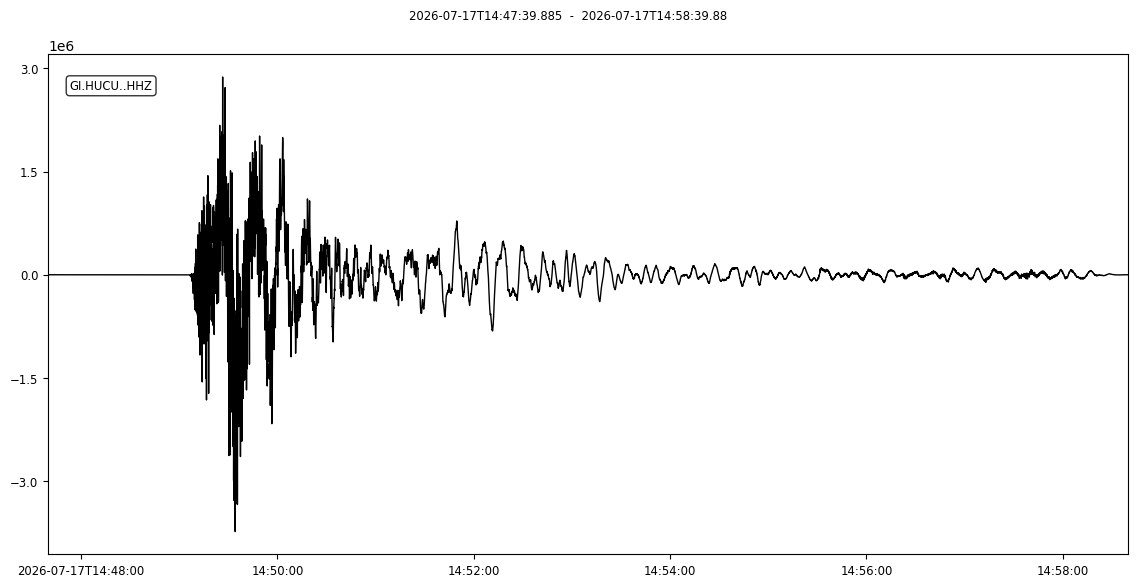

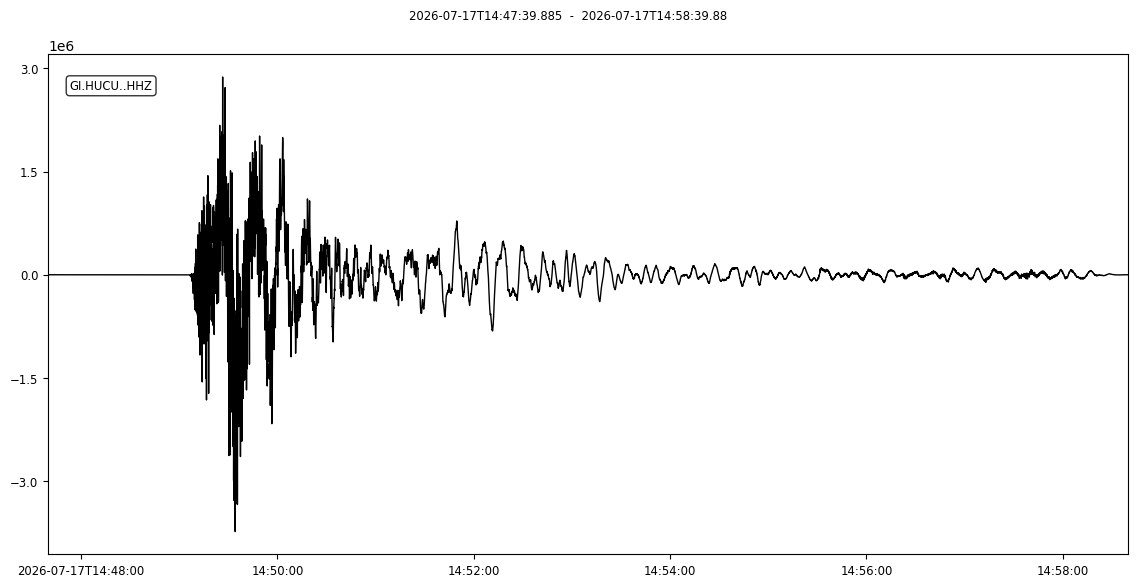

In [16]:
st_processed.plot(
    size=(1200, 600),
    equal_scale=False
)

In [17]:
print("Raw mean:", st_hucu[0].data.mean())
print("Processed mean:", st_processed[0].data.mean())

print("Raw max:", st_hucu[0].data.max())
print("Processed max:", st_processed[0].data.max())

Raw mean: 106.9764696969697
Processed mean: 48.13911269888381
Raw max: 2872991
Processed max: 2873067.206905954


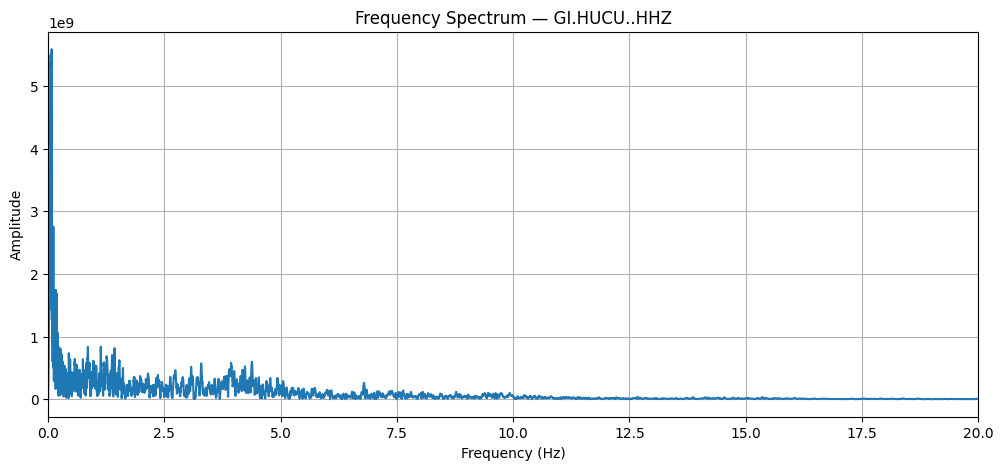

In [18]:
tr = st_processed[0]

data = tr.data
n = len(data)
dt = tr.stats.delta

freq = np.fft.rfftfreq(n, d=dt)
spectrum = np.abs(np.fft.rfft(data))

plt.figure(figsize=(12, 5))
plt.plot(freq, spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum — GI.HUCU..HHZ")
plt.xlim(0, 20)
plt.grid()
plt.show()

In [19]:
st_filtered = st_processed.copy()

st_filtered.filter(
    "bandpass",
    freqmin=0.05,
    freqmax=5.0,
    corners=4,
    zerophase=True
)

1 Trace(s) in Stream:
GI.HUCU..HHZ | 2026-07-17T14:47:39.885000Z - 2026-07-17T14:58:39.880000Z | 200.0 Hz, 132000 samples

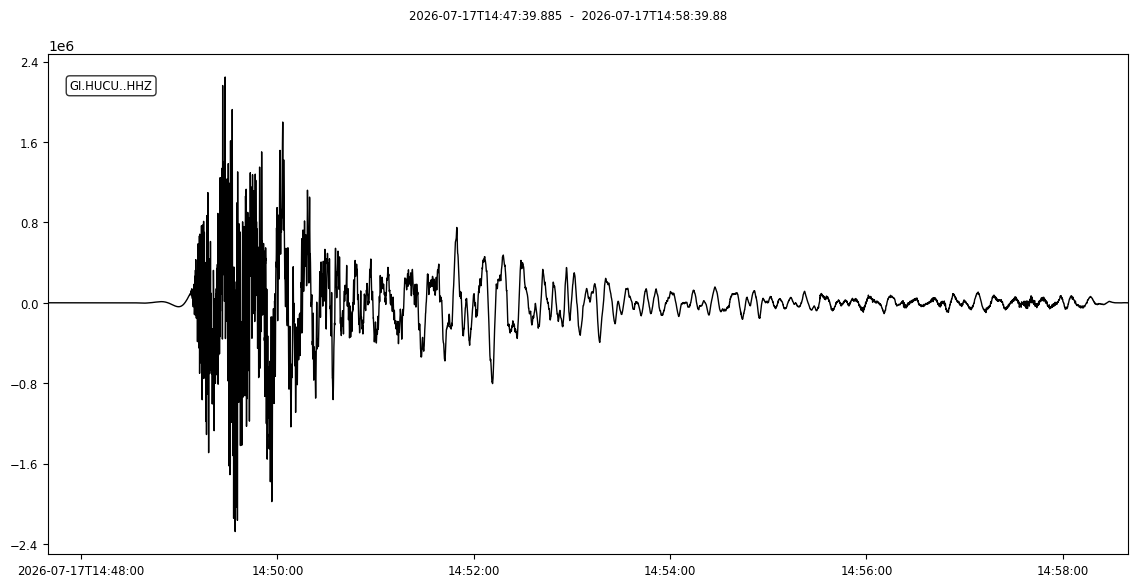

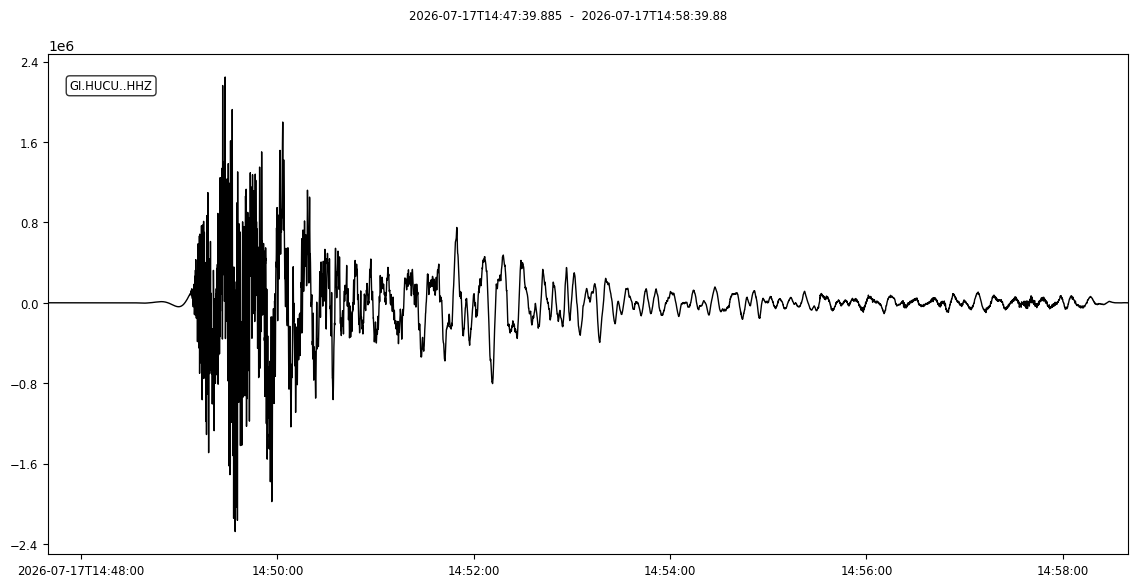

In [20]:
st_filtered.plot(
    size=(1200, 600),
    equal_scale=False
)

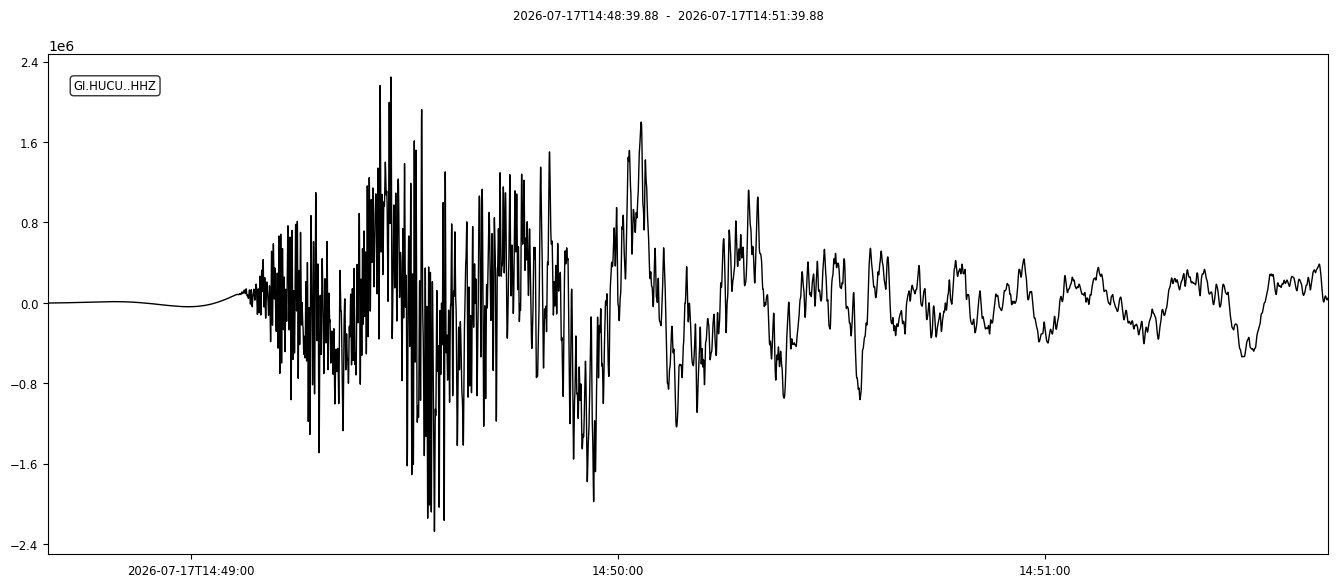

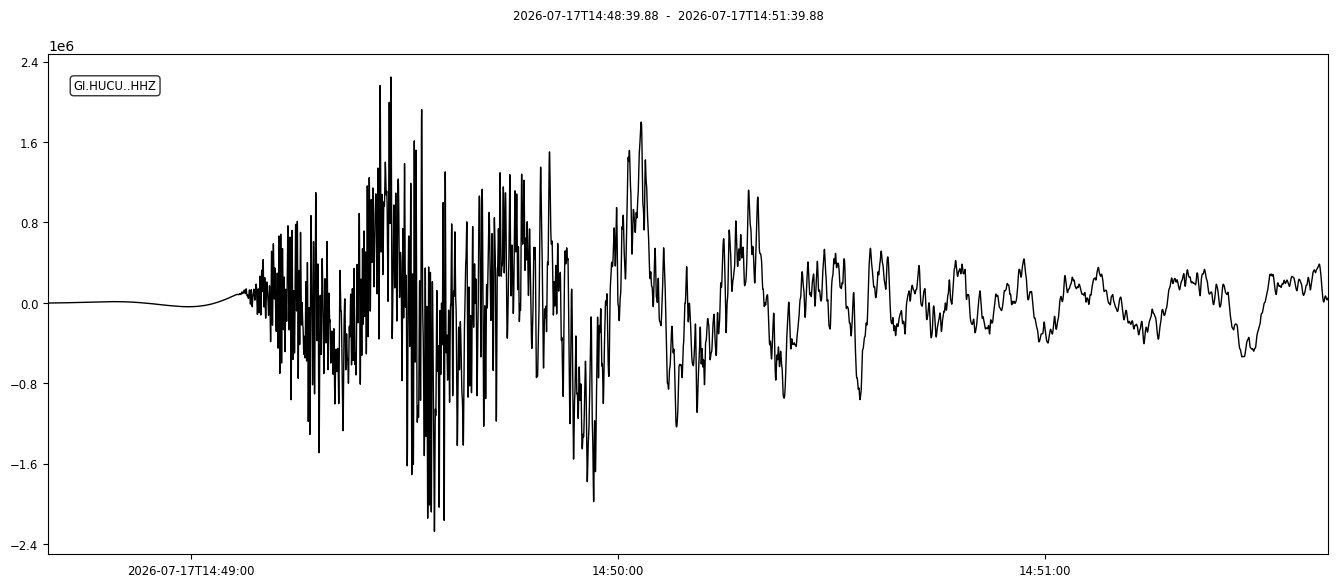

In [21]:
t1 = event_time
t2 = event_time + 180

st_zoom = st_filtered.copy()
st_zoom.trim(t1, t2)

st_zoom.plot(
    size=(1400, 600),
    equal_scale=False
)

In [22]:
from obspy.signal.trigger import classic_sta_lta

tr = st_filtered[0]

df = tr.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr.data,
    sta_samples,
    lta_samples
)

print("Sampling rate:", df)
print("STA window:", sta_seconds, "seconds")
print("LTA window:", lta_seconds, "seconds")

Sampling rate: 200.0
STA window: 3 seconds
LTA window: 20 seconds


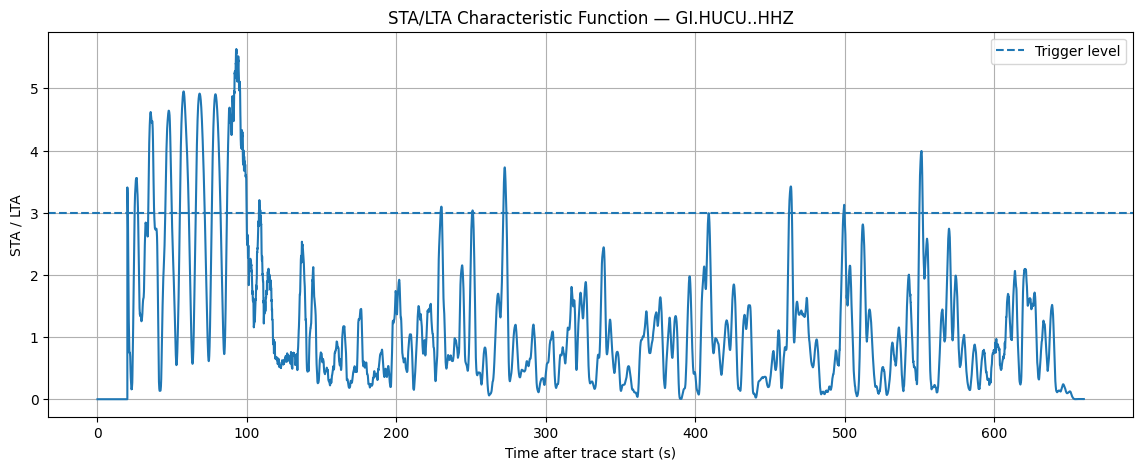

In [23]:

time = np.arange(len(cft)) / df

plt.figure(figsize=(14, 5))
plt.plot(time, cft)

plt.axhline(3, linestyle="--", label="Trigger level")
plt.xlabel("Time after trace start (s)")
plt.ylabel("STA / LTA")
plt.title("STA/LTA Characteristic Function — GI.HUCU..HHZ")
plt.legend()
plt.grid()

plt.show()

In [24]:
tr_pick = st_processed[0].copy()

# Keeping 30 s before origin to 180 s after origin
tr_pick.trim(
    starttime=event_time - 30,
    endtime=event_time + 180
)

print(tr_pick)

GI.HUCU..HHZ | 2026-07-17T14:48:09.880000Z - 2026-07-17T14:51:39.880000Z | 200.0 Hz, 42001 samples


In [25]:
from obspy.signal.trigger import classic_sta_lta

df = tr_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr_pick.data,
    sta_samples,
    lta_samples
)

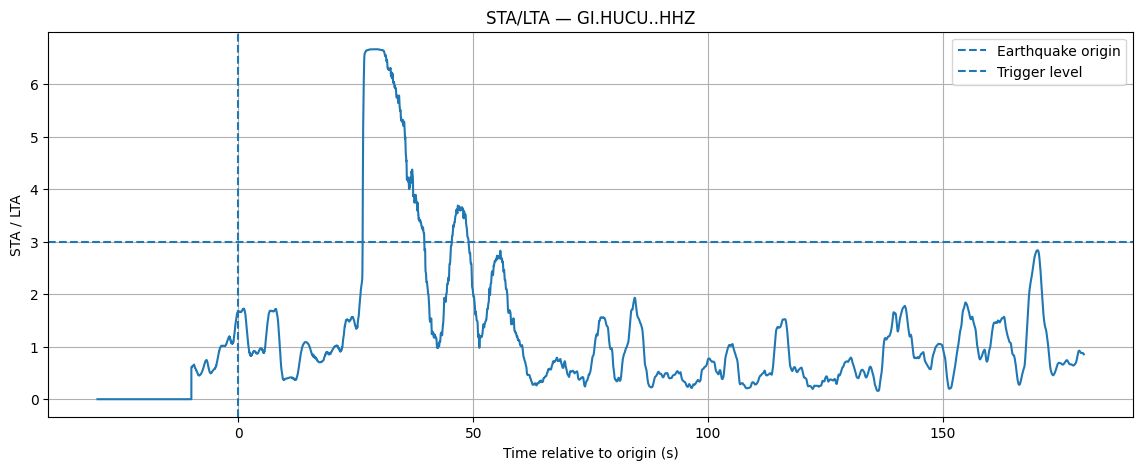

In [26]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(len(cft)) / df - 30

plt.figure(figsize=(14, 5))
plt.plot(time, cft)

plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.axhline(3, linestyle="--", label="Trigger level")

plt.xlabel("Time relative to origin (s)")
plt.ylabel("STA / LTA")
plt.title("STA/LTA — GI.HUCU..HHZ")
plt.legend()
plt.grid()
plt.show()

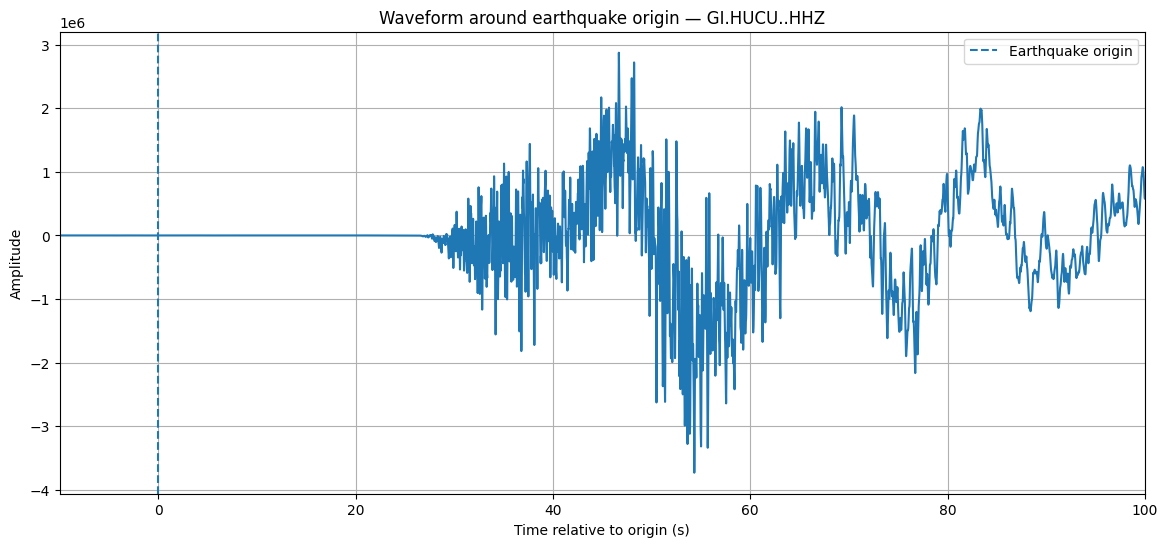

In [27]:
tr_plot = tr_pick.copy()

time = tr_plot.times(reftime=event_time)

plt.figure(figsize=(14, 6))

plt.plot(time, tr_plot.data)

plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.xlim(-10, 100)

plt.xlabel("Time relative to origin (s)")
plt.ylabel("Amplitude")
plt.title("Waveform around earthquake origin — GI.HUCU..HHZ")
plt.legend()
plt.grid()

plt.show()

In [28]:
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

# Earthquake coordinates
event_lat = 14.57
event_lon = -92.96
event_depth_km = 22.0

# HUCU station coordinates
station_lat = 15.407847
station_lon = -91.947188

# Epicentral angular distance
distance_deg = locations2degrees(
    event_lat,
    event_lon,
    station_lat,
    station_lon
)

print("Epicentral distance:", distance_deg, "degrees")

Epicentral distance: 1.2880751896687836 degrees


In [29]:
model = TauPyModel(model="iasp91")

arrivals = model.get_travel_times(
    source_depth_in_km=event_depth_km,
    distance_in_degree=distance_deg,
    phase_list=["P", "S"]
)

for arrival in arrivals:
    print(
        arrival.name,
        "travel time =",
        round(arrival.time, 2),
        "seconds"
    )

P travel time = 22.66 seconds
P travel time = 24.07 seconds
S travel time = 39.89 seconds
S travel time = 41.67 seconds


In [30]:
for arrival in arrivals:
    print(
        f"{arrival.name:5s}  "
        f"time = {arrival.time:7.2f} s  "
        f"ray parameter = {arrival.ray_param_sec_degree:.3f}"
    )

P      time =   22.66 s  ray parameter = 13.753
P      time =   24.07 s  ray parameter = 16.494
S      time =   39.89 s  ray parameter = 24.737
S      time =   41.67 s  ray parameter = 28.580


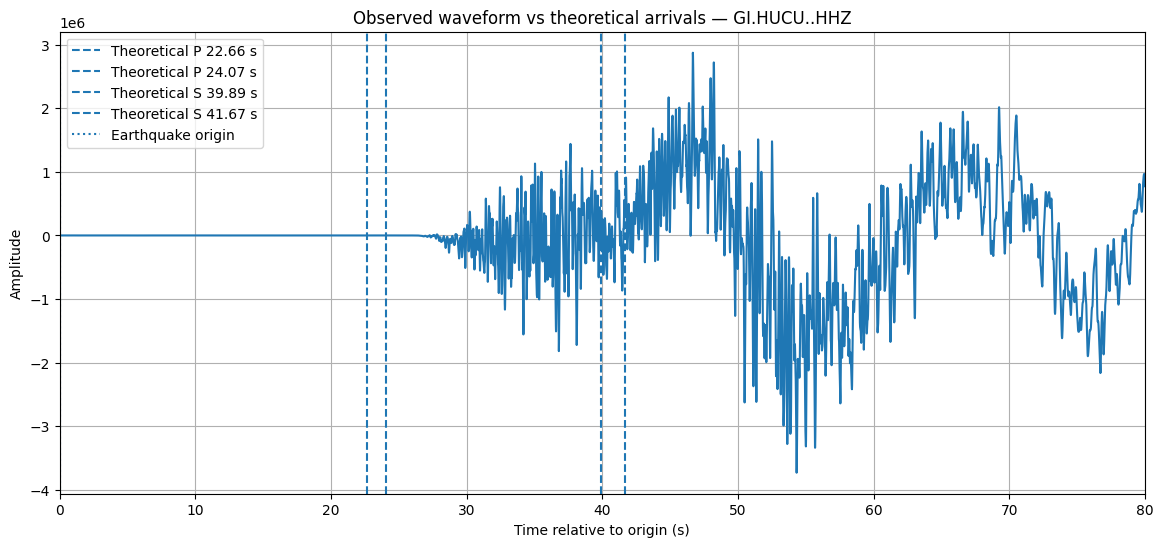

In [31]:
plt.figure(figsize=(14, 6))

time = tr_plot.times(reftime=event_time)

plt.plot(time, tr_plot.data)

# Theoretical arrivals
plt.axvline(22.66, linestyle="--", label="Theoretical P 22.66 s")
plt.axvline(24.07, linestyle="--", label="Theoretical P 24.07 s")

plt.axvline(39.89, linestyle="--", label="Theoretical S 39.89 s")
plt.axvline(41.67, linestyle="--", label="Theoretical S 41.67 s")

plt.axvline(0, linestyle=":", label="Earthquake origin")

plt.xlim(0, 80)

plt.xlabel("Time relative to origin (s)")
plt.ylabel("Amplitude")
plt.title("Observed waveform vs theoretical arrivals — GI.HUCU..HHZ")
plt.legend()
plt.grid()

plt.show()

In [32]:
# Looking for the maximum STA/LTA value between 20 and 35 seconds

mask = (time >= 20) & (time <= 35)

peak_index = np.argmax(cft[mask])

candidate_times = time[mask]

p_candidate = candidate_times[peak_index]

print("Candidate P-related time:", p_candidate, "seconds")
print("STA/LTA value:", cft[mask][peak_index])

Candidate P-related time: 29.453999999999997 seconds
STA/LTA value: 6.666455508306895


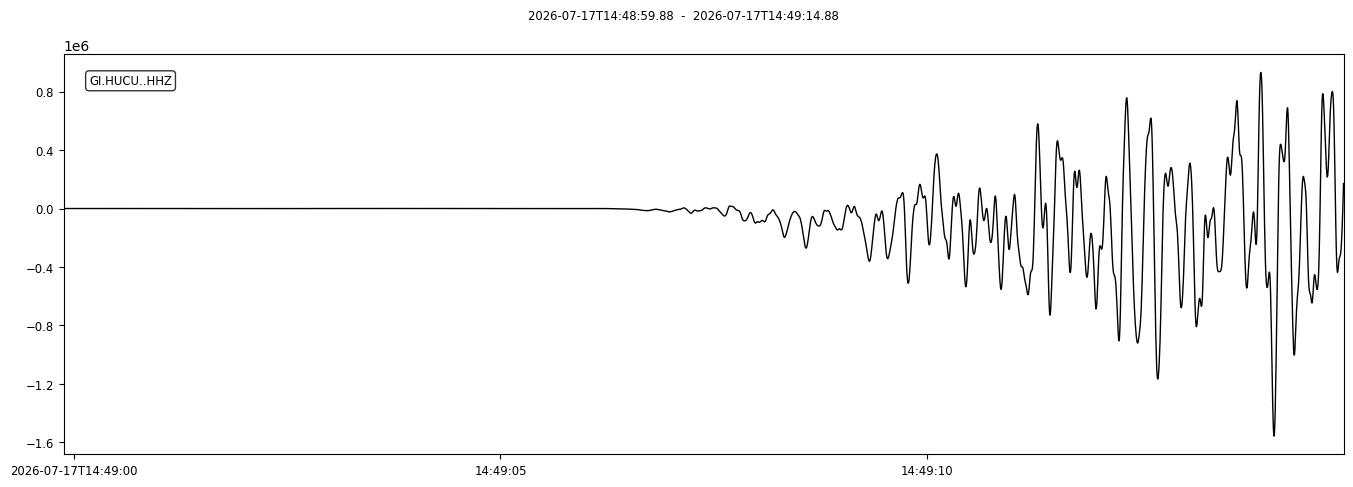

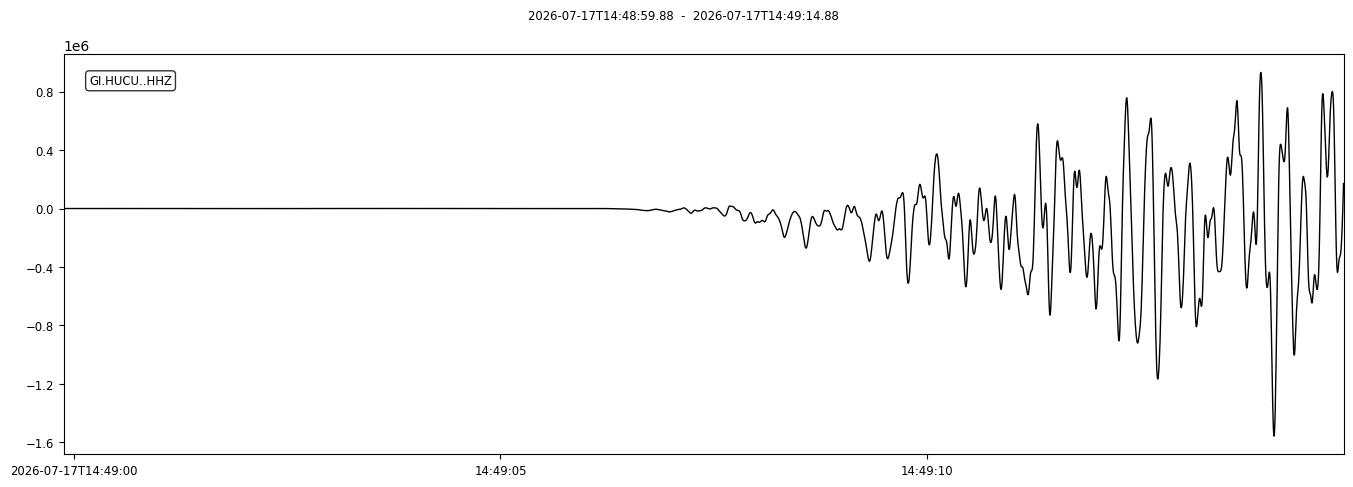

In [33]:
tr_p = tr_pick.copy()

tr_p.trim(
    starttime=event_time + 20,
    endtime=event_time + 35
)

tr_p.plot(
    size=(1400, 500),
    equal_scale=False
)

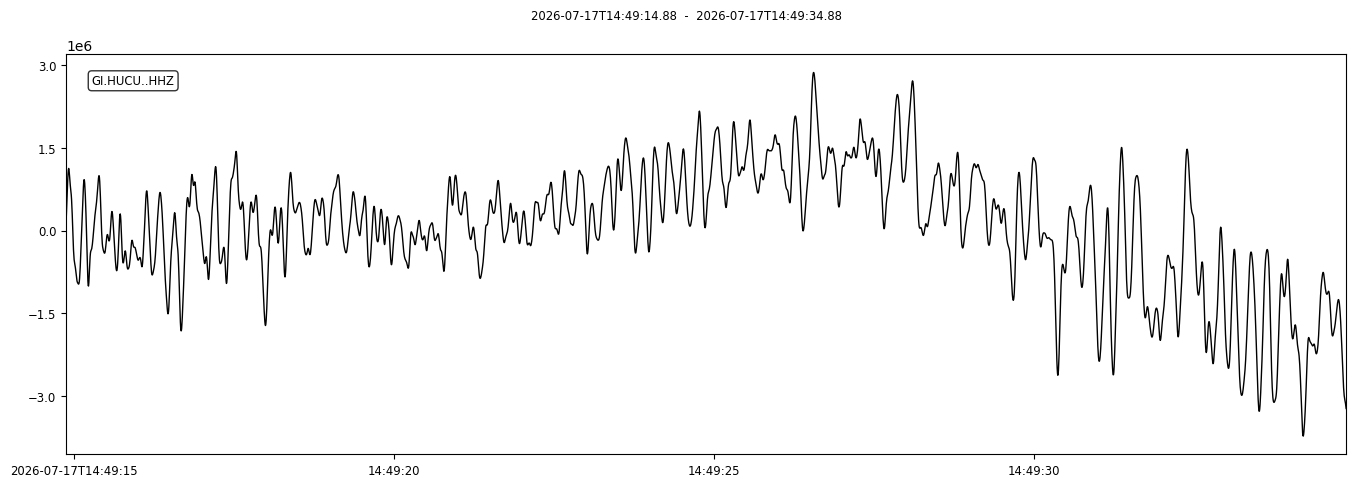

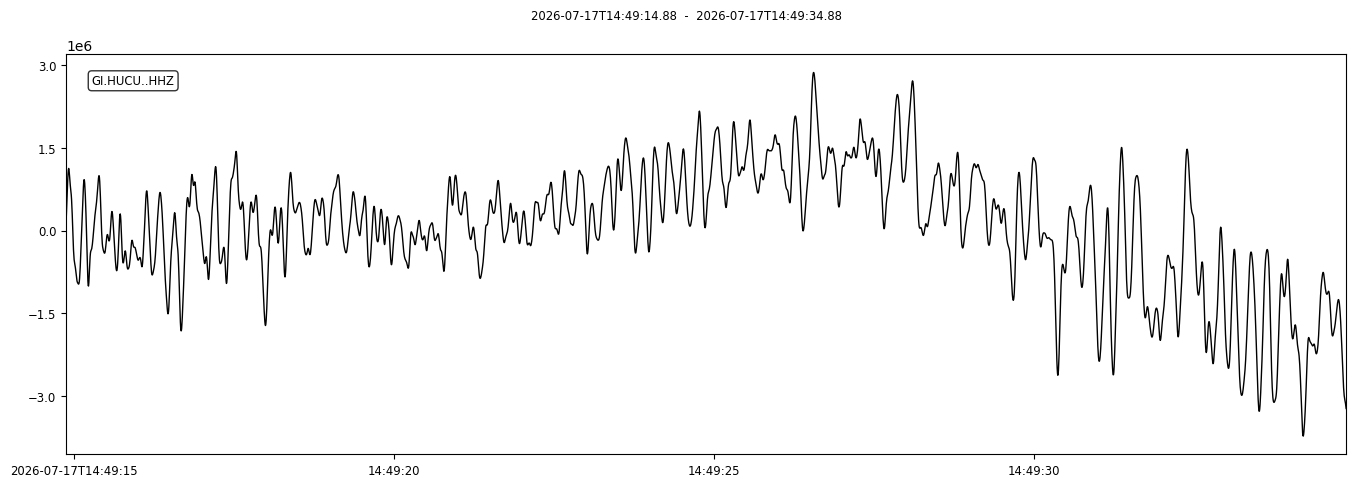

In [34]:
tr_s = tr_pick.copy()

tr_s.trim(
    starttime=event_time + 35,
    endtime=event_time + 55
)

tr_s.plot(
    size=(1400, 500),
    equal_scale=False
)

In [35]:
p_theory = 22.66
s_theory = 39.89

p_obs = 24.5
s_obs = 41.0

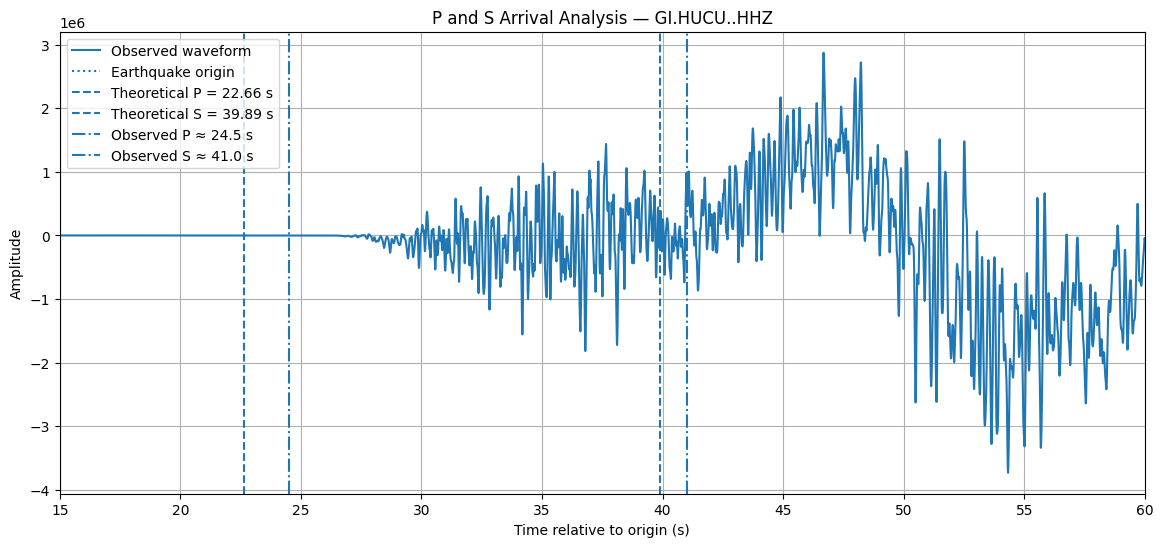

In [36]:
plt.figure(figsize=(14, 6))

time = tr_plot.times(reftime=event_time)

plt.plot(time, tr_plot.data, label="Observed waveform")

plt.axvline(0, linestyle=":", label="Earthquake origin")

plt.axvline(p_theory, linestyle="--", label="Theoretical P = 22.66 s")
plt.axvline(s_theory, linestyle="--", label="Theoretical S = 39.89 s")

plt.axvline(p_obs, linestyle="-.", label="Observed P ≈ 24.5 s")
plt.axvline(s_obs, linestyle="-.", label="Observed S ≈ 41.0 s")

plt.xlim(15, 60)

plt.xlabel("Time relative to origin (s)")
plt.ylabel("Amplitude")
plt.title("P and S Arrival Analysis — GI.HUCU..HHZ")
plt.legend()
plt.grid()

plt.show()

In [37]:
sp_time = s_obs - p_obs

print("Observed P:", p_obs, "s")
print("Observed S:", s_obs, "s")
print("Observed S-P:", sp_time, "s")

Observed P: 24.5 s
Observed S: 41.0 s
Observed S-P: 16.5 s


In [38]:
from obspy.taup import TauPyModel
import numpy as np

model = TauPyModel(model="iasp91")

source_depth = 22.0
observed_sp = 16.5

distances = np.linspace(0.1, 5.0, 490)

best_distance = None
best_difference = np.inf
best_p = None
best_s = None

for distance in distances:

    arrivals = model.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=["P", "S"]
    )

    p_arrivals = [a.time for a in arrivals if a.name == "P"]
    s_arrivals = [a.time for a in arrivals if a.name == "S"]

    if p_arrivals and s_arrivals:

        sp = s_arrivals[0] - p_arrivals[0]

        difference = abs(sp - observed_sp)

        if difference < best_difference:
            best_difference = difference
            best_distance = distance
            best_p = p_arrivals[0]
            best_s = s_arrivals[0]

print("Estimated angular distance:", best_distance, "degrees")
print("Theoretical P time at this distance:", best_p, "s")
print("Theoretical S time at this distance:", best_s, "s")
print("Theoretical S-P:", best_s - best_p, "s")
print("Difference from observed S-P:", best_difference, "s")

Estimated angular distance: 1.2222903885480574 degrees
Theoretical P time at this distance: 21.750568338685042 s
Theoretical S time at this distance: 38.258427439045754 s
Theoretical S-P: 16.50785910036071 s
Difference from observed S-P: 0.00785910036071158 s


In [39]:
from obspy.geodetics import locations2degrees

event_lat = 14.57
event_lon = -92.96

station_lat = 15.407847
station_lon = -91.947188

actual_distance_deg = locations2degrees(
    event_lat,
    event_lon,
    station_lat,
    station_lon
)

actual_distance_km = actual_distance_deg * 111.195

print("Actual angular distance:", actual_distance_deg, "degrees")
print("Approximate distance:", actual_distance_km, "km")

Actual angular distance: 1.2880751896687836 degrees
Approximate distance: 143.22752071522038 km


In [40]:
successful_stations = [
    ("GI", "HUCU"),
    ("GI", "SUCU"),
    ("GI", "GUVC"),
    ("GI", "QCIX"),
    ("GI", "GUSP"),
    ("GI", "SROR"),
    ("GI", "AVCS"),
    ("SV", "NUBE"),
    ("SV", "RBDL")
]

print("Number of successful stations:", len(successful_stations))

Number of successful stations: 9


In [41]:
all_waveforms = {}

for network, station in successful_stations:

    try:
        st = earthscope.get_waveforms(
            network=network,
            station=station,
            location="--",
            channel="HHZ",
            starttime=event_time - 60,
            endtime=event_time + 600
        )

        all_waveforms[f"{network}.{station}"] = st

        print(
            f"Downloaded: {network}.{station} | "
            f"{len(st)} trace(s)"
        )

    except Exception as e:
        print(
            f"Failed: {network}.{station} | {type(e).__name__}"
        )

print("\nTotal successful stations:", len(all_waveforms))

Downloaded: GI.HUCU | 1 trace(s)
Downloaded: GI.SUCU | 1 trace(s)
Downloaded: GI.GUVC | 1 trace(s)
Downloaded: GI.QCIX | 1 trace(s)
Downloaded: GI.GUSP | 1 trace(s)
Downloaded: GI.SROR | 1 trace(s)
Downloaded: GI.AVCS | 1 trace(s)
Downloaded: SV.NUBE | 1 trace(s)
Downloaded: SV.RBDL | 1 trace(s)

Total successful stations: 9


In [43]:
processed_waveforms = {}

for station_name, st in all_waveforms.items():

    st_proc = st.copy()

    # Remove linear trend
    st_proc.detrend("linear")

    # Taper 5% at both ends
    st_proc.taper(max_percentage=0.05)

    # Band-pass filter
    st_proc.filter(
        "bandpass",
        freqmin=0.05,
        freqmax=5.0,
        corners=4,
        zerophase=True
    )

    processed_waveforms[station_name] = st_proc

    print(f"Processed: {station_name}")


Processed: GI.HUCU
Processed: GI.SUCU
Processed: GI.GUVC
Processed: GI.QCIX
Processed: GI.GUSP
Processed: GI.SROR
Processed: GI.AVCS
Processed: SV.NUBE
Processed: SV.RBDL


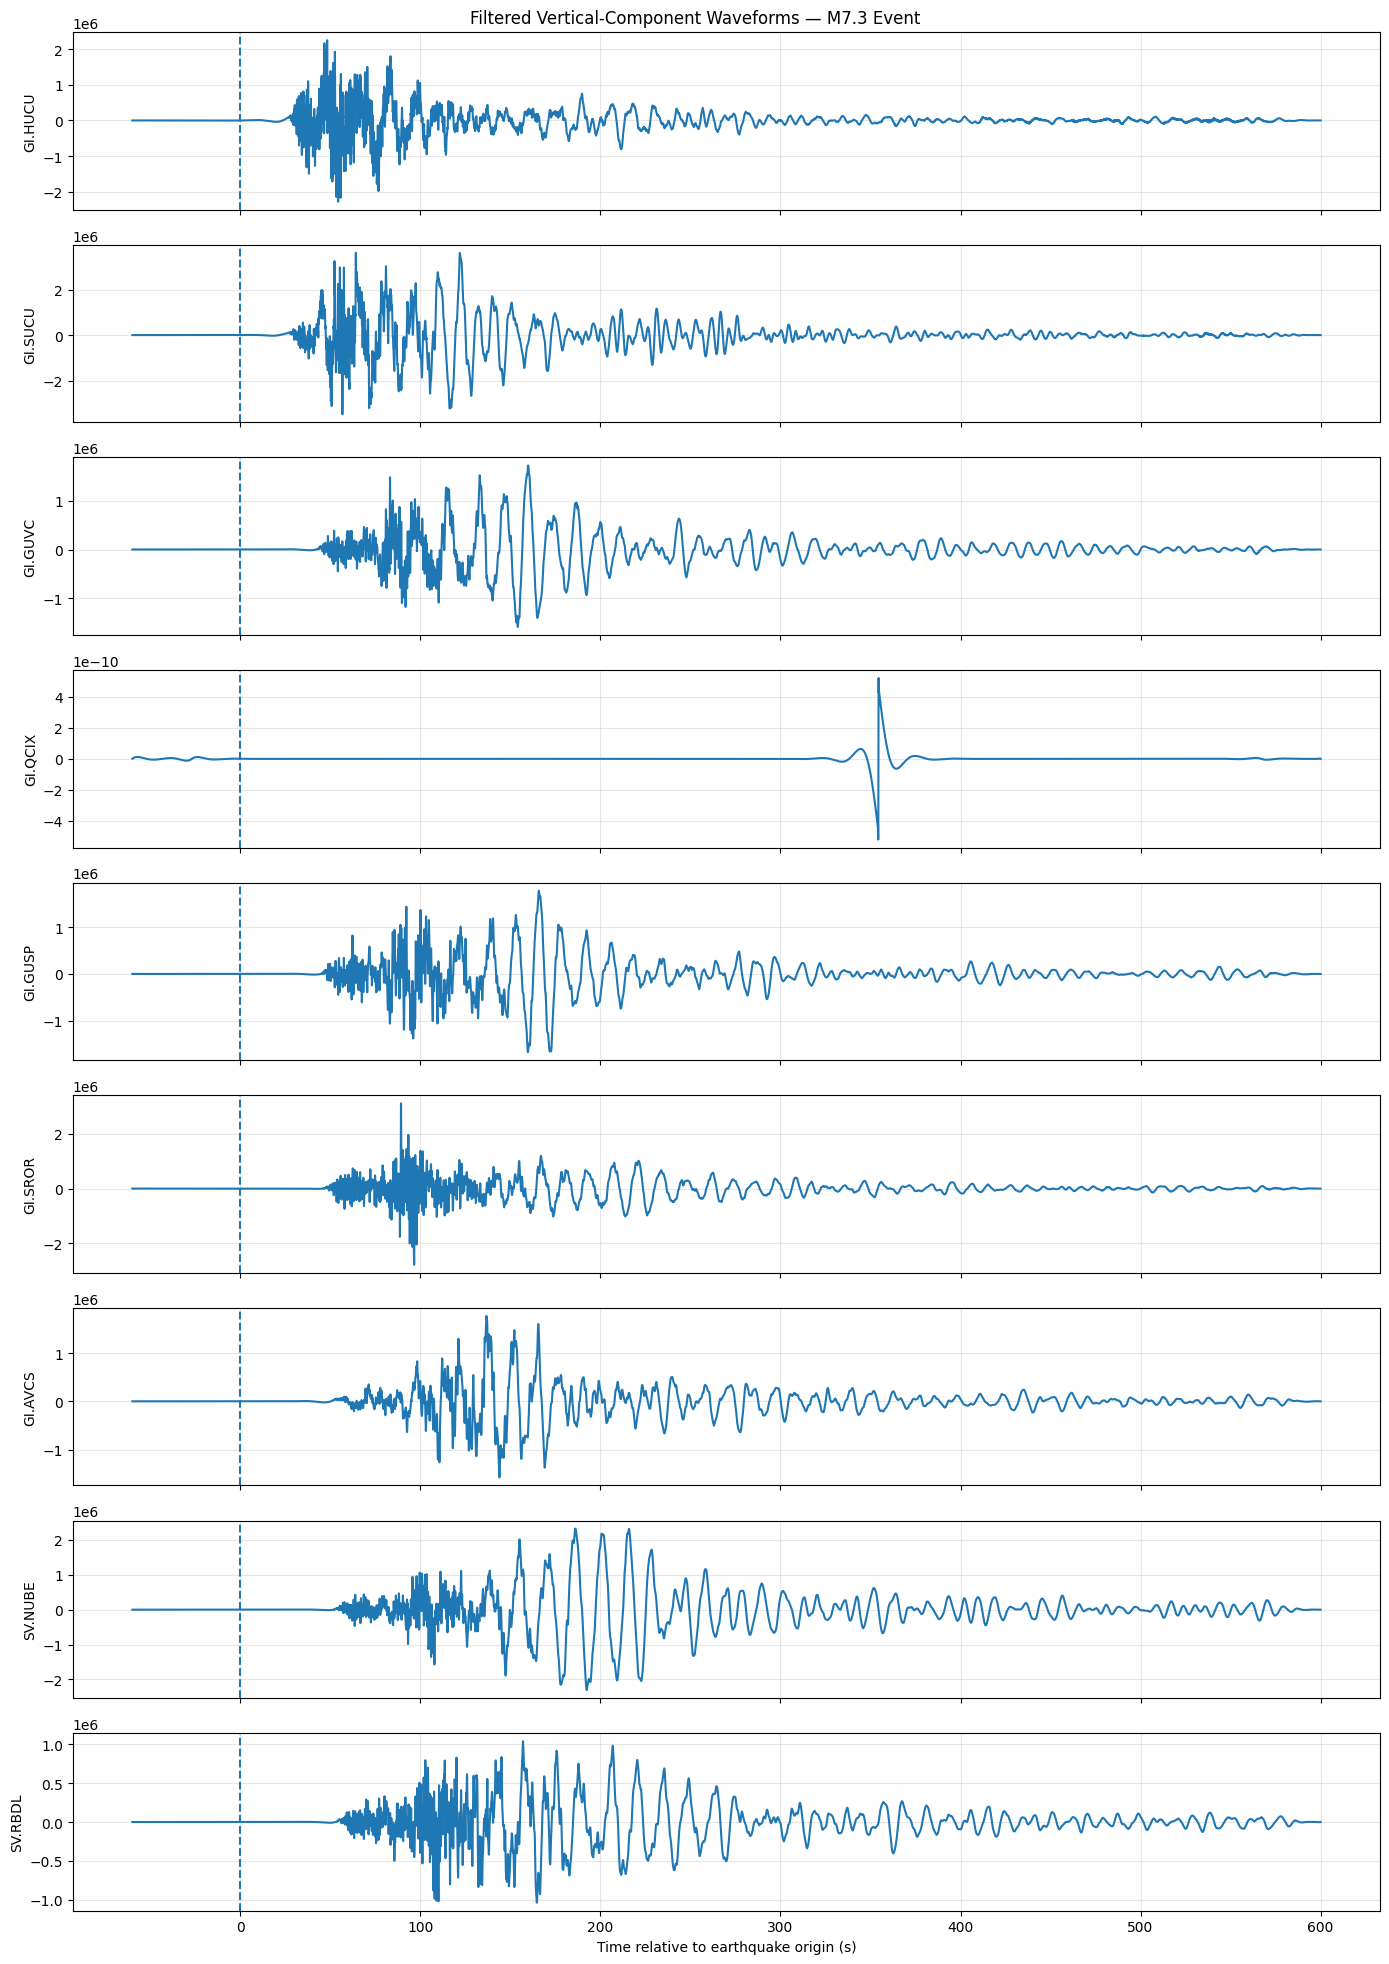

In [44]:
fig, axes = plt.subplots(9, 1, figsize=(14, 20), sharex=True)

for ax, (station_name, st) in zip(axes, processed_waveforms.items()):

    tr = st[0]

    time = tr.times(reftime=event_time)

    ax.plot(time, tr.data)
    ax.axvline(0, linestyle="--", label="Origin time")

    ax.set_ylabel(station_name)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time relative to earthquake origin (s)")

plt.suptitle("Filtered Vertical-Component Waveforms — M7.3 Event")
plt.tight_layout()
plt.show()

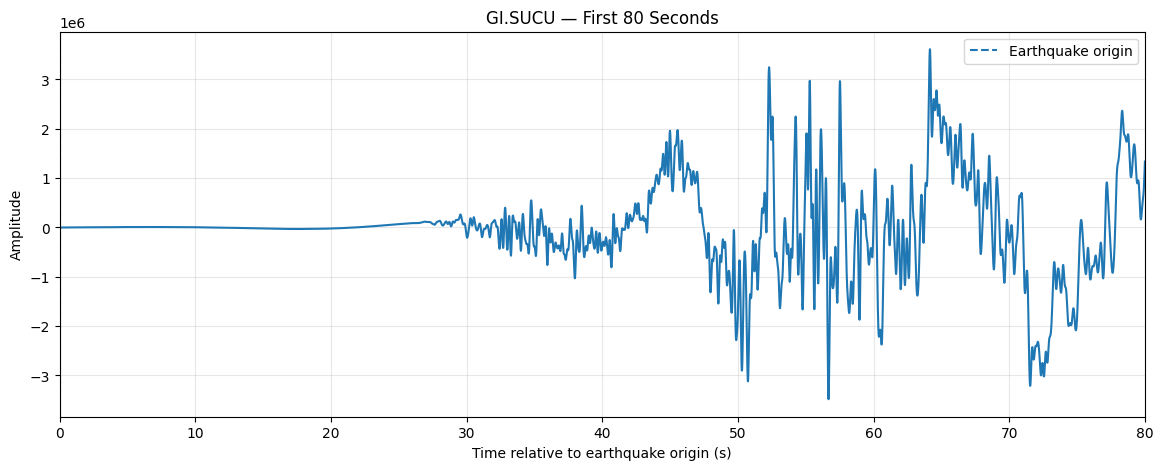

In [45]:
station_name = "GI.SUCU"

tr = processed_waveforms[station_name][0]

time = tr.times(reftime=event_time)

plt.figure(figsize=(14, 5))
plt.plot(time, tr.data)

plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.xlim(0, 80)
plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title(f"{station_name} — First 80 Seconds")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

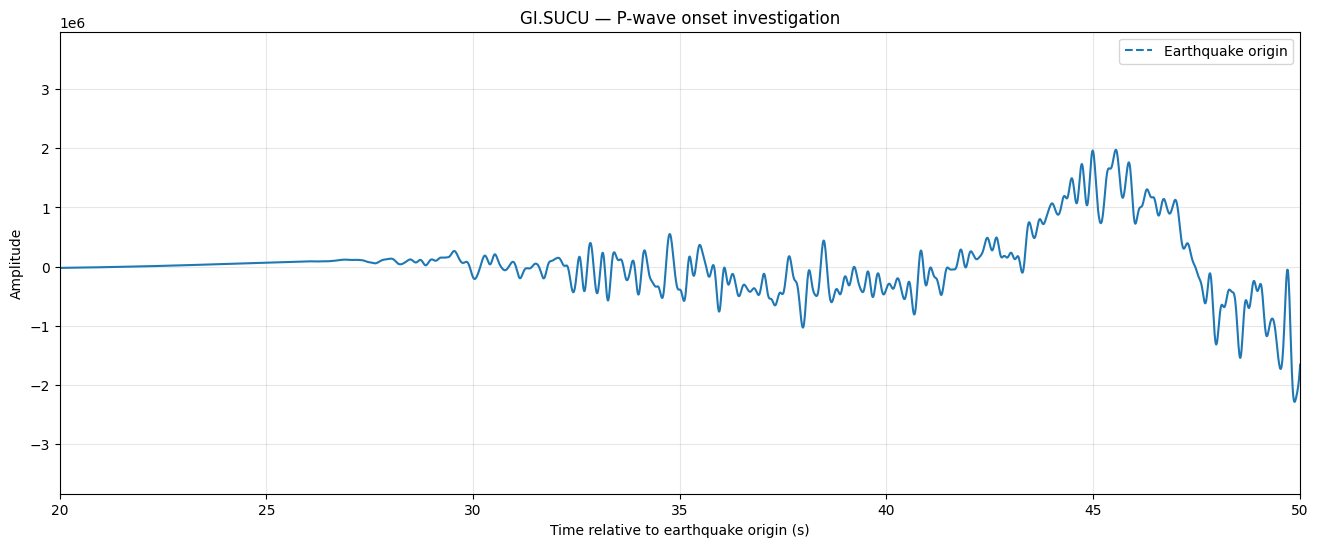

In [46]:
tr = processed_waveforms["GI.SUCU"][0]

time = tr.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time, tr.data)

plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.xlim(20, 50)
plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SUCU — P-wave onset investigation")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

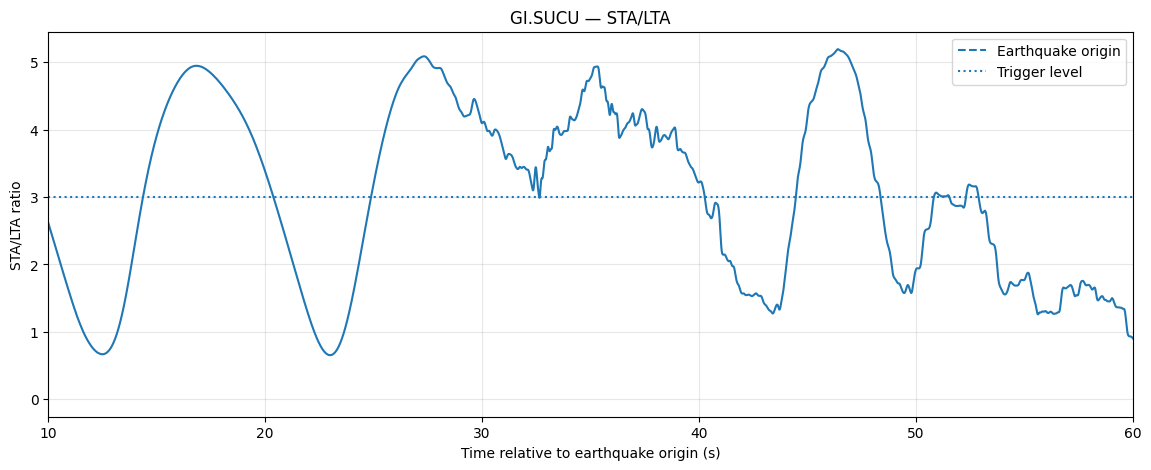

In [47]:
from obspy.signal.trigger import classic_sta_lta

tr_sucu = processed_waveforms["GI.SUCU"][0].copy()

# Focus on the useful time window
tr_sucu.trim(
    starttime=event_time - 10,
    endtime=event_time + 80
)

df = tr_sucu.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_sucu = classic_sta_lta(
    tr_sucu.data,
    sta_samples,
    lta_samples
)

time_sucu = np.arange(len(cft_sucu)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_sucu, cft_sucu)
plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.axhline(3, linestyle=":", label="Trigger level")

plt.xlim(10, 60)
plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.SUCU — STA/LTA")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [48]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

# SUCU coordinates
sucu_lat = 15.529
sucu_lon = -92.103

distance_sucu = locations2degrees(
    14.57, -92.96,
    sucu_lat, sucu_lon
)

model = TauPyModel(model="iasp91")

arrivals_sucu = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_sucu,
    phase_list=["P", "S"]
)

print("Distance:", distance_sucu, "degrees")

for arrival in arrivals_sucu:
    print(
        arrival.name,
        ":",
        round(arrival.time, 2),
        "s"
    )

Distance: 1.266725381653031 degrees
P : 22.36 s
P : 23.72 s
S : 39.36 s
S : 41.06 s


In [49]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

# SUCU coordinates
sucu_lat = 15.529
sucu_lon = -92.103

# Source-station angular distance
distance_sucu = locations2degrees(
    14.57, -92.96,
    sucu_lat, sucu_lon
)

# IASP91 Earth model
model = TauPyModel(model="iasp91")

arrivals_sucu = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_sucu,
    phase_list=["P", "S"]
)

print("Distance:", distance_sucu, "degrees")

for arrival in arrivals_sucu:
    print(arrival.name, ":", round(arrival.time, 2), "s")

Distance: 1.266725381653031 degrees
P : 22.36 s
P : 23.72 s
S : 39.36 s
S : 41.06 s


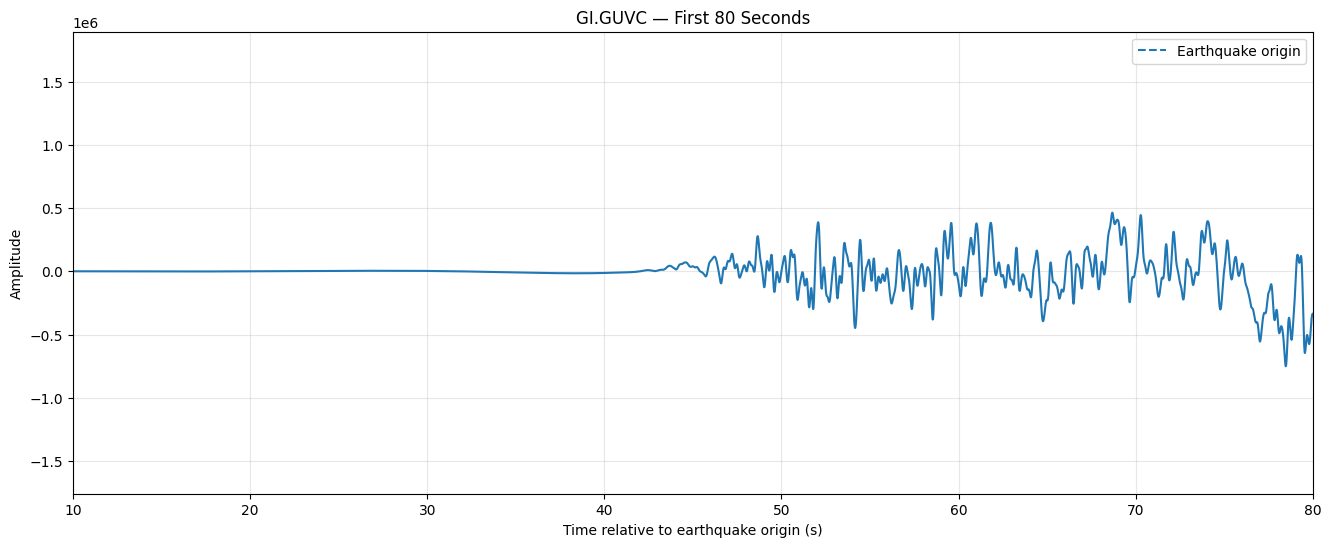

In [50]:
tr_guvc = processed_waveforms["GI.GUVC"][0]

time_guvc = tr_guvc.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_guvc, tr_guvc.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 80)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUVC — First 80 Seconds")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

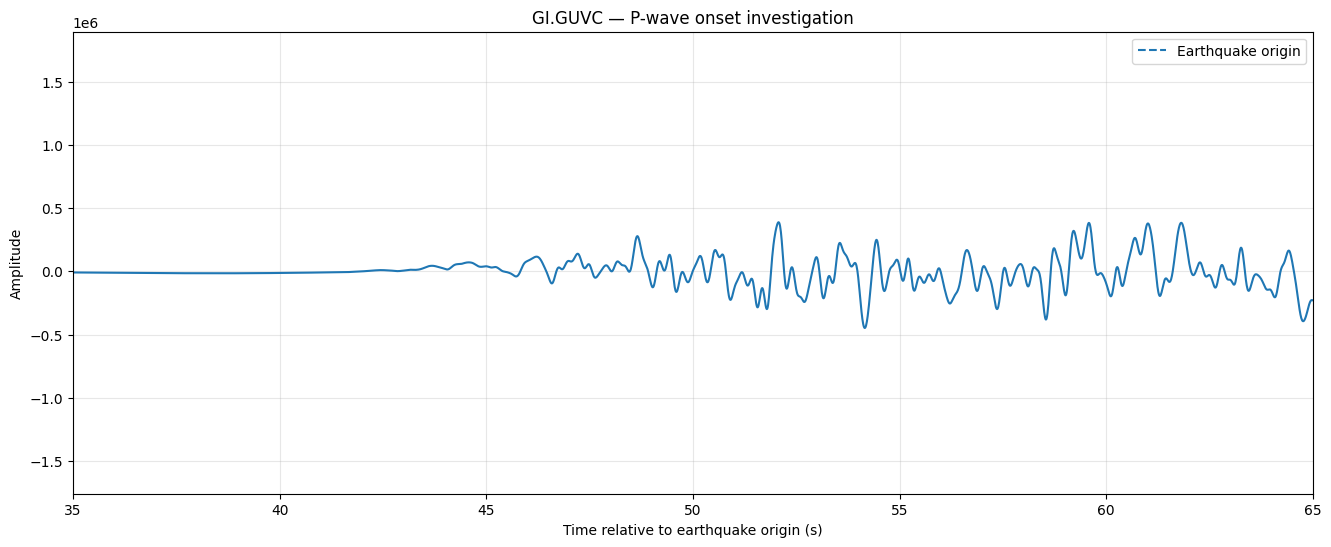

In [51]:
tr_guvc = processed_waveforms["GI.GUVC"][0]

time_guvc = tr_guvc.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_guvc, tr_guvc.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(35, 65)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUVC — P-wave onset investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

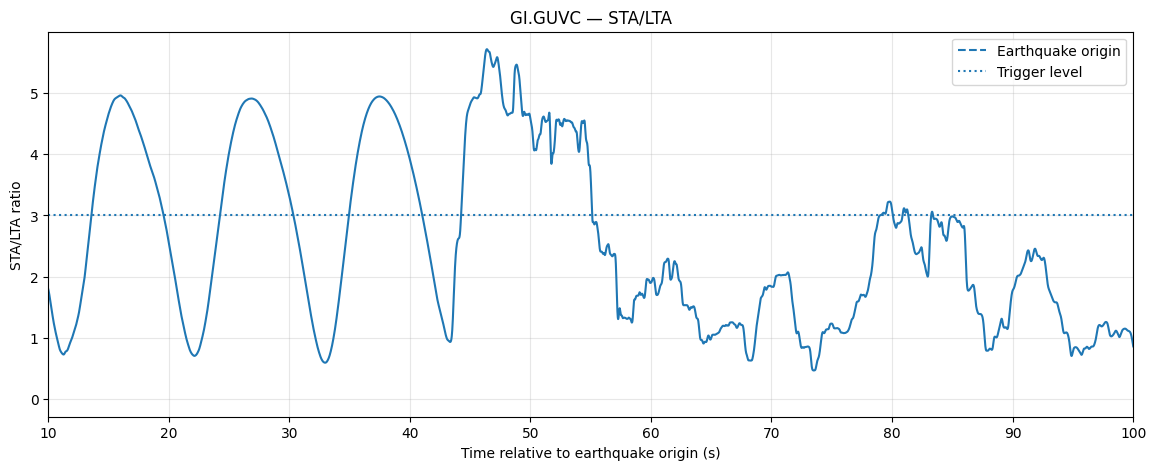

In [52]:
from obspy.signal.trigger import classic_sta_lta

tr_guvc_pick = processed_waveforms["GI.GUVC"][0].copy()

tr_guvc_pick.trim(
    starttime=event_time - 10,
    endtime=event_time + 120
)

df = tr_guvc_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_guvc = classic_sta_lta(
    tr_guvc_pick.data,
    sta_samples,
    lta_samples
)

time_guvc_sta = np.arange(len(cft_guvc)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_guvc_sta, cft_guvc)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

plt.xlim(10, 100)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.GUVC — STA/LTA")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [53]:
# Find GUVC coordinates from the station inventory

for network in stations:
    for station in network:
        if network.code == "GI" and station.code == "GUVC":
            print("Network :", network.code)
            print("Station :", station.code)
            print("Latitude:", station.latitude)
            print("Longitude:", station.longitude)
            print("Elevation:", station.elevation)

Network : GI
Station : GUVC
Latitude: 14.532
Longitude: -90.498
Elevation: 1800.0


In [54]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

guvc_lat = 14.532
guvc_lon = -90.498

distance_guvc = locations2degrees(
    14.57, -92.96,
    guvc_lat, guvc_lon
)

model = TauPyModel(model="iasp91")

arrivals_guvc = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_guvc,
    phase_list=["P", "S"]
)

print("Distance:", distance_guvc, "degrees")

for arrival in arrivals_guvc:
    print(
        arrival.name,
        ":",
        round(arrival.time, 2),
        "s"
    )

Distance: 2.3833211768029425 degrees
P : 37.72 s
P : 42.2 s
P : 42.43 s
S : 66.98 s
S : 73.1 s
S : 73.5 s


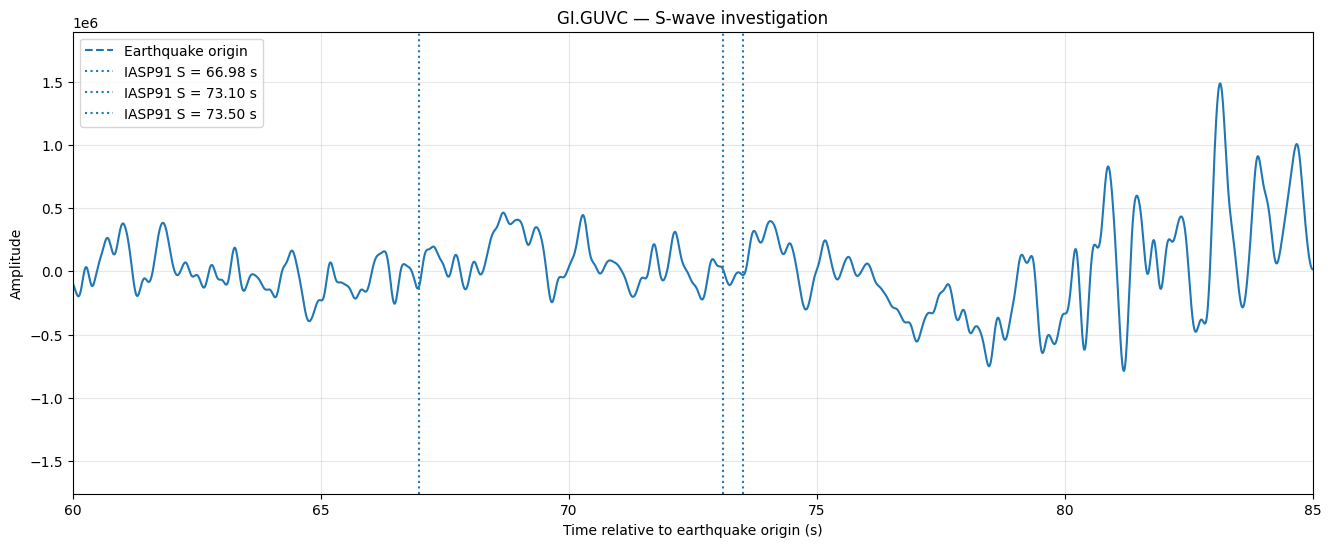

In [55]:
tr_guvc = processed_waveforms["GI.GUVC"][0]

time_guvc = tr_guvc.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_guvc, tr_guvc.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

# Theoretical S arrivals
plt.axvline(
    66.98,
    linestyle=":",
    label="IASP91 S = 66.98 s"
)

plt.axvline(
    73.1,
    linestyle=":",
    label="IASP91 S = 73.10 s"
)

plt.axvline(
    73.5,
    linestyle=":",
    label="IASP91 S = 73.50 s"
)

plt.xlim(60, 85)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUVC — S-wave investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [56]:
tr_qcix = processed_waveforms["GI.QCIX"][0]

print(tr_qcix)
print("Sampling rate:", tr_qcix.stats.sampling_rate)
print("Number of samples:", tr_qcix.stats.npts)
print("Min amplitude:", tr_qcix.data.min())
print("Max amplitude:", tr_qcix.data.max())

GI.QCIX..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
Sampling rate: 100.0
Number of samples: 66000
Min amplitude: -5.209658810937244e-10
Max amplitude: 5.209658810944075e-10


In [57]:
tr_qcix_raw = all_waveforms["GI.QCIX"][0]

print(tr_qcix_raw)
print("Raw min:", tr_qcix_raw.data.min())
print("Raw max:", tr_qcix_raw.data.max())
print("Raw mean:", tr_qcix_raw.data.mean())

GI.QCIX..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples
Raw min: 8388607
Raw max: 8388607
Raw mean: 8388607.0


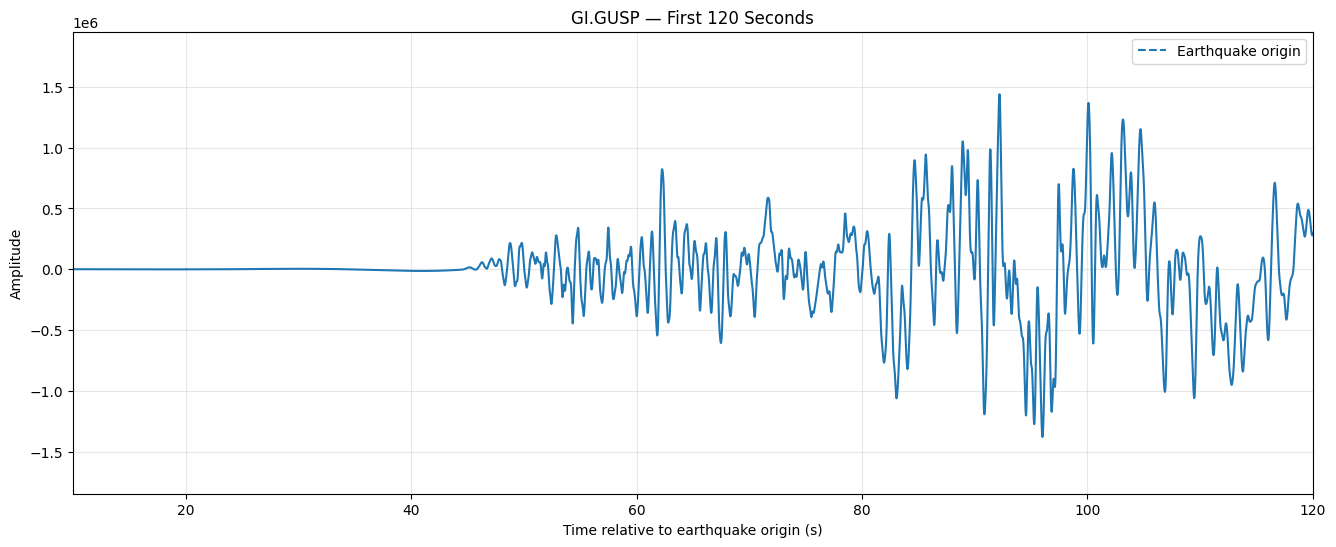

In [58]:
tr_gusp = processed_waveforms["GI.GUSP"][0]

time_gusp = tr_gusp.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_gusp, tr_gusp.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUSP — First 120 Seconds")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

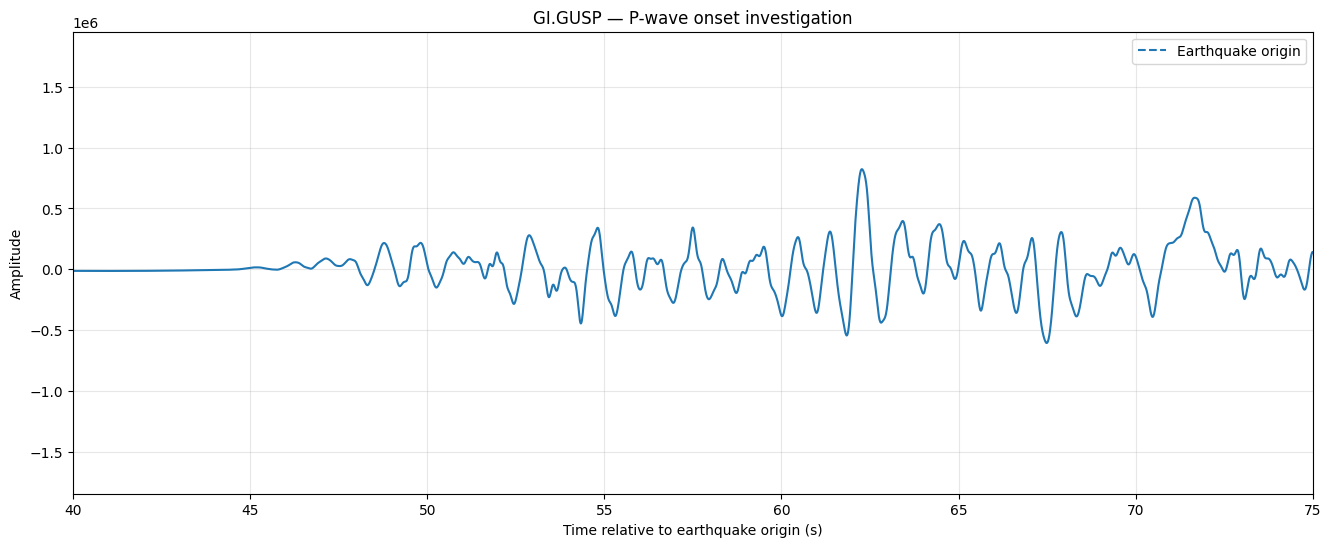

In [59]:
tr_gusp = processed_waveforms["GI.GUSP"][0]

time_gusp = tr_gusp.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_gusp, tr_gusp.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(40, 75)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUSP — P-wave onset investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

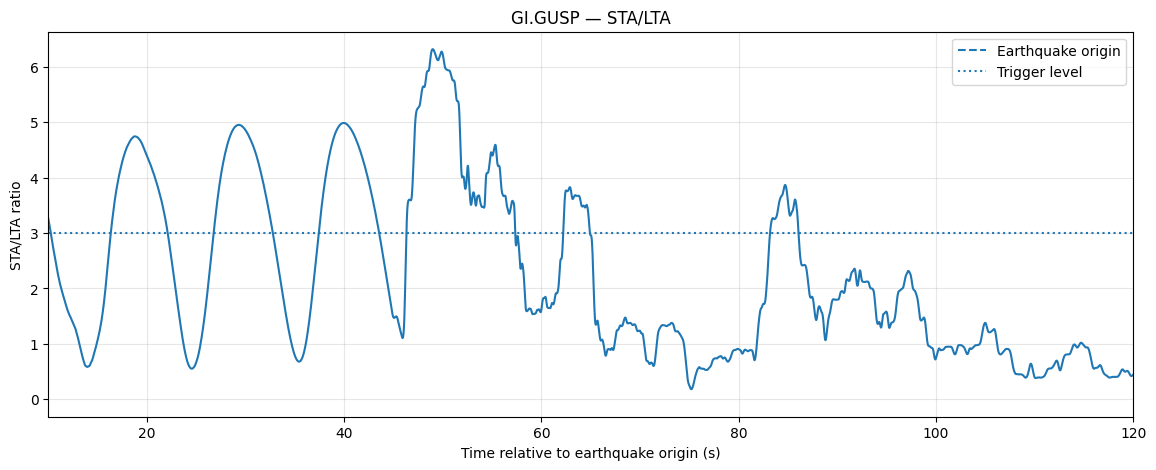

In [60]:
from obspy.signal.trigger import classic_sta_lta

tr_gusp_pick = processed_waveforms["GI.GUSP"][0].copy()

tr_gusp_pick.trim(
    starttime=event_time - 10,
    endtime=event_time + 150
)

df = tr_gusp_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_gusp = classic_sta_lta(
    tr_gusp_pick.data,
    sta_samples,
    lta_samples
)

time_gusp_sta = np.arange(len(cft_gusp)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_gusp_sta, cft_gusp)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.GUSP — STA/LTA")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [61]:
# Find GUSP coordinates from the station inventory

for network in stations:
    for station in network:
        if network.code == "GI" and station.code == "GUSP":
            print("Network :", network.code)
            print("Station :", station.code)
            print("Latitude:", station.latitude)
            print("Longitude:", station.longitude)
            print("Elevation:", station.elevation)

Network : GI
Station : GUSP
Latitude: 14.552
Longitude: -90.3168
Elevation: 2450.0


In [62]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

gusp_lat = 14.552
gusp_lon = -90.3168

# Source-station angular distance
distance_gusp = locations2degrees(
    14.57, -92.96,
    gusp_lat, gusp_lon
)

# IASP91 Earth model
model = TauPyModel(model="iasp91")

arrivals_gusp = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_gusp,
    phase_list=["P", "S"]
)

print("Distance:", distance_gusp, "degrees")

for arrival in arrivals_gusp:
    print(
        arrival.name,
        ":",
        round(arrival.time, 2),
        "s"
    )

Distance: 2.558350770467267 degrees
P : 40.13 s
P : 45.19 s
P : 45.39 s
S : 71.31 s
S : 78.27 s
S : 78.63 s


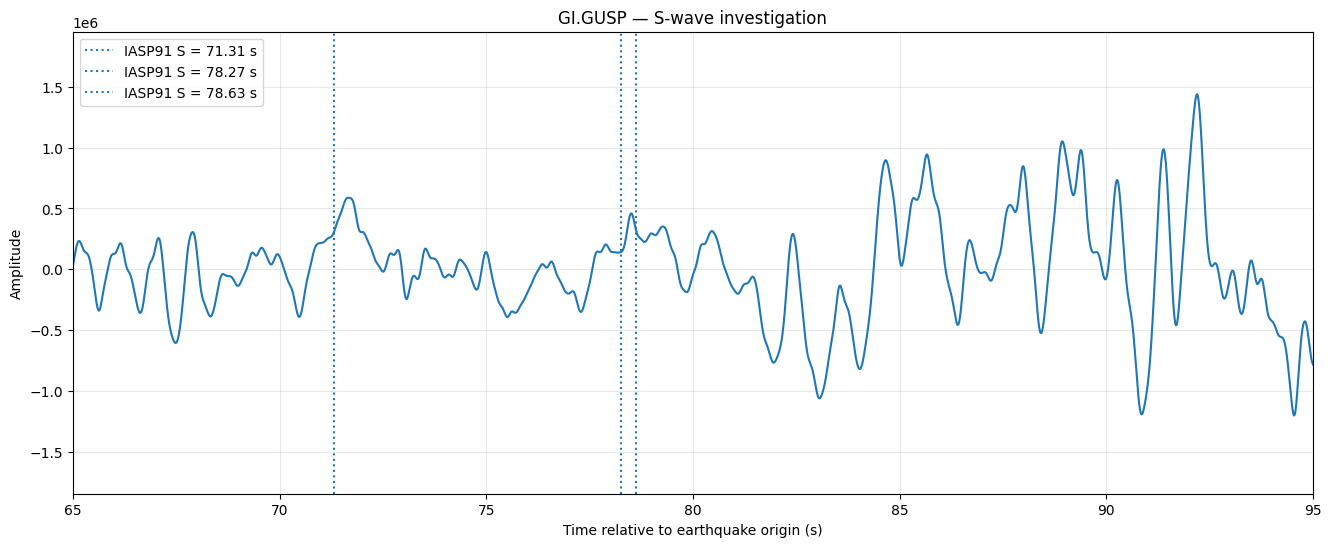

In [63]:
tr_gusp = processed_waveforms["GI.GUSP"][0]

time_gusp = tr_gusp.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_gusp, tr_gusp.data)

plt.axvline(
    71.31,
    linestyle=":",
    label="IASP91 S = 71.31 s"
)

plt.axvline(
    78.27,
    linestyle=":",
    label="IASP91 S = 78.27 s"
)

plt.axvline(
    78.63,
    linestyle=":",
    label="IASP91 S = 78.63 s"
)

plt.xlim(65, 95)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUSP — S-wave investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

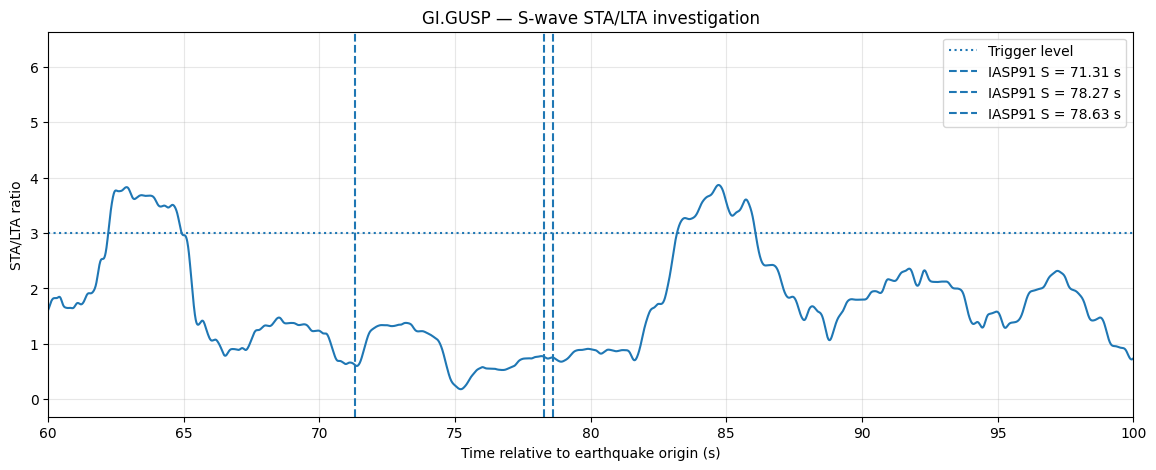

In [64]:
tr_gusp_s = processed_waveforms["GI.GUSP"][0].copy()

tr_gusp_s.trim(
    starttime=event_time - 10,
    endtime=event_time + 120
)

df = tr_gusp_s.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_gusp_s = classic_sta_lta(
    tr_gusp_s.data,
    sta_samples,
    lta_samples
)

time_gusp_s = np.arange(len(cft_gusp_s)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_gusp_s, cft_gusp_s)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

plt.axvline(
    71.31,
    linestyle="--",
    label="IASP91 S = 71.31 s"
)

plt.axvline(
    78.27,
    linestyle="--",
    label="IASP91 S = 78.27 s"
)

plt.axvline(
    78.63,
    linestyle="--",
    label="IASP91 S = 78.63 s"
)

plt.xlim(60, 100)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.GUSP — S-wave STA/LTA investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

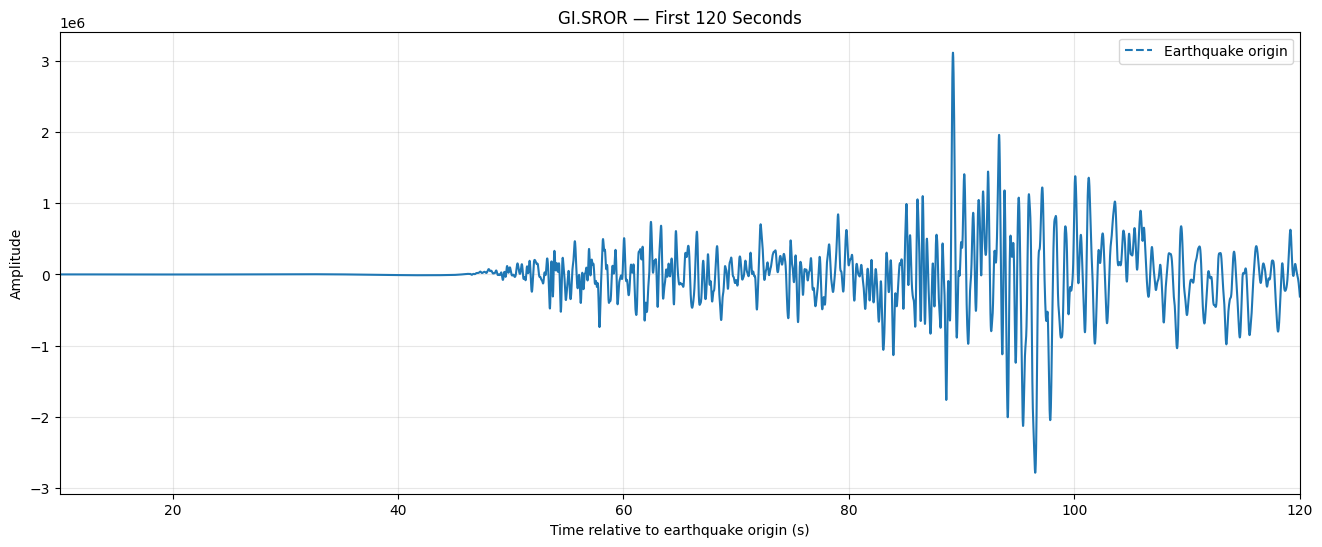

In [65]:
tr_sror = processed_waveforms["GI.SROR"][0]

time_sror = tr_sror.times(reftime=event_time)

plt.figure(figsize=(16, 6))
plt.plot(time_sror, tr_sror.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SROR — First 120 Seconds")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

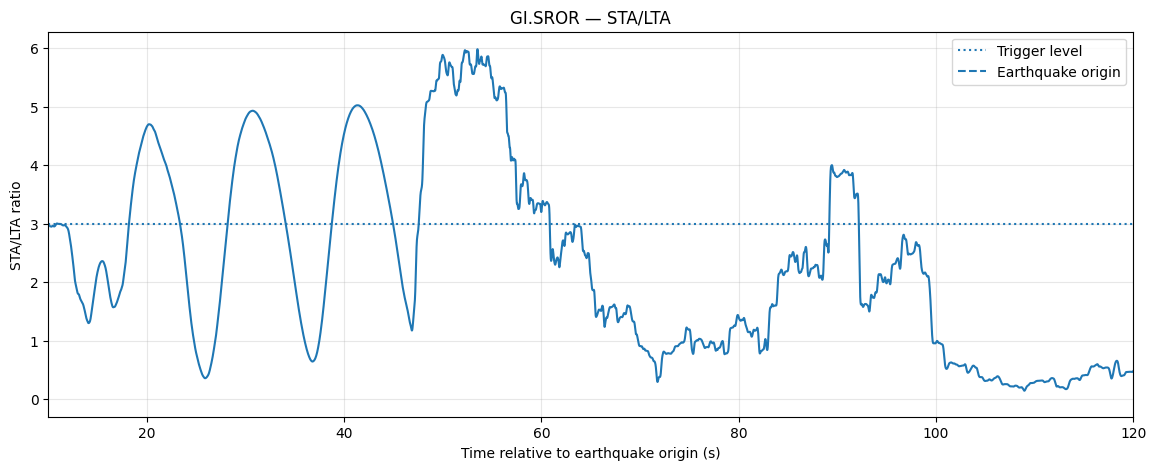

In [66]:
from obspy.signal.trigger import classic_sta_lta

tr_sror_pick = processed_waveforms["GI.SROR"][0].copy()

tr_sror_pick.trim(
    starttime=event_time - 10,
    endtime=event_time + 150
)

df = tr_sror_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_sror = classic_sta_lta(
    tr_sror_pick.data,
    sta_samples,
    lta_samples
)

time_sror_sta = np.arange(len(cft_sror)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_sror_sta, cft_sror)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.SROR — STA/LTA")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [67]:
for network in stations:
    for station in network:
        if network.code == "GI" and station.code == "SROR":
            print("Network :", network.code)
            print("Station :", station.code)
            print("Latitude:", station.latitude)
            print("Longitude:", station.longitude)
            print("Elevation:", station.elevation)

Network : GI
Station : SROR
Latitude: 14.231059
Longitude: -90.198398
Elevation: 1180.0


In [68]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

sror_lat = 14.231059
sror_lon = -90.198398

# Source–station angular distance
distance_sror = locations2degrees(
    14.57, -92.96,
    sror_lat, sror_lon
)

# IASP91 Earth model
model = TauPyModel(model="iasp91")

arrivals_sror = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_sror,
    phase_list=["P", "S"]
)

print("Distance:", distance_sror, "degrees")

for arrival in arrivals_sror:
    print(
        arrival.name,
        ":",
        round(arrival.time, 2),
        "s"
    )

Distance: 2.696203216057268 degrees
P : 42.02 s
P : 47.54 s
P : 47.73 s
S : 74.72 s
S : 82.34 s
S : 82.67 s


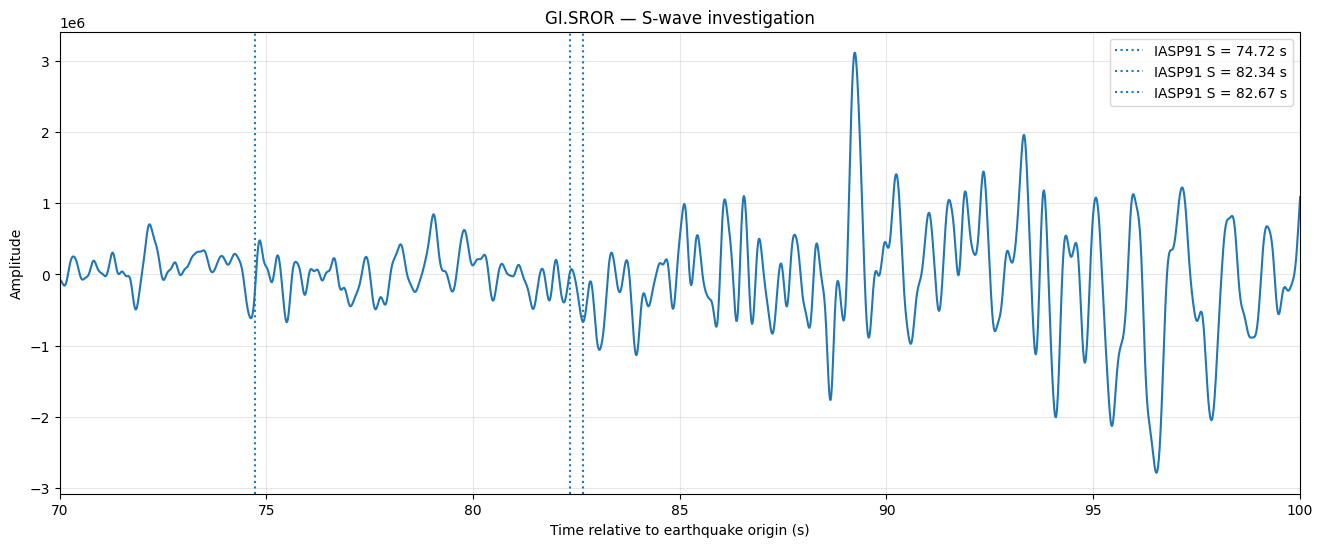

In [69]:
tr_sror = processed_waveforms["GI.SROR"][0]

time_sror = tr_sror.times(reftime=event_time)

plt.figure(figsize=(16, 6))

plt.plot(time_sror, tr_sror.data)

plt.axvline(
    74.72,
    linestyle=":",
    label="IASP91 S = 74.72 s"
)

plt.axvline(
    82.34,
    linestyle=":",
    label="IASP91 S = 82.34 s"
)

plt.axvline(
    82.67,
    linestyle=":",
    label="IASP91 S = 82.67 s"
)

plt.xlim(70, 100)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SROR — S-wave investigation")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

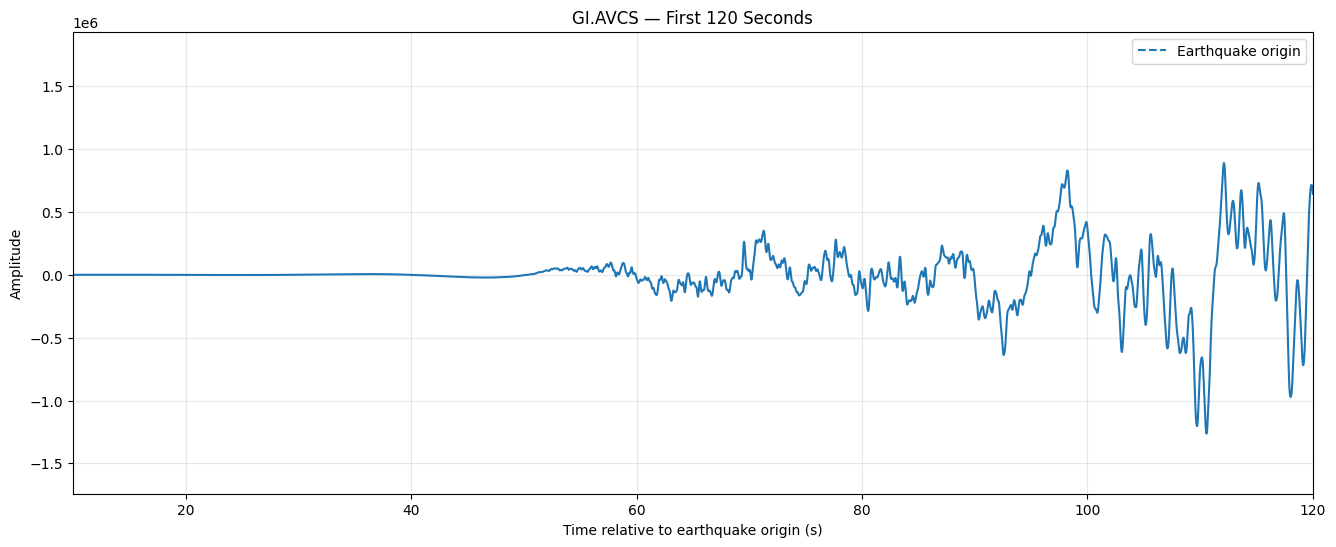

In [70]:
tr_avcs = processed_waveforms["GI.AVCS"][0]

time_avcs = tr_avcs.times(reftime=event_time)

plt.figure(figsize=(16, 6))

plt.plot(time_avcs, tr_avcs.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.AVCS — First 120 Seconds")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

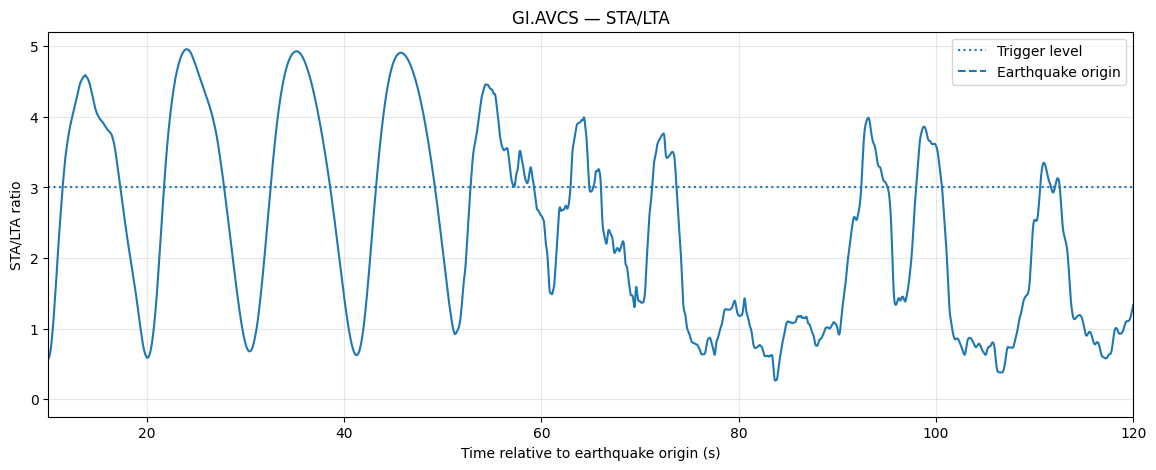

In [71]:
from obspy.signal.trigger import classic_sta_lta

tr_avcs_pick = processed_waveforms["GI.AVCS"][0].copy()

tr_avcs_pick.trim(
    starttime=event_time - 10,
    endtime=event_time + 150
)

df = tr_avcs_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_avcs = classic_sta_lta(
    tr_avcs_pick.data,
    sta_samples,
    lta_samples
)

time_avcs_sta = np.arange(len(cft_avcs)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time_avcs_sta, cft_avcs)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(10, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.AVCS — STA/LTA")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [72]:
for network in stations:
    for station in network:
        if network.code == "GI" and station.code == "AVCS":
            print("Network :", network.code)
            print("Station :", station.code)
            print("Latitude:", station.latitude)
            print("Longitude:", station.longitude)
            print("Elevation:", station.elevation)

Network : GI
Station : AVCS
Latitude: 15.815492
Longitude: -90.276573
Elevation: 157.0


In [73]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

avcs_lat = 15.815492
avcs_lon = -90.276573

# Source–station angular distance
distance_avcs = locations2degrees(
    14.57, -92.96,
    avcs_lat, avcs_lon
)

# IASP91 Earth model
model = TauPyModel(model="iasp91")

arrivals_avcs = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_avcs,
    phase_list=["P", "S"]
)

print("Distance:", distance_avcs, "degrees")

for arrival in arrivals_avcs:
    print(
        arrival.name,
        ":",
        round(arrival.time, 2),
        "s"
    )

Distance: 2.8735136766104596 degrees
P : 44.46 s
P : 50.56 s
P : 50.73 s
S : 79.1 s
S : 87.58 s
S : 87.88 s


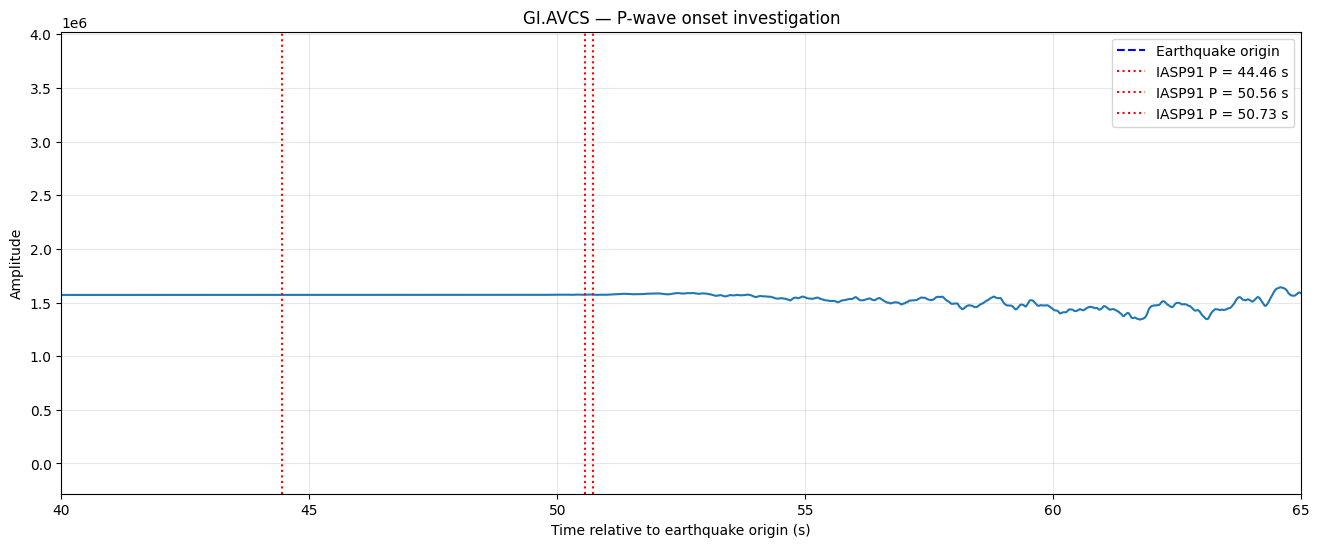

In [74]:
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import numpy as np

tr = all_waveforms["GI.AVCS"][0].copy()

# Time relative to earthquake origin
time = np.arange(len(tr.data)) / tr.stats.sampling_rate
time = time + (tr.stats.starttime - event_time)

plt.figure(figsize=(16, 6))

plt.plot(time, tr.data)

# Earthquake origin
plt.axvline(
    0,
    color="blue",
    linestyle="--",
    label="Earthquake origin"
)

# IASP91 P-wave arrivals
p_times_avcs = [44.46, 50.56, 50.73]

for p in p_times_avcs:
    plt.axvline(
        p,
        color="red",
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(40, 65)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.AVCS — P-wave onset investigation")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

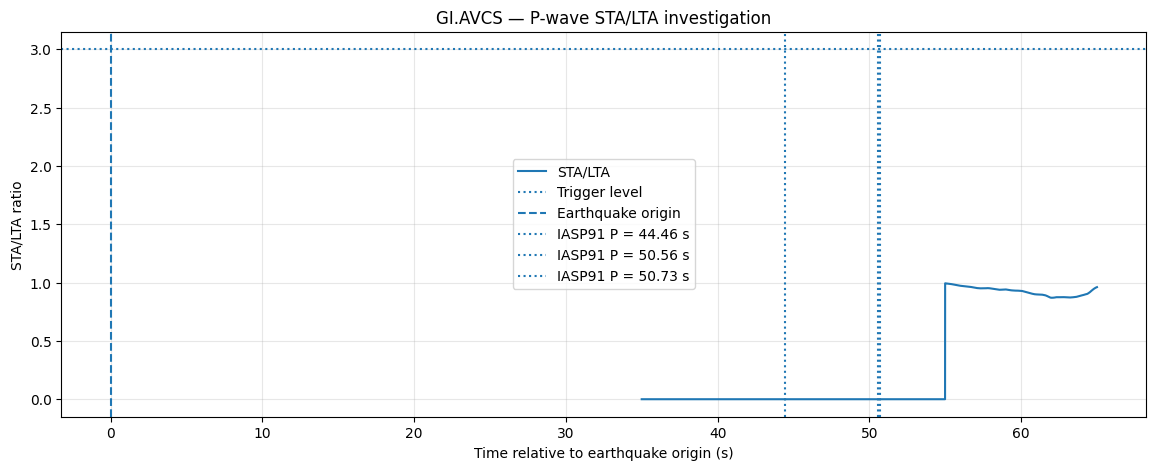

In [75]:
from obspy.signal.trigger import classic_sta_lta

# AVCS trace
tr_avcs = all_waveforms["GI.AVCS"][0].copy()

# Trim around the expected P-wave arrivals
tr_avcs.trim(
    starttime=event_time + 35,
    endtime=event_time + 65
)

# Sampling rate
df = tr_avcs.stats.sampling_rate

# STA/LTA window lengths
sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

# Calculate STA/LTA characteristic function
cft_avcs = classic_sta_lta(
    tr_avcs.data,
    sta_samples,
    lta_samples
)

# Time relative to earthquake origin
time_avcs = (
    tr_avcs.times()
    + (tr_avcs.stats.starttime - event_time)
)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    time_avcs,
    cft_avcs,
    label="STA/LTA"
)

# Trigger level
plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

# Earthquake origin
plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

# Theoretical P arrivals
for arrival in arrivals_avcs:
    if arrival.name == "P":
        plt.axvline(
            arrival.time,
            linestyle=":",
            label=f"IASP91 P = {arrival.time:.2f} s"
        )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.AVCS — P-wave STA/LTA investigation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

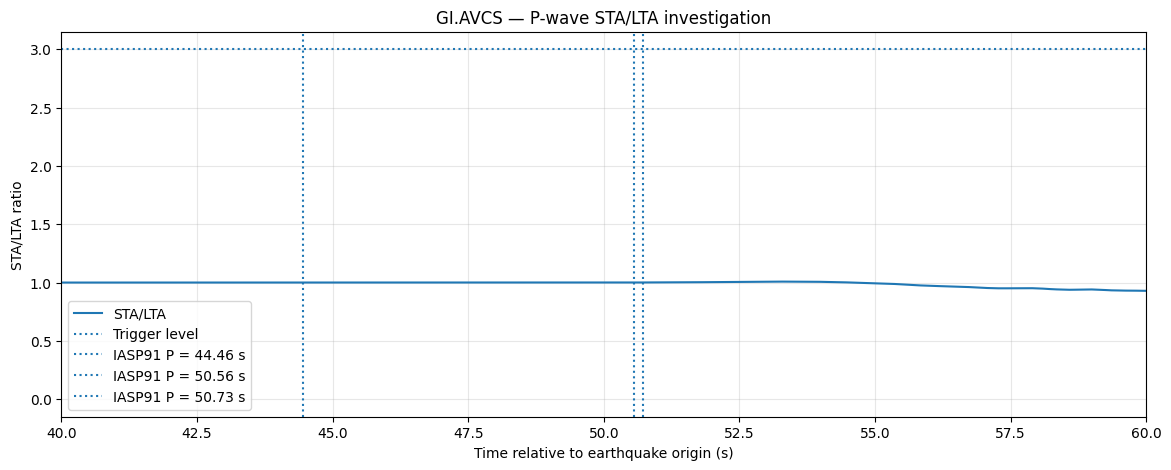

In [76]:
from obspy.signal.trigger import classic_sta_lta

# AVCS trace
tr_avcs = all_waveforms["GI.AVCS"][0].copy()

# Start well before the expected P arrivals
tr_avcs.trim(
    starttime=event_time + 20,
    endtime=event_time + 65
)

df = tr_avcs.stats.sampling_rate

# STA and LTA windows
sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

# STA/LTA
cft_avcs = classic_sta_lta(
    tr_avcs.data,
    sta_samples,
    lta_samples
)

# Time relative to earthquake origin
time_avcs = (
    tr_avcs.times()
    + (tr_avcs.stats.starttime - event_time)
)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    time_avcs,
    cft_avcs,
    label="STA/LTA"
)

# Trigger level
plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

# Theoretical P arrivals
for arrival in arrivals_avcs:
    if arrival.name == "P":
        plt.axvline(
            arrival.time,
            linestyle=":",
            label=f"IASP91 P = {arrival.time:.2f} s"
        )

plt.xlim(40, 60)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.AVCS — P-wave STA/LTA investigation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

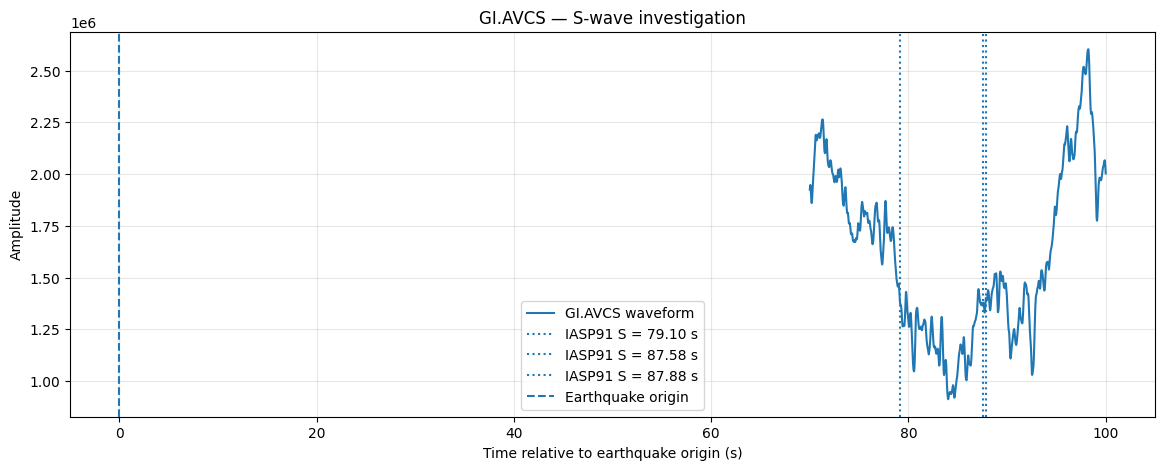

In [77]:
# AVCS trace
tr_avcs = all_waveforms["GI.AVCS"][0].copy()

# Focus around theoretical S arrivals
tr_avcs.trim(
    starttime=event_time + 70,
    endtime=event_time + 100
)

# Time relative to earthquake origin
time_avcs = (
    tr_avcs.times()
    + (tr_avcs.stats.starttime - event_time)
)

plt.figure(figsize=(14, 5))

plt.plot(
    time_avcs,
    tr_avcs.data,
    label="GI.AVCS waveform"
)

# Theoretical S arrivals
for arrival in arrivals_avcs:
    if arrival.name == "S":
        plt.axvline(
            arrival.time,
            linestyle=":",
            label=f"IASP91 S = {arrival.time:.2f} s"
        )

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.AVCS — S-wave investigation")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

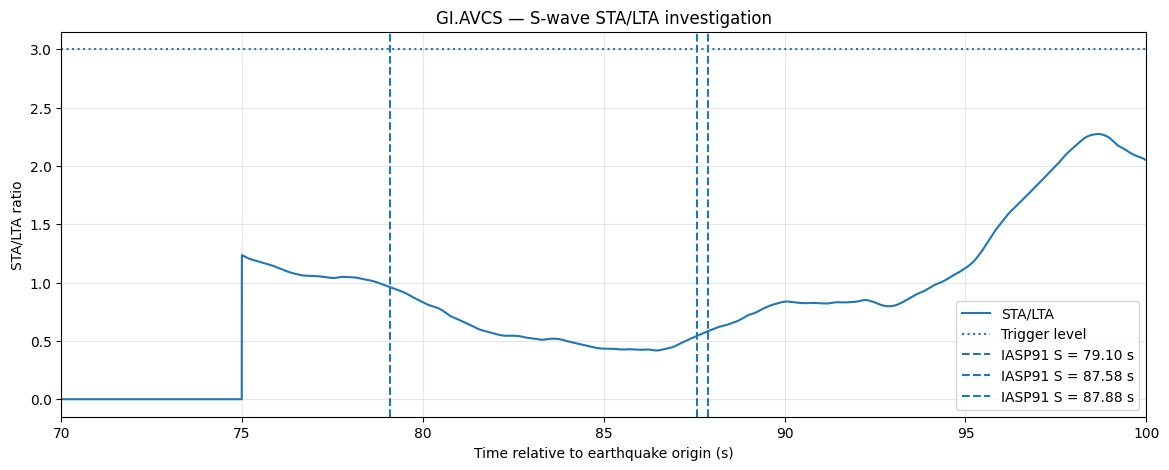

In [78]:
from obspy.signal.trigger import classic_sta_lta

# AVCS trace
tr_avcs = all_waveforms["GI.AVCS"][0].copy()

# Start early enough for the 20 s LTA window
tr_avcs.trim(
    starttime=event_time + 55,
    endtime=event_time + 100
)

df = tr_avcs.stats.sampling_rate

# STA/LTA windows
sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

# Calculate STA/LTA
cft_avcs = classic_sta_lta(
    tr_avcs.data,
    sta_samples,
    lta_samples
)

# Time relative to earthquake origin
time_avcs = (
    tr_avcs.times()
    + (tr_avcs.stats.starttime - event_time)
)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    time_avcs,
    cft_avcs,
    label="STA/LTA"
)

# Trigger level
plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

# Theoretical S arrivals
for arrival in arrivals_avcs:
    if arrival.name == "S":
        plt.axvline(
            arrival.time,
            linestyle="--",
            label=f"IASP91 S = {arrival.time:.2f} s"
        )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.AVCS — S-wave STA/LTA investigation")

plt.xlim(70, 100)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [79]:
st_nube = earthscope.get_waveforms(
    network="SV",
    station="NUBE",
    location="--",
    channel="HHZ",
    starttime=event_time - 60,
    endtime=event_time + 600
)

print(st_nube)

1 Trace(s) in Stream:
SV.NUBE..HHZ | 2026-07-17T14:47:39.890000Z - 2026-07-17T14:58:39.880000Z | 100.0 Hz, 66000 samples


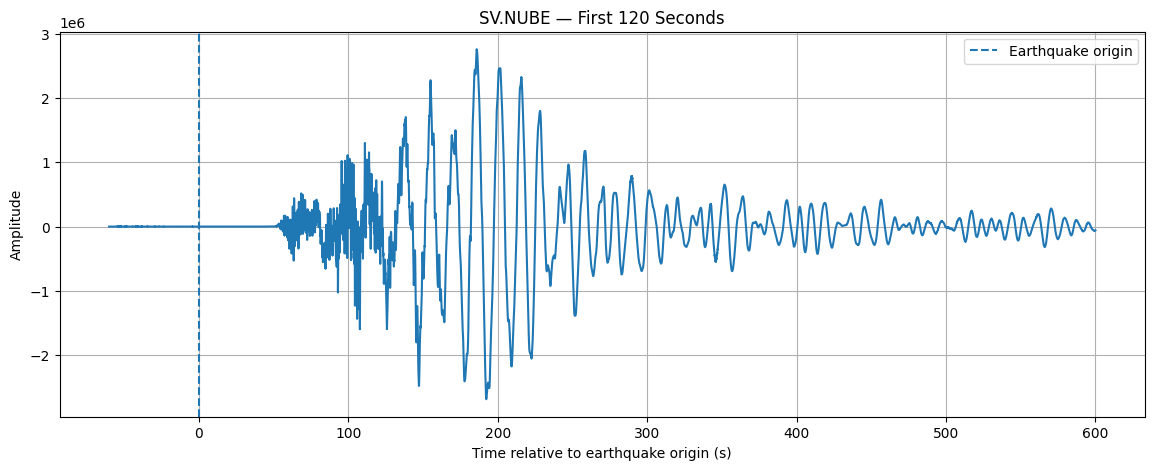

In [80]:
tr = st_nube[0]

time = tr.times()
time_relative = time - 60

plt.figure(figsize=(14, 5))
plt.plot(time_relative, tr.data)

plt.axvline(0, linestyle="--", label="Earthquake origin")

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.NUBE — First 120 Seconds")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
nube_inventory = earthscope.get_stations(
    network="SV",
    station="NUBE",
    level="station"
)

for net in nube_inventory:
    for sta in net:
        print(
            "Network:", net.code,
            "Station:", sta.code,
            "Latitude:", sta.latitude,
            "Longitude:", sta.longitude,
            "Elevation:", sta.elevation
        )

Network: SV Station: NUBE Latitude: 13.90216 Longitude: -89.779907 Elevation: 1306.4


In [82]:
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel

# NUBE coordinates
nube_lat = 13.90216
nube_lon = -89.779907

# Source–station angular distance
distance_nube = locations2degrees(
    14.57, -92.96,          # earthquake
    nube_lat, nube_lon      # NUBE
)

# IASP91 Earth model
model = TauPyModel(model="iasp91")

arrivals_nube = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_nube,
    phase_list=["P", "S"]
)

print("Distance:", distance_nube, "degrees")

for arrival in arrivals_nube:
    print(arrival.name, ":", round(arrival.time, 2), "s")

Distance: 3.1539081983444124 degrees
P : 48.31 s
P : 55.34 s
P : 55.48 s
S : 86.03 s
S : 95.87 s
S : 96.12 s


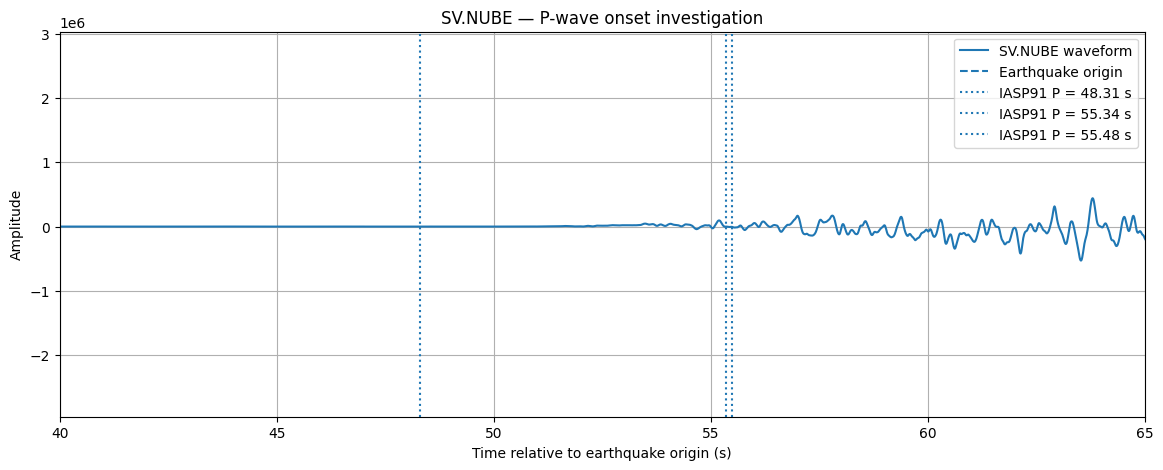

In [83]:
tr = st_nube[0]

# Time relative to earthquake origin
time = tr.times() - 60

# Plot P-wave window
plt.figure(figsize=(14, 5))

plt.plot(time, tr.data, label="SV.NUBE waveform")

# Earthquake origin
plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

# IASP91 theoretical P arrivals
p_times_nube = [48.31, 55.34, 55.48]

for i, p_time in enumerate(p_times_nube):
    plt.axvline(
        p_time,
        linestyle=":",
        label=f"IASP91 P = {p_time:.2f} s"
    )

plt.xlim(40, 65)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.NUBE — P-wave onset investigation")
plt.legend()
plt.grid(True)

plt.show()

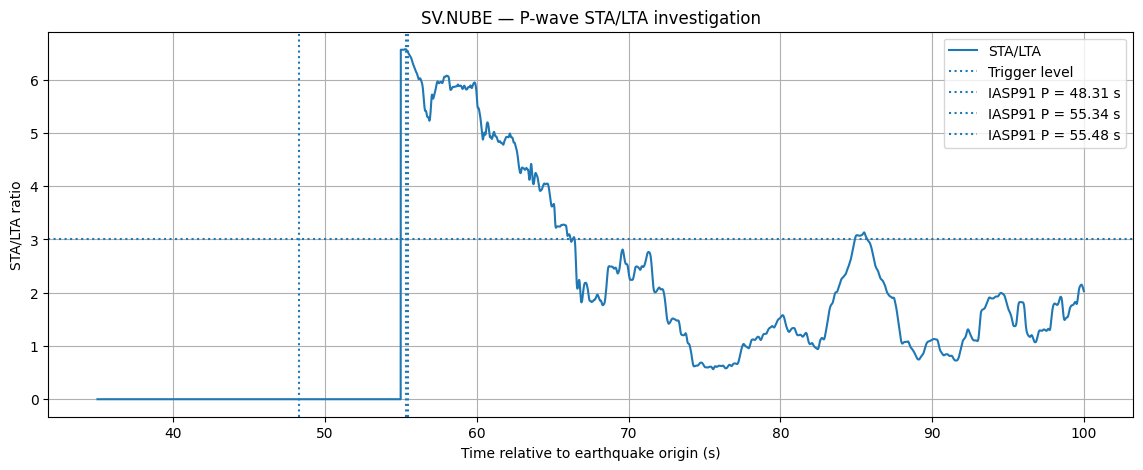

In [84]:
from obspy.signal.trigger import classic_sta_lta

tr_pick = st_nube[0].copy()

# Focus on the P-wave region
tr_pick.trim(
    starttime=event_time + 35,
    endtime=event_time + 100
)

df = tr_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr_pick.data,
    sta_samples,
    lta_samples
)

time_sta = tr_pick.times() + 35

plt.figure(figsize=(14, 5))

plt.plot(time_sta, cft, label="STA/LTA")

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

for p_time in [48.31, 55.34, 55.48]:
    plt.axvline(
        p_time,
        linestyle=":",
        label=f"IASP91 P = {p_time:.2f} s"
    )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("SV.NUBE — P-wave STA/LTA investigation")
plt.legend()
plt.grid(True)

plt.show()

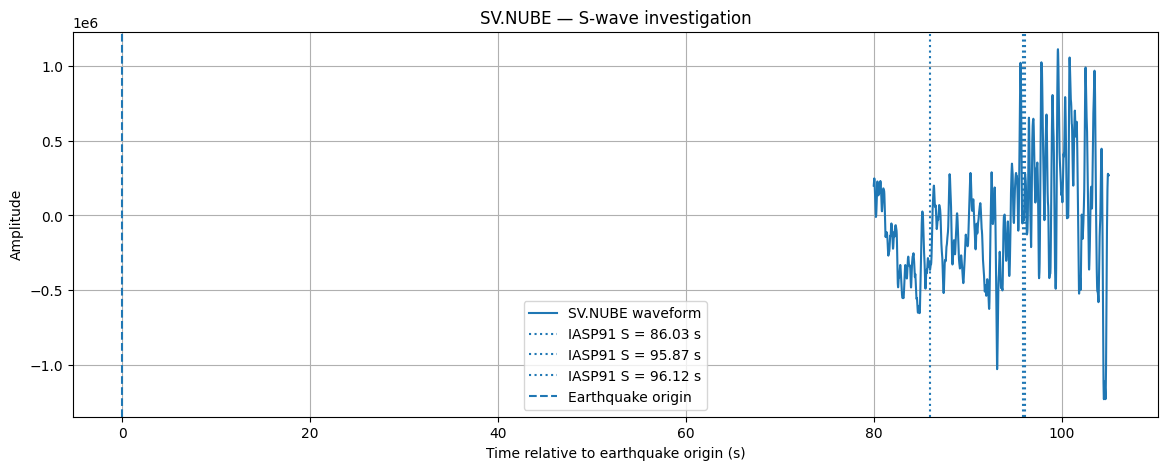

In [85]:
# SV.NUBE — S-wave investigation

tr_s = st_nube[0].copy()

tr_s.trim(
    starttime=event_time + 80,
    endtime=event_time + 105
)

time_s = tr_s.times() + 80

plt.figure(figsize=(14, 5))

plt.plot(
    time_s,
    tr_s.data,
    label="SV.NUBE waveform"
)

for s_time in [86.03, 95.87, 96.12]:
    plt.axvline(
        s_time,
        linestyle=":",
        label=f"IASP91 S = {s_time:.2f} s"
    )

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.NUBE — S-wave investigation")
plt.legend()
plt.grid(True)

plt.show()

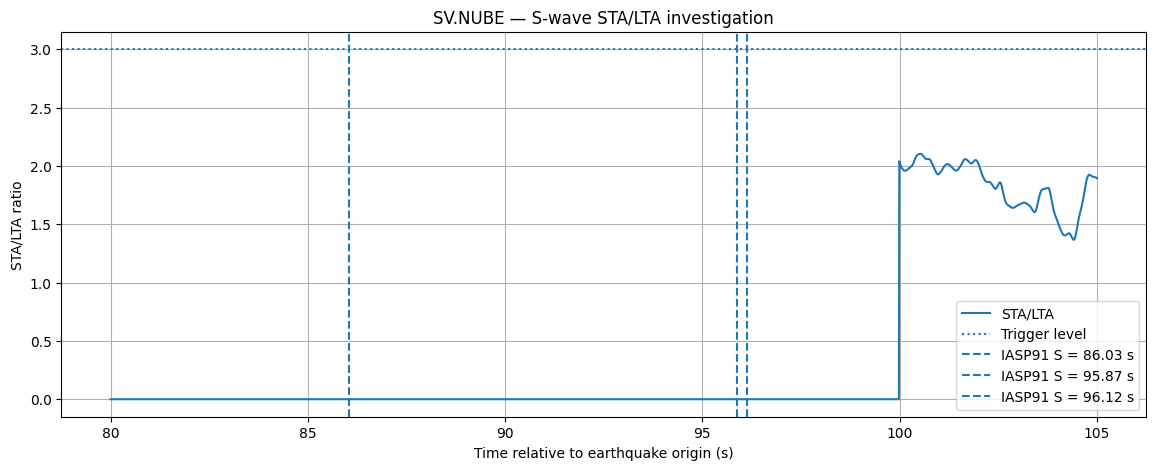

In [86]:
# SV.NUBE — S-wave STA/LTA investigation

from obspy.signal.trigger import classic_sta_lta

tr_s_pick = st_nube[0].copy()

# Focus around the expected S-wave arrivals
tr_s_pick.trim(
    starttime=event_time + 80,
    endtime=event_time + 105
)

df = tr_s_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_s = classic_sta_lta(
    tr_s_pick.data,
    sta_samples,
    lta_samples
)

time_s_sta = np.arange(len(cft_s)) / df + 80

plt.figure(figsize=(14, 5))

plt.plot(
    time_s_sta,
    cft_s,
    label="STA/LTA"
)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

for s_time in [86.03, 95.87, 96.12]:
    plt.axvline(
        s_time,
        linestyle="--",
        label=f"IASP91 S = {s_time:.2f} s"
    )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("SV.NUBE — S-wave STA/LTA investigation")
plt.legend()
plt.grid(True)

plt.show()

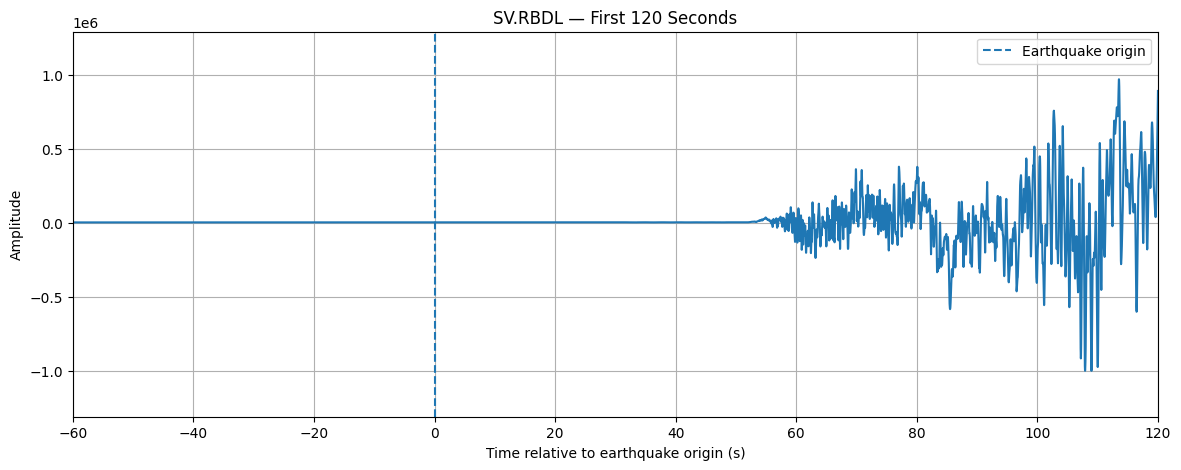

In [87]:
# SV.RBDL — First 120 seconds

st_rbdl = all_waveforms["SV.RBDL"].copy()

tr_rbdl = st_rbdl[0]

start = event_time - 60
time_rbdl = np.arange(tr_rbdl.stats.npts) / tr_rbdl.stats.sampling_rate
time_rbdl = time_rbdl - 60

plt.figure(figsize=(14, 5))

plt.plot(time_rbdl, tr_rbdl.data)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.xlim(-60, 120)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.RBDL — First 120 Seconds")

plt.legend()
plt.grid(True)
plt.show()

In [88]:
# Get exact SV.RBDL station coordinates

rbdl_inv = earthscope.get_stations(
    network="SV",
    station="RBDL",
    level="station"
)

rbdl_sta = rbdl_inv[0][0]

rbdl_lat = rbdl_sta.latitude
rbdl_lon = rbdl_sta.longitude
rbdl_elev = rbdl_sta.elevation

print("Network :", rbdl_sta.code)
print("Station :", rbdl_sta.code)
print("Latitude:", rbdl_lat)
print("Longitude:", rbdl_lon)
print("Elevation:", rbdl_elev)

Network : RBDL
Station : RBDL
Latitude: 14.113
Longitude: -89.6827
Elevation: 1431.0


In [89]:
# Distance and IASP91 theoretical arrivals

distance_deg_rbdl = locations2degrees(
    14.57, -92.96,       # earthquake
    rbdl_lat, rbdl_lon   # RBDL
)

print("Distance:", distance_deg_rbdl, "degrees")

model = TauPyModel(model="iasp91")

arrivals_rbdl = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_deg_rbdl,
    phase_list=["P", "S"]
)

for arr in arrivals_rbdl:
    print(arr.name, ":", round(arr.time, 2), "s")

Distance: 3.207851123216647 degrees
P : 49.06 s
P : 56.26 s
P : 56.4 s
S : 87.37 s
S : 97.46 s
S : 97.7 s


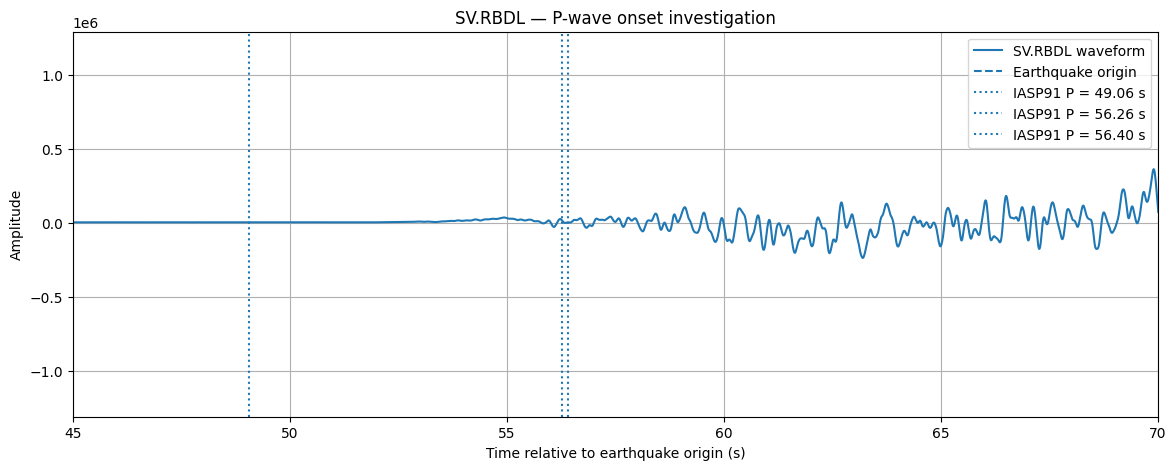

In [90]:
# SV.RBDL — P-wave onset investigation

tr_rbdl_p = st_rbdl[0].copy()

plt.figure(figsize=(14, 5))

time_rbdl = (
    np.arange(tr_rbdl_p.stats.npts)
    / tr_rbdl_p.stats.sampling_rate
    - 60
)

plt.plot(time_rbdl, tr_rbdl_p.data, label="SV.RBDL waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

# IASP91 theoretical P arrivals
for p_time in [49.06, 56.26, 56.40]:
    plt.axvline(
        p_time,
        linestyle=":",
        label=f"IASP91 P = {p_time:.2f} s"
    )

plt.xlim(45, 70)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.RBDL — P-wave onset investigation")

plt.legend()
plt.grid(True)
plt.show()

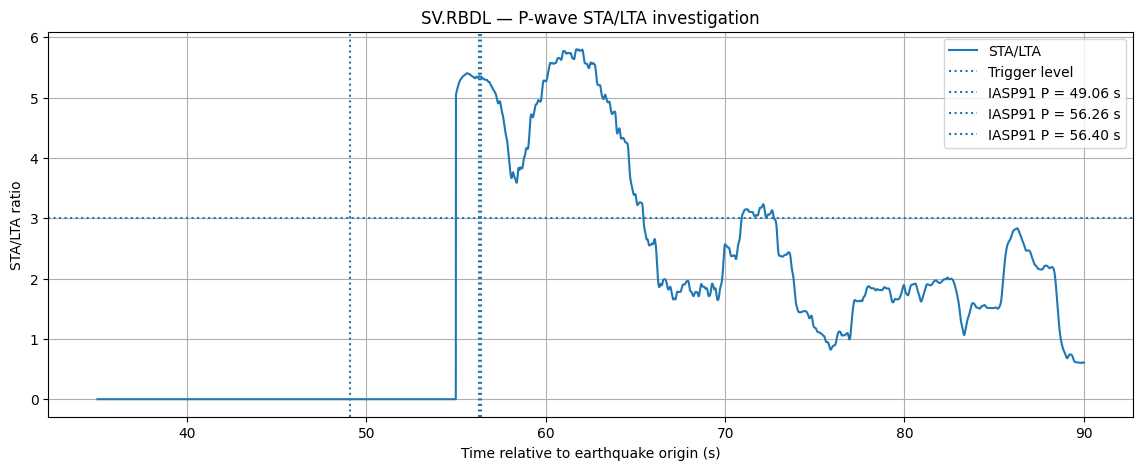

In [91]:
# SV.RBDL — P-wave STA/LTA investigation

tr_rbdl_pick = st_rbdl[0].copy()

tr_rbdl_pick.trim(
    starttime=event_time + 35,
    endtime=event_time + 90
)

df = tr_rbdl_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_rbdl = classic_sta_lta(
    tr_rbdl_pick.data,
    sta_samples,
    lta_samples
)

time_rbdl_sta = np.arange(len(cft_rbdl)) / df + 35

plt.figure(figsize=(14, 5))

plt.plot(
    time_rbdl_sta,
    cft_rbdl,
    label="STA/LTA"
)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

for p_time in [49.06, 56.26, 56.40]:
    plt.axvline(
        p_time,
        linestyle=":",
        label=f"IASP91 P = {p_time:.2f} s"
    )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("SV.RBDL — P-wave STA/LTA investigation")

plt.legend()
plt.grid(True)

plt.show()

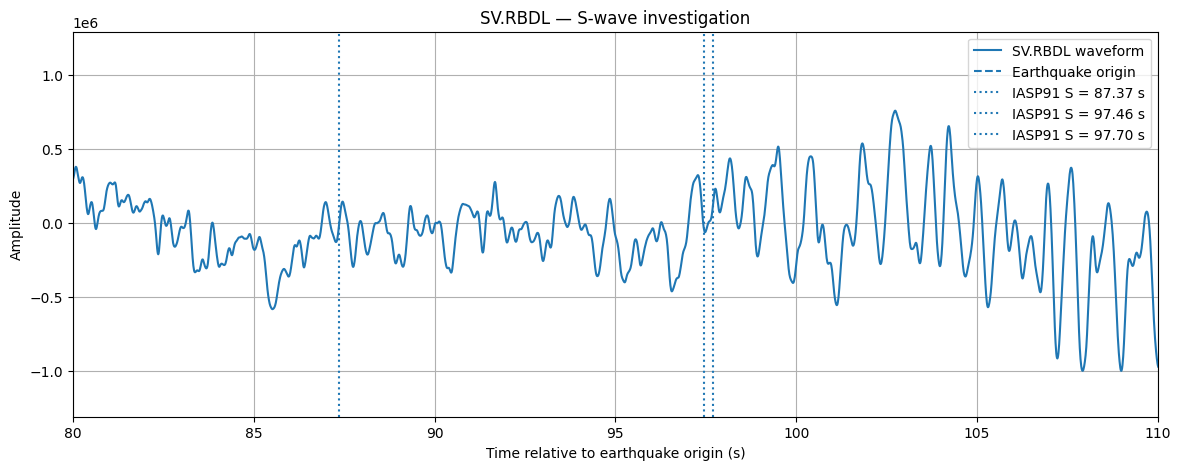

In [92]:
# SV.RBDL — S-wave investigation

tr_rbdl_s = st_rbdl[0].copy()

plt.figure(figsize=(14, 5))

time_rbdl_s = (
    np.arange(tr_rbdl_s.stats.npts)
    / tr_rbdl_s.stats.sampling_rate
    - 60
)

plt.plot(
    time_rbdl_s,
    tr_rbdl_s.data,
    label="SV.RBDL waveform"
)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

# IASP91 theoretical S arrivals
for s_time in [87.37, 97.46, 97.70]:
    plt.axvline(
        s_time,
        linestyle=":",
        label=f"IASP91 S = {s_time:.2f} s"
    )

plt.xlim(80, 110)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("SV.RBDL — S-wave investigation")

plt.legend()
plt.grid(True)

plt.show()

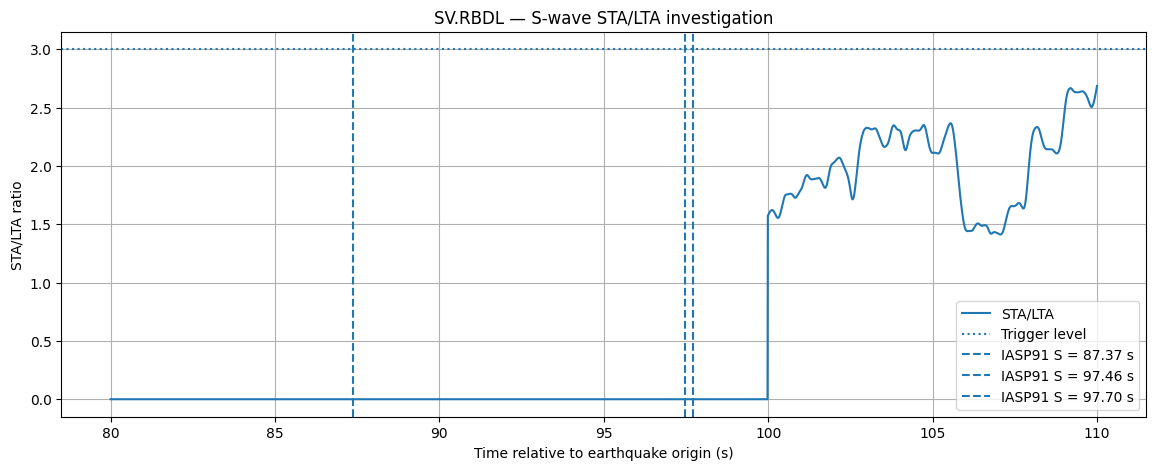

In [93]:
# SV.RBDL — S-wave STA/LTA investigation

tr_rbdl_s_pick = st_rbdl[0].copy()

tr_rbdl_s_pick.trim(
    starttime=event_time + 80,
    endtime=event_time + 110
)

df = tr_rbdl_s_pick.stats.sampling_rate

sta_seconds = 3
lta_seconds = 20

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft_rbdl_s = classic_sta_lta(
    tr_rbdl_s_pick.data,
    sta_samples,
    lta_samples
)

time_rbdl_s_sta = np.arange(len(cft_rbdl_s)) / df + 80

plt.figure(figsize=(14, 5))

plt.plot(
    time_rbdl_s_sta,
    cft_rbdl_s,
    label="STA/LTA"
)

plt.axhline(
    3,
    linestyle=":",
    label="Trigger level"
)

for s_time in [87.37, 97.46, 97.70]:
    plt.axvline(
        s_time,
        linestyle="--",
        label=f"IASP91 S = {s_time:.2f} s"
    )

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("SV.RBDL — S-wave STA/LTA investigation")

plt.legend()
plt.grid(True)

plt.show()

In [94]:
# Final station results table

import pandas as pd

results = pd.DataFrame([
    ["GI.HUCU", 1.2881, 24.5, 41.0],
    ["GI.SUCU", None, None, None],
    ["GI.GUVC", None, None, None],
    ["GI.QCIX", None, None, None],
    ["GI.GUSP", None, None, None],
    ["GI.SROR", 2.6962, None, None],
    ["GI.AVCS", 2.8735, None, None],
    ["SV.NUBE", 3.1539, 55.0, 97.6],
    ["SV.RBDL", 3.2079, 56.3, 97.6]
], columns=[
    "Station",
    "Distance_deg",
    "P_obs_s",
    "S_obs_s"
])

results["S_minus_P_s"] = (
    results["S_obs_s"] - results["P_obs_s"]
)

results

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s
0,GI.HUCU,1.2881,24.5,41.0,16.5
1,GI.SUCU,NaN,NaN,NaN,NaN
2,GI.GUVC,NaN,NaN,NaN,NaN
3,GI.QCIX,NaN,NaN,NaN,NaN
4,GI.GUSP,NaN,NaN,NaN,NaN
5,GI.SROR,2.6962,NaN,NaN,NaN
6,GI.AVCS,2.8735,NaN,NaN,NaN
7,SV.NUBE,3.1539,55.0,97.6,42.6
8,SV.RBDL,3.2079,56.3,97.6,41.3


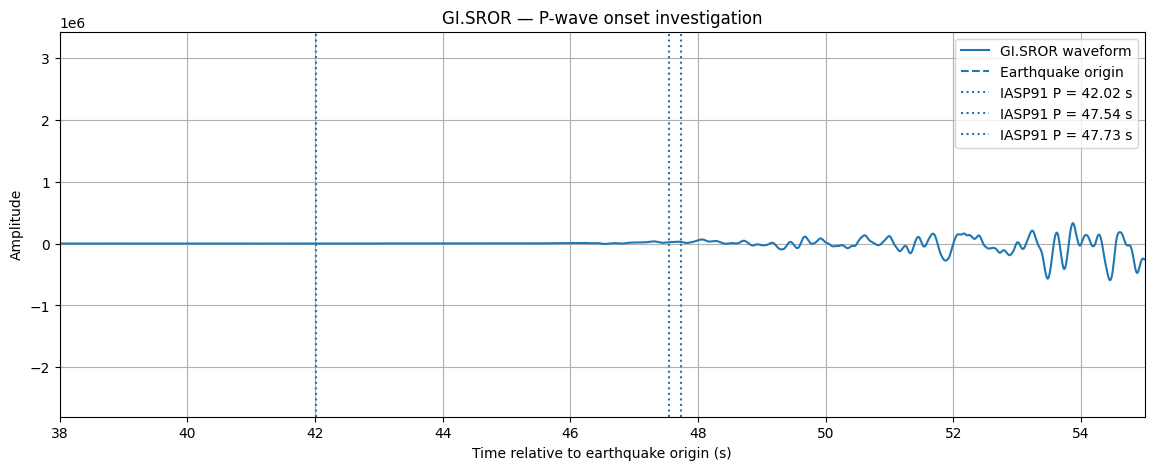

In [95]:
# SROR — P-wave onset investigation

station = "GI.SROR"
tr = all_waveforms[station][0].copy()

# Removing mean/trend
tr.detrend("linear")

# Time relative to earthquake origin
times = tr.times(reftime=event_time)

# Theoretical P arrivals
p_arrivals = [42.02, 47.54, 47.73]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.SROR waveform")

# Earthquake origin
plt.axvline(0, linestyle="--", label="Earthquake origin")

# Theoretical P arrivals
for p in p_arrivals:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(38, 55)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SROR — P-wave onset investigation")
plt.legend()
plt.grid(True)

plt.show()

In [96]:
results.loc[results["Station"] == "GI.SROR", "P_obs_s"] = 47.5

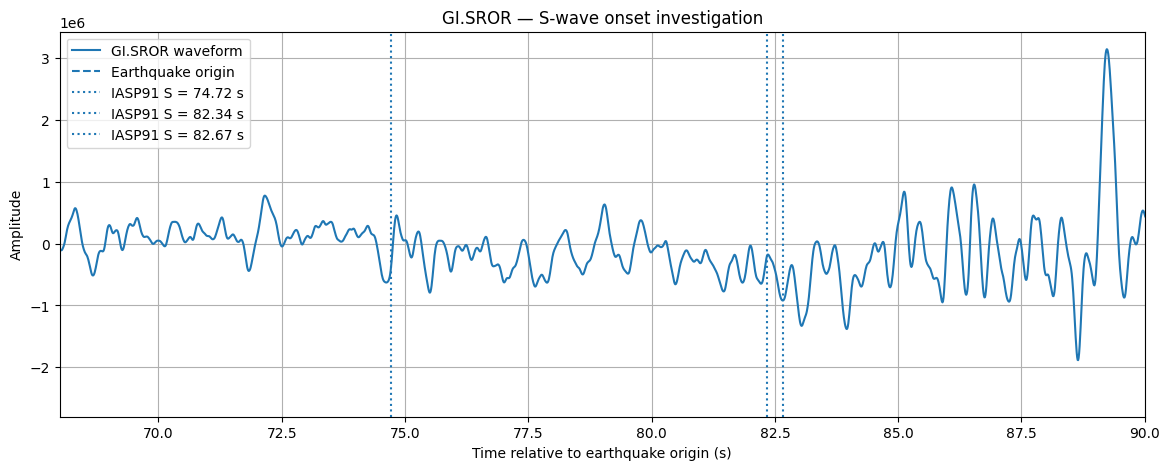

In [97]:
# SROR — S-wave onset investigation

station = "GI.SROR"
tr = all_waveforms[station][0].copy()

tr.detrend("linear")

times = tr.times(reftime=event_time)

# Theoretical S arrivals
s_arrivals = [74.72, 82.34, 82.67]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.SROR waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for s in s_arrivals:
    plt.axvline(
        s,
        linestyle=":",
        label=f"IASP91 S = {s:.2f} s"
    )

plt.xlim(68, 90)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SROR — S-wave onset investigation")
plt.legend()
plt.grid(True)

plt.show()

In [98]:
results.loc[results["Station"] == "GI.SROR", "S_obs_s"] = 84.8

results.loc[
    results["Station"] == "GI.SROR",
    "S_minus_P_s"
] = (
    results.loc[results["Station"] == "GI.SROR", "S_obs_s"]
    - results.loc[results["Station"] == "GI.SROR", "P_obs_s"]
)

results

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s
0,GI.HUCU,1.2881,24.5,41.0,16.5
1,GI.SUCU,NaN,NaN,NaN,NaN
2,GI.GUVC,NaN,NaN,NaN,NaN
3,GI.QCIX,NaN,NaN,NaN,NaN
4,GI.GUSP,NaN,NaN,NaN,NaN
5,GI.SROR,2.6962,47.5,84.8,37.3
6,GI.AVCS,2.8735,NaN,NaN,NaN
7,SV.NUBE,3.1539,55.0,97.6,42.6
8,SV.RBDL,3.2079,56.3,97.6,41.3


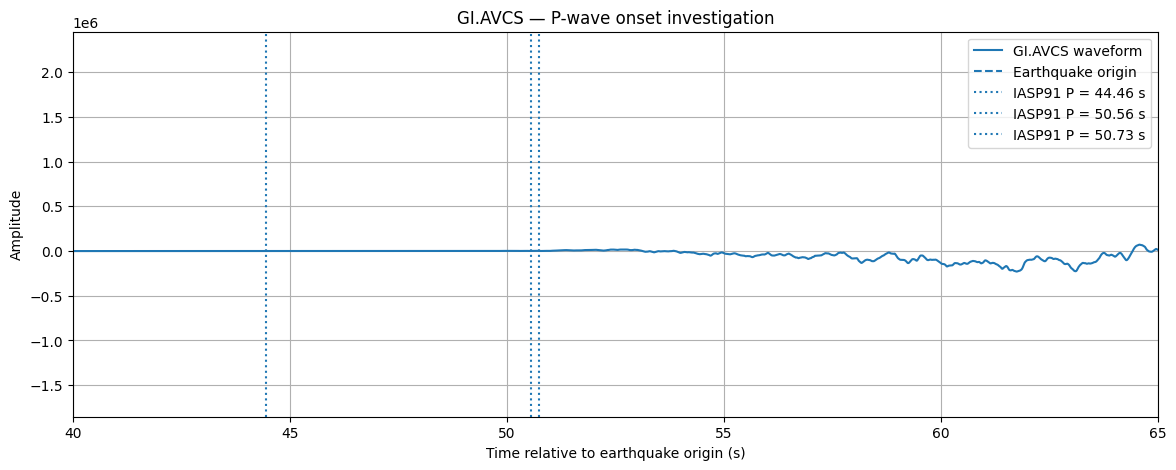

In [99]:
# GI.AVCS — P-wave onset investigation

station = "GI.AVCS"
tr = all_waveforms[station][0].copy()

tr.detrend("linear")

times = tr.times(reftime=event_time)

p_arrivals = [44.46, 50.56, 50.73]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.AVCS waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for p in p_arrivals:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(40, 65)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.AVCS — P-wave onset investigation")
plt.legend()
plt.grid(True)

plt.show()

In [100]:
results.loc[results["Station"] == "GI.AVCS", "P_obs_s"] = 50.6

results

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s
0,GI.HUCU,1.2881,24.5,41.0,16.5
1,GI.SUCU,NaN,NaN,NaN,NaN
2,GI.GUVC,NaN,NaN,NaN,NaN
3,GI.QCIX,NaN,NaN,NaN,NaN
4,GI.GUSP,NaN,NaN,NaN,NaN
5,GI.SROR,2.6962,47.5,84.8,37.3
6,GI.AVCS,2.8735,50.6,NaN,NaN
7,SV.NUBE,3.1539,55.0,97.6,42.6
8,SV.RBDL,3.2079,56.3,97.6,41.3


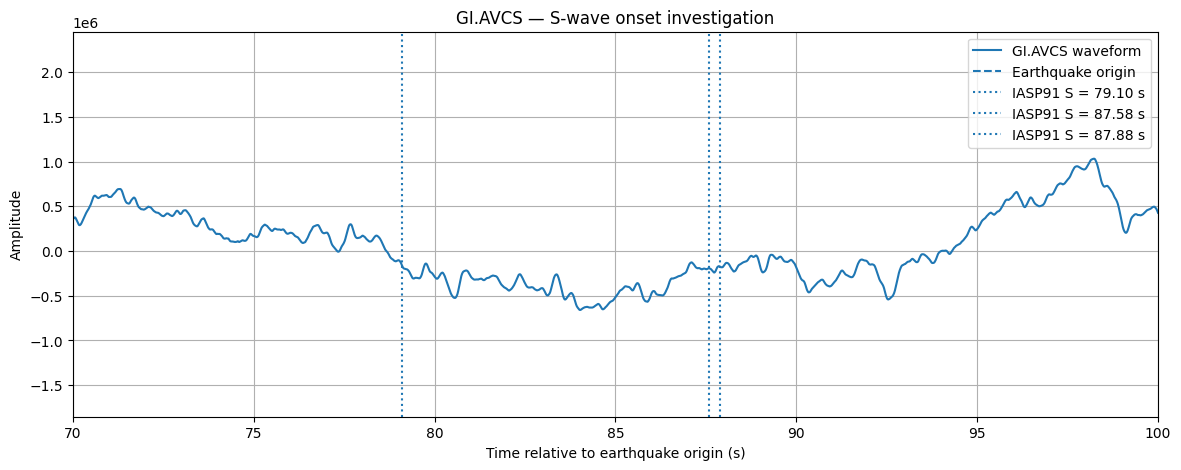

In [101]:
# GI.AVCS — S-wave onset investigation

station = "GI.AVCS"
tr = all_waveforms[station][0].copy()

tr.detrend("linear")

times = tr.times(reftime=event_time)

s_arrivals = [79.10, 87.58, 87.88]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.AVCS waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for s in s_arrivals:
    plt.axvline(
        s,
        linestyle=":",
        label=f"IASP91 S = {s:.2f} s"
    )

plt.xlim(70, 100)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.AVCS — S-wave onset investigation")
plt.legend()
plt.grid(True)

plt.show()

In [102]:
# GI.SUCU — correct station coordinates

station_lat = 14.560000
station_lon = -91.557000

distance_deg = locations2degrees(
    14.57, -92.96,          # earthquake
    station_lat, station_lon
)

print(f"GI.SUCU distance = {distance_deg:.4f} degrees")

arrivals = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_deg,
    phase_list=["P", "S"]
)

print("\nTheoretical arrivals:")
for a in arrivals:
    if a.name.startswith("P") or a.name.startswith("S"):
        print(f"{a.name}: {a.time:.2f} s")

GI.SUCU distance = 1.3579 degrees

Theoretical arrivals:
P: 23.62 s
P: 25.22 s
S: 41.61 s
S: 43.67 s


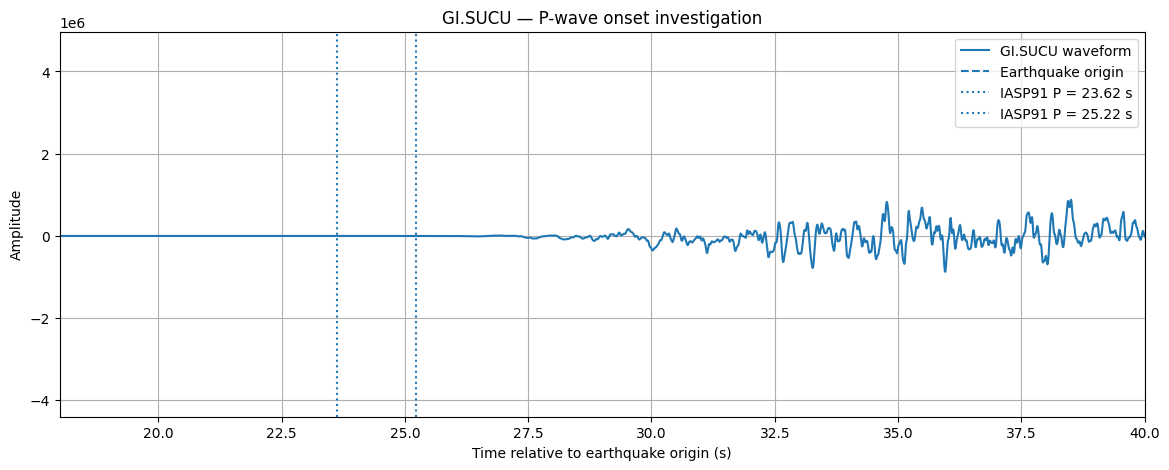

In [103]:
# GI.SUCU — corrected P-wave onset investigation

station = "GI.SUCU"
tr = all_waveforms[station][0].copy()

tr.detrend("linear")

times = tr.times(reftime=event_time)

p_arrivals = [23.62, 25.22]

plt.figure(figsize=(14, 5))

plt.plot(
    times,
    tr.data,
    label="GI.SUCU waveform"
)

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for p in p_arrivals:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(18, 40)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SUCU — P-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

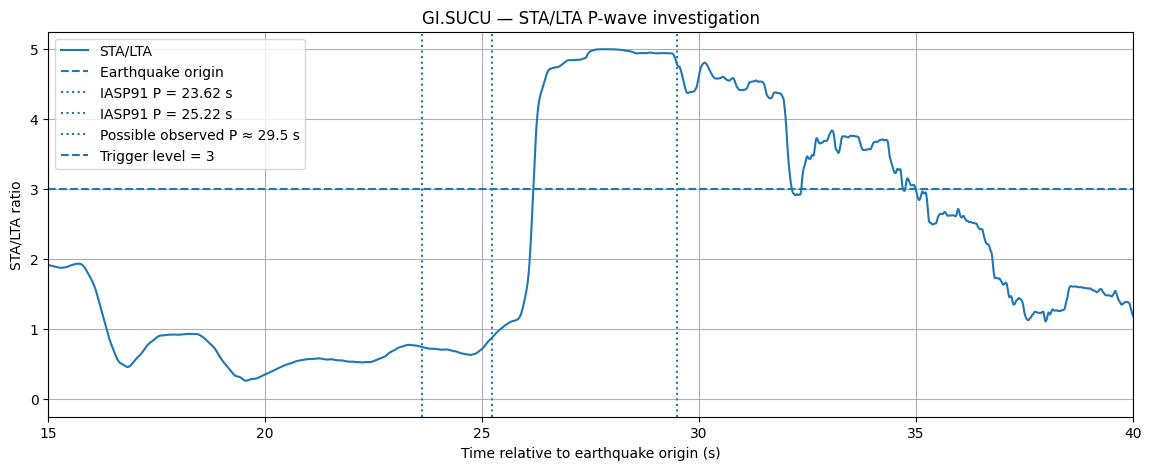

In [104]:
from obspy.signal.trigger import classic_sta_lta

tr_pick = all_waveforms["GI.SUCU"][0].copy()
tr_pick.detrend("linear")

# Focus around the suspected P arrival
tr_pick.trim(
    starttime=event_time - 10,
    endtime=event_time + 60
)

df = tr_pick.stats.sampling_rate

sta_seconds = 2
lta_seconds = 10

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr_pick.data,
    sta_samples,
    lta_samples
)

time = np.arange(len(cft)) / df - 10

plt.figure(figsize=(14, 5))

plt.plot(time, cft, label="STA/LTA")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

plt.axvline(
    23.62,
    linestyle=":",
    label="IASP91 P = 23.62 s"
)

plt.axvline(
    25.22,
    linestyle=":",
    label="IASP91 P = 25.22 s"
)

plt.axvline(
    29.5,
    linestyle=":",
    label="Possible observed P ≈ 29.5 s"
)

plt.axhline(
    3,
    linestyle="--",
    label="Trigger level = 3"
)

plt.xlim(15, 40)
plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.SUCU — STA/LTA P-wave investigation")
plt.legend()
plt.grid()
plt.show()

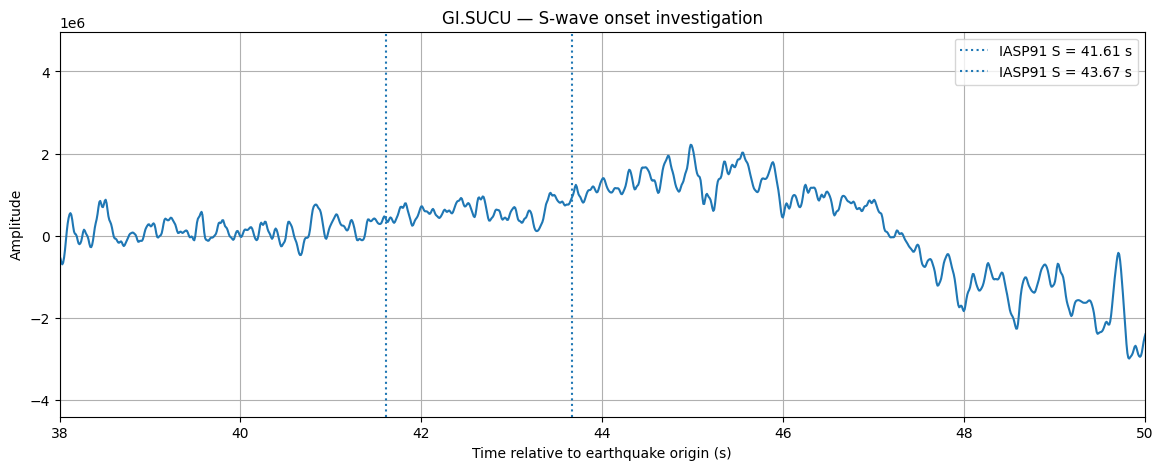

In [105]:
tr = all_waveforms["GI.SUCU"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data)

plt.axvline(41.61, linestyle=":", label="IASP91 S = 41.61 s")
plt.axvline(43.67, linestyle=":", label="IASP91 S = 43.67 s")

plt.xlim(38, 50)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.SUCU — S-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

In [106]:
# GI.GUVC — station distance and theoretical arrivals

station_lat = 14.532
station_lon = -90.498

distance_deg = locations2degrees(
    14.57, -92.96,          # earthquake
    station_lat, station_lon
)

print(f"GI.GUVC distance = {distance_deg:.4f} degrees")

arrivals = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_deg,
    phase_list=["P", "S"]
)

print("\nTheoretical arrivals:")

for a in arrivals:
    if a.name.startswith("P") or a.name.startswith("S"):
        print(f"{a.name}: {a.time:.2f} s")

GI.GUVC distance = 2.3833 degrees

Theoretical arrivals:
P: 37.72 s
P: 42.20 s
P: 42.43 s
S: 66.98 s
S: 73.10 s
S: 73.50 s


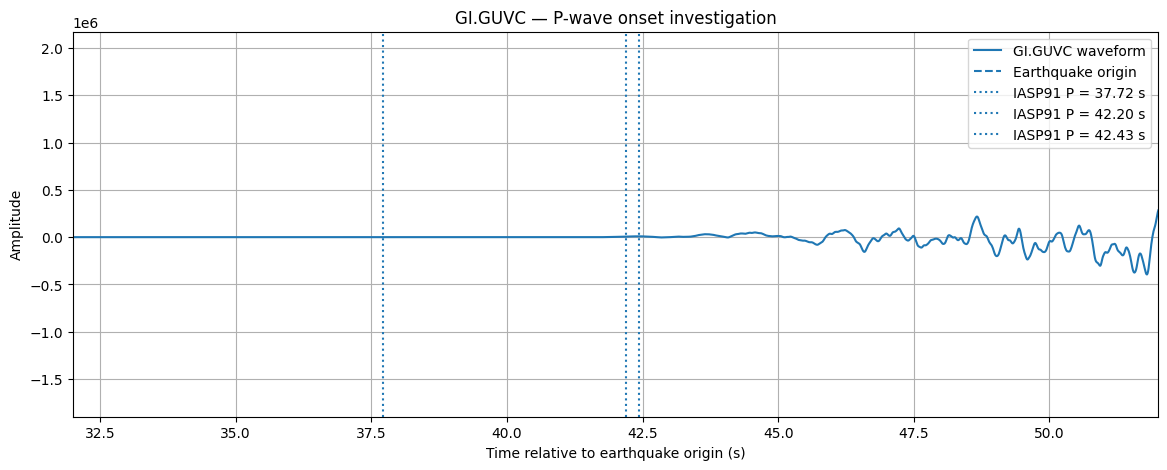

In [107]:
# GI.GUVC — P-wave onset investigation

tr = all_waveforms["GI.GUVC"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

p_arrivals = [37.72, 42.20, 42.43]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.GUVC waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for p in p_arrivals:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(32, 52)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUVC — P-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

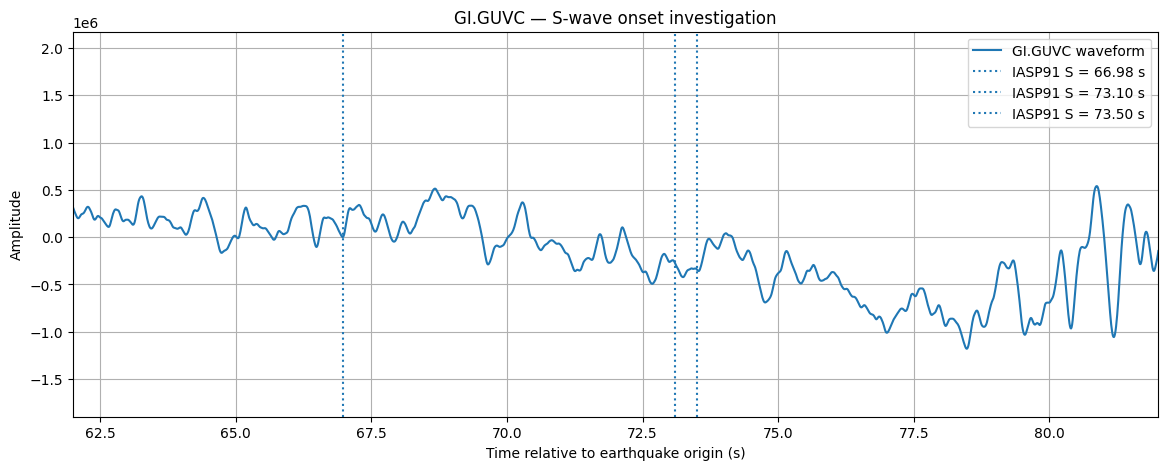

In [108]:
# GI.GUVC — S-wave onset investigation

tr = all_waveforms["GI.GUVC"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

s_arrivals = [66.98, 73.10, 73.50]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.GUVC waveform")

for s in s_arrivals:
    plt.axvline(
        s,
        linestyle=":",
        label=f"IASP91 S = {s:.2f} s"
    )

plt.xlim(62, 82)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUVC — S-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

In [109]:
# GI.QCIX — station distance and theoretical arrivals

station_lat = 16.003414
station_lon = -90.777245

distance_deg = locations2degrees(
    14.57, -92.96,
    station_lat, station_lon
)

print(f"GI.QCIX distance = {distance_deg:.4f} degrees")

arrivals = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_deg,
    phase_list=["P", "S"]
)

print("\nTheoretical arrivals:")

for a in arrivals:
    if a.name.startswith("P") or a.name.startswith("S"):
        print(f"{a.name}: {a.time:.2f} s")

GI.QCIX distance = 2.5471 degrees

Theoretical arrivals:
P: 39.97 s
P: 45.00 s
P: 45.20 s
S: 71.03 s
S: 77.94 s
S: 78.30 s


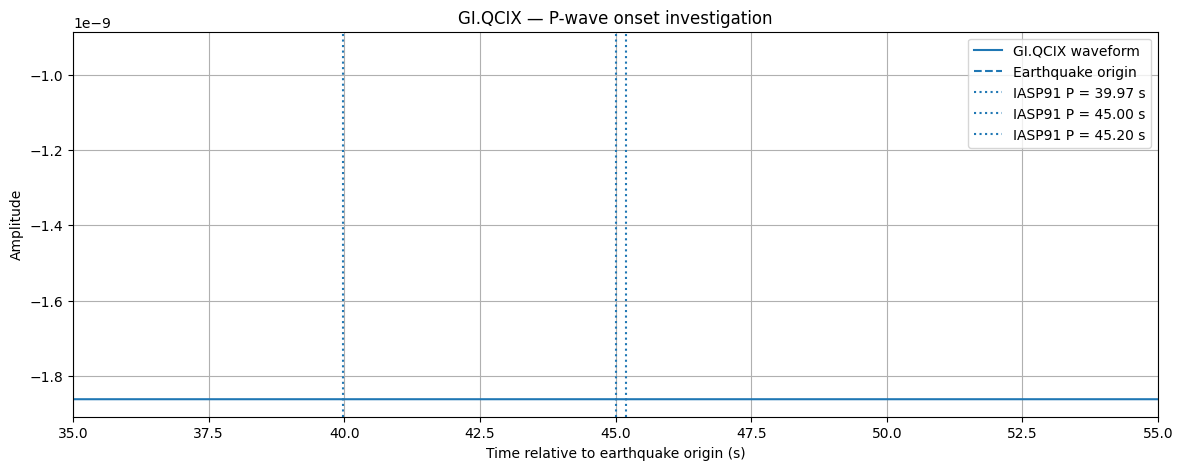

In [110]:
# GI.QCIX — P-wave onset investigation

tr = all_waveforms["GI.QCIX"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

p_arrivals = [39.97, 45.00, 45.20]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.QCIX waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for p in p_arrivals:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(35, 55)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.QCIX — P-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

In [111]:
tr = all_waveforms["GI.QCIX"][0]

print("Minimum:", tr.data.min())
print("Maximum:", tr.data.max())
print("Mean:", tr.data.mean())
print("Standard deviation:", tr.data.std())
print("Sampling rate:", tr.stats.sampling_rate)
print("Number of samples:", len(tr.data))

Minimum: 8388607
Maximum: 8388607
Mean: 8388607.0
Standard deviation: 0.0
Sampling rate: 100.0
Number of samples: 66000


In [112]:
# GI.GUSP — station distance and theoretical arrivals

station_lat = 14.552
station_lon = -90.3168

distance_deg = locations2degrees(
    14.57, -92.96,
    station_lat, station_lon
)

print(f"GI.GUSP distance = {distance_deg:.4f} degrees")

arrivals = model.get_travel_times(
    source_depth_in_km=22.0,
    distance_in_degree=distance_deg,
    phase_list=["P", "S"]
)

print("\nTheoretical arrivals:")

for a in arrivals:
    if a.name.startswith("P") or a.name.startswith("S"):
        print(f"{a.name}: {a.time:.2f} s")

GI.GUSP distance = 2.5584 degrees

Theoretical arrivals:
P: 40.13 s
P: 45.19 s
P: 45.39 s
S: 71.31 s
S: 78.27 s
S: 78.63 s


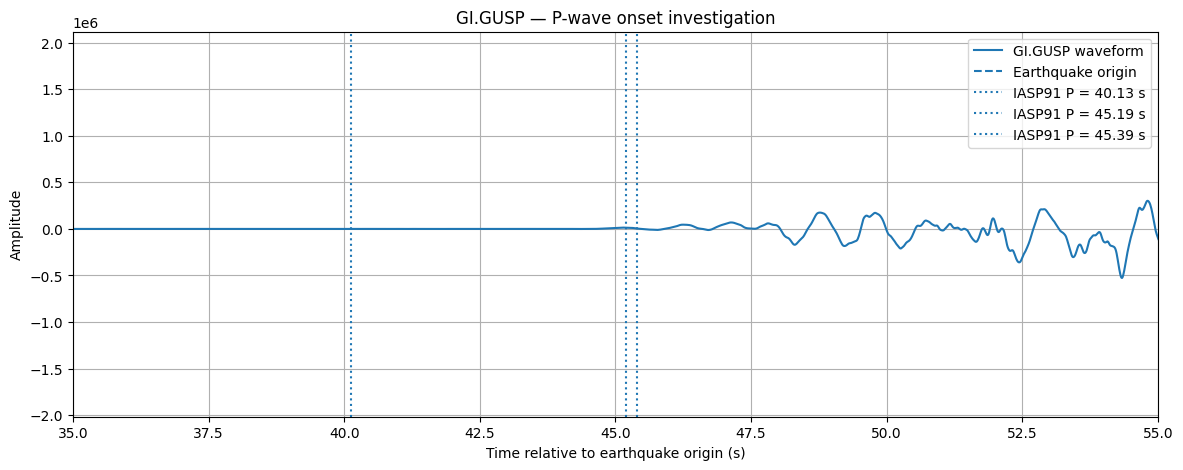

In [113]:
tr = all_waveforms["GI.GUSP"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.GUSP waveform")

plt.axvline(
    0,
    linestyle="--",
    label="Earthquake origin"
)

for p in [40.13, 45.19, 45.39]:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.xlim(35, 55)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUSP — P-wave onset investigation")
plt.legend()
plt.grid()
plt.show()

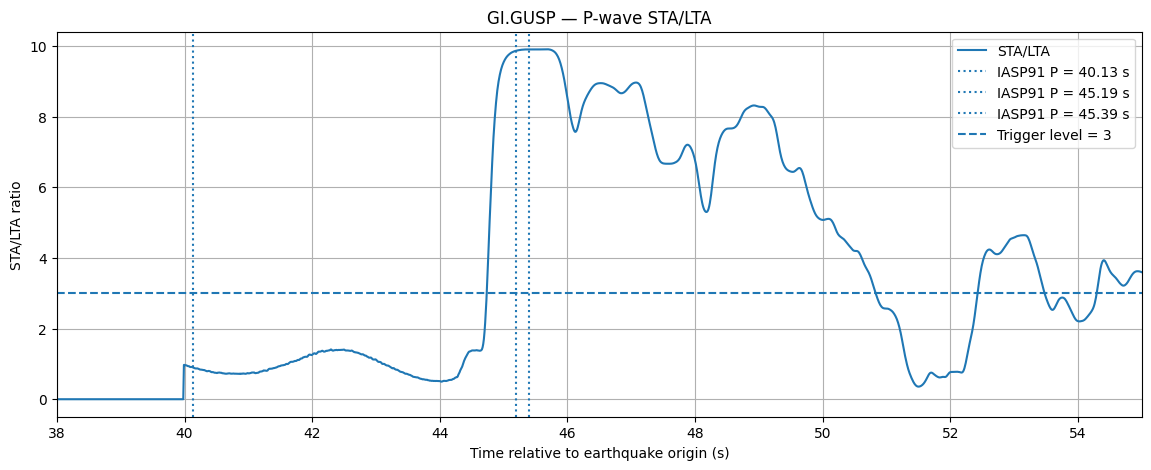

In [114]:
from obspy.signal.trigger import classic_sta_lta

tr_pick = all_waveforms["GI.GUSP"][0].copy()
tr_pick.detrend("linear")

tr_pick.trim(
    starttime=event_time + 30,
    endtime=event_time + 60
)

df = tr_pick.stats.sampling_rate

sta_seconds = 1
lta_seconds = 10

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr_pick.data,
    sta_samples,
    lta_samples
)

time = np.arange(len(cft)) / df + 30

plt.figure(figsize=(14, 5))
plt.plot(time, cft, label="STA/LTA")

for p in [40.13, 45.19, 45.39]:
    plt.axvline(p, linestyle=":", label=f"IASP91 P = {p:.2f} s")

plt.axhline(3, linestyle="--", label="Trigger level = 3")

plt.xlim(38, 55)
plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.GUSP — P-wave STA/LTA")
plt.legend()
plt.grid()
plt.show()

GI.GUSP..HHZ


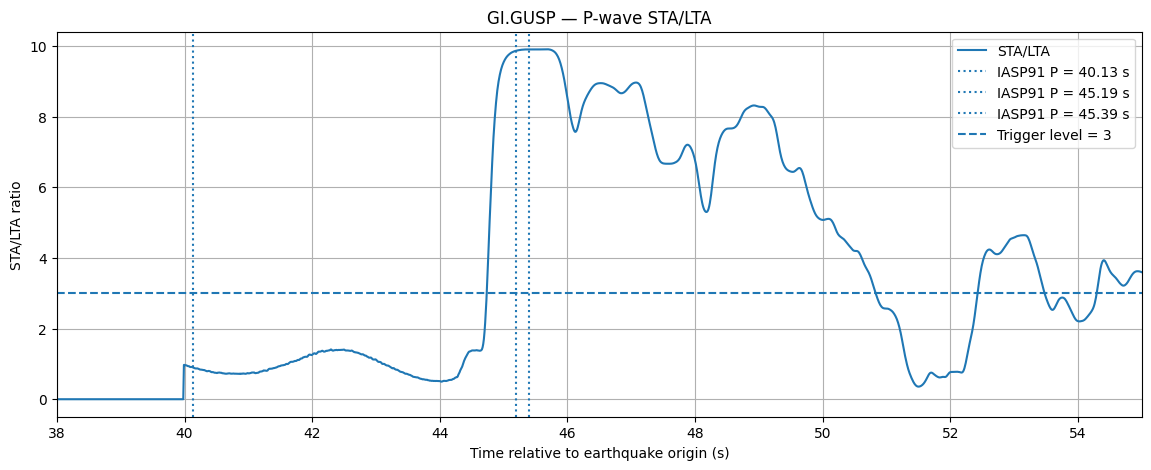

In [115]:
from obspy.signal.trigger import classic_sta_lta

tr_pick = all_waveforms["GI.GUSP"][0].copy()

print(tr_pick.id)

tr_pick.detrend("linear")

tr_pick.trim(
    starttime=event_time + 30,
    endtime=event_time + 60
)

df = tr_pick.stats.sampling_rate

sta_seconds = 1
lta_seconds = 10

sta_samples = int(sta_seconds * df)
lta_samples = int(lta_seconds * df)

cft = classic_sta_lta(
    tr_pick.data,
    sta_samples,
    lta_samples
)

time = np.arange(len(cft)) / df + 30

plt.figure(figsize=(14, 5))

plt.plot(time, cft, label="STA/LTA")

for p in [40.13, 45.19, 45.39]:
    plt.axvline(
        p,
        linestyle=":",
        label=f"IASP91 P = {p:.2f} s"
    )

plt.axhline(
    3,
    linestyle="--",
    label="Trigger level = 3"
)

plt.xlim(38, 55)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("STA/LTA ratio")
plt.title("GI.GUSP — P-wave STA/LTA")
plt.legend()
plt.grid()
plt.show()

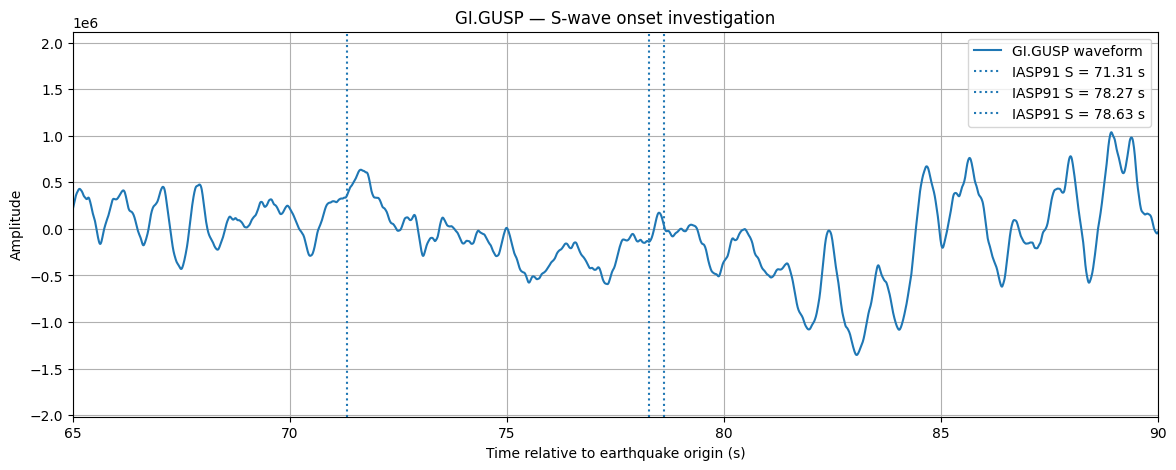

In [116]:
tr = all_waveforms["GI.GUSP"][0].copy()
tr.detrend("linear")

times = tr.times(reftime=event_time)

s_arrivals = [71.31, 78.27, 78.63]

plt.figure(figsize=(14, 5))

plt.plot(times, tr.data, label="GI.GUSP waveform")

for s in s_arrivals:
    plt.axvline(
        s,
        linestyle=":",
        label=f"IASP91 S = {s:.2f} s"
    )

plt.xlim(65, 90)

plt.xlabel("Time relative to earthquake origin (s)")
plt.ylabel("Amplitude")
plt.title("GI.GUSP — S-wave onset investigation")
plt.legend()
plt.grid()
plt.show()


In [117]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Station": [
        "GI.HUCU",
        "GI.SUCU",
        "GI.GUVC",
        "GI.QCIX",
        "GI.GUSP",
        "GI.SROR",
        "GI.AVCS",
        "SV.NUBE",
        "SV.RBDL"
    ],

    "Distance_deg": [
        1.2881,
        1.3579,
        2.3833,
        2.5471,
        2.5584,
        2.6962,
        2.8735,
        3.1539,
        3.2079
    ],

    "P_obs_s": [
        24.5,
        25.8,
        np.nan,
        np.nan,
        45.1,
        47.5,
        50.6,
        55.0,
        56.3
    ],

    "S_obs_s": [
        41.0,
        43.7,
        np.nan,
        np.nan,
        np.nan,
        84.8,
        np.nan,
        97.6,
        97.6
    ]
})

results["S_minus_P_s"] = results["S_obs_s"] - results["P_obs_s"]

results

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s
0,GI.HUCU,1.2881,24.5,41.0,16.5
1,GI.SUCU,1.3579,25.8,43.7,17.9
2,GI.GUVC,2.3833,NaN,NaN,NaN
3,GI.QCIX,2.5471,NaN,NaN,NaN
4,GI.GUSP,2.5584,45.1,NaN,NaN
5,GI.SROR,2.6962,47.5,84.8,37.3
6,GI.AVCS,2.8735,50.6,NaN,NaN
7,SV.NUBE,3.1539,55.0,97.6,42.6
8,SV.RBDL,3.2079,56.3,97.6,41.3


In [118]:
# Keep only stations having both P and S picks

sp_data = results.dropna(subset=["P_obs_s", "S_obs_s"]).copy()

print(sp_data)

   Station  Distance_deg  P_obs_s  S_obs_s  S_minus_P_s
0  GI.HUCU        1.2881     24.5     41.0         16.5
1  GI.SUCU        1.3579     25.8     43.7         17.9
5  GI.SROR        2.6962     47.5     84.8         37.3
7  SV.NUBE        3.1539     55.0     97.6         42.6
8  SV.RBDL        3.2079     56.3     97.6         41.3


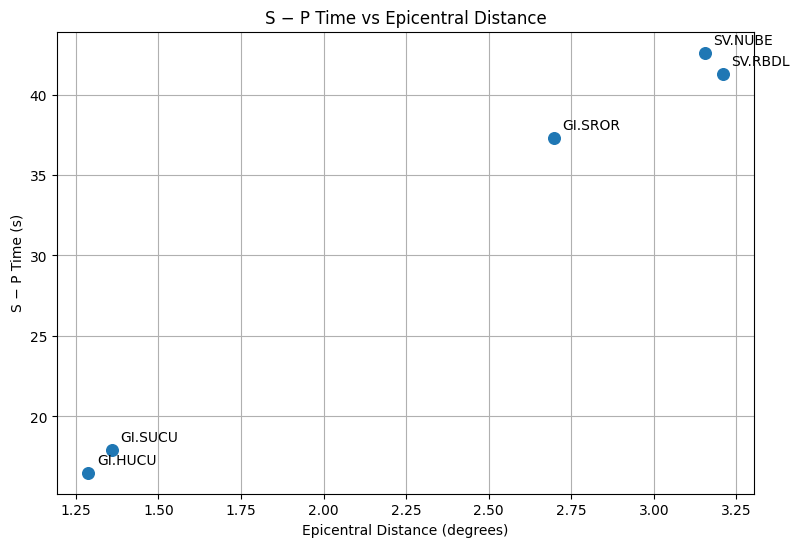

In [119]:
plt.figure(figsize=(9, 6))

plt.scatter(
    sp_data["Distance_deg"],
    sp_data["S_minus_P_s"],
    s=70
)

for _, row in sp_data.iterrows():
    plt.annotate(
        row["Station"],
        (row["Distance_deg"], row["S_minus_P_s"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("S − P Time (s)")
plt.title("S − P Time vs Epicentral Distance")
plt.grid()

plt.show()

In [121]:
# Generate IASP91 theoretical S-P times

dist_range = np.linspace(1.0, 3.5, 150)

theoretical_sp = []

for distance in dist_range:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P", "S"]
    )

    p_arrivals = [a.time for a in arrivals if a.name.startswith("P")]
    s_arrivals = [a.time for a in arrivals if a.name.startswith("S")]

    if p_arrivals and s_arrivals:
        # Use the earliest P and earliest S arrivals
        p_time = min(p_arrivals)
        s_time = min(s_arrivals)

        theoretical_sp.append(s_time - p_time)
    else:
        theoretical_sp.append(np.nan)

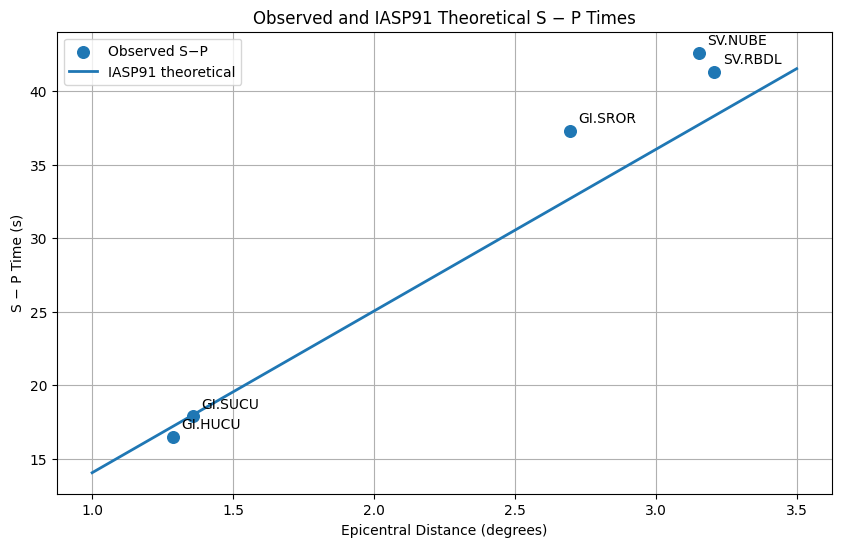

In [122]:
plt.figure(figsize=(10, 6))

# Observed data
plt.scatter(
    sp_data["Distance_deg"],
    sp_data["S_minus_P_s"],
    s=70,
    label="Observed S−P"
)

# Station labels
for _, row in sp_data.iterrows():
    plt.annotate(
        row["Station"],
        (row["Distance_deg"], row["S_minus_P_s"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# IASP91 theoretical curve
plt.plot(
    dist_range,
    theoretical_sp,
    linewidth=2,
    label="IASP91 theoretical"
)

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("S − P Time (s)")
plt.title("Observed and IASP91 Theoretical S − P Times")
plt.legend()
plt.grid()

plt.show()

In [123]:
# Calculating theoretical S-P time at each observed station distance

sp_comparison = sp_data.copy()

theoretical_values = []

for distance in sp_comparison["Distance_deg"]:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P", "S"]
    )

    p_arrivals = [a.time for a in arrivals if a.name.startswith("P")]
    s_arrivals = [a.time for a in arrivals if a.name.startswith("S")]

    p_theory = min(p_arrivals)
    s_theory = min(s_arrivals)

    theoretical_values.append(s_theory - p_theory)

sp_comparison["SP_theory_s"] = theoretical_values

sp_comparison["SP_residual_s"] = (
    sp_comparison["S_minus_P_s"]
    - sp_comparison["SP_theory_s"]
)

sp_comparison

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s,SP_theory_s,SP_residual_s
0,GI.HUCU,1.2881,24.5,41.0,16.5,17.230732,-0.730732
1,GI.SUCU,1.3579,25.8,43.7,17.9,17.997358,-0.097358
5,GI.SROR,2.6962,47.5,84.8,37.3,32.694360,4.605640
7,SV.NUBE,3.1539,55.0,97.6,42.6,37.718580,4.881420
8,SV.RBDL,3.2079,56.3,97.6,41.3,38.311239,2.988761


In [124]:
# Residual statistics

mean_residual = sp_comparison["SP_residual_s"].mean()
mean_abs_residual = sp_comparison["SP_residual_s"].abs().mean()
rmse = np.sqrt(
    np.mean(sp_comparison["SP_residual_s"]**2)
)

print(f"Mean residual      = {mean_residual:.3f} s")
print(f"Mean absolute error = {mean_abs_residual:.3f} s")
print(f"RMSE                = {rmse:.3f} s")

Mean residual      = 2.330 s
Mean absolute error = 2.661 s
RMSE                = 3.302 s


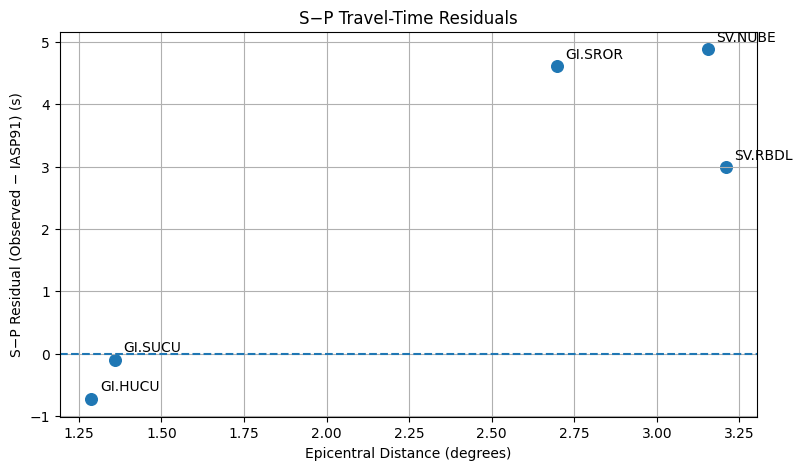

In [125]:
plt.figure(figsize=(9, 5))

plt.axhline(0, linestyle="--")

plt.scatter(
    sp_comparison["Distance_deg"],
    sp_comparison["SP_residual_s"],
    s=70
)

for _, row in sp_comparison.iterrows():
    plt.annotate(
        row["Station"],
        (row["Distance_deg"], row["SP_residual_s"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("S−P Residual (Observed − IASP91) (s)")
plt.title("S−P Travel-Time Residuals")
plt.grid()
plt.show()

In [126]:
# Stations with reliable observed P picks

p_data = results.dropna(subset=["P_obs_s"]).copy()

p_theory = []

for distance in p_data["Distance_deg"]:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    # Earliest theoretical P arrival
    p_time = min(a.time for a in arrivals)

    p_theory.append(p_time)

p_data["P_theory_s"] = p_theory

p_data["P_residual_s"] = (
    p_data["P_obs_s"] - p_data["P_theory_s"]
)

p_data

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s,P_theory_s,P_residual_s
0,GI.HUCU,1.2881,24.5,41.0,16.5,22.655713,1.844287
1,GI.SUCU,1.3579,25.8,43.7,17.9,23.615735,2.184265
4,GI.GUSP,2.5584,45.1,NaN,NaN,40.125884,4.974116
5,GI.SROR,2.6962,47.5,84.8,37.3,42.020904,5.479096
6,GI.AVCS,2.8735,50.6,NaN,NaN,44.458944,6.141056
7,SV.NUBE,3.1539,55.0,97.6,42.6,48.314495,6.685505
8,SV.RBDL,3.2079,56.3,97.6,41.3,49.056987,7.243013


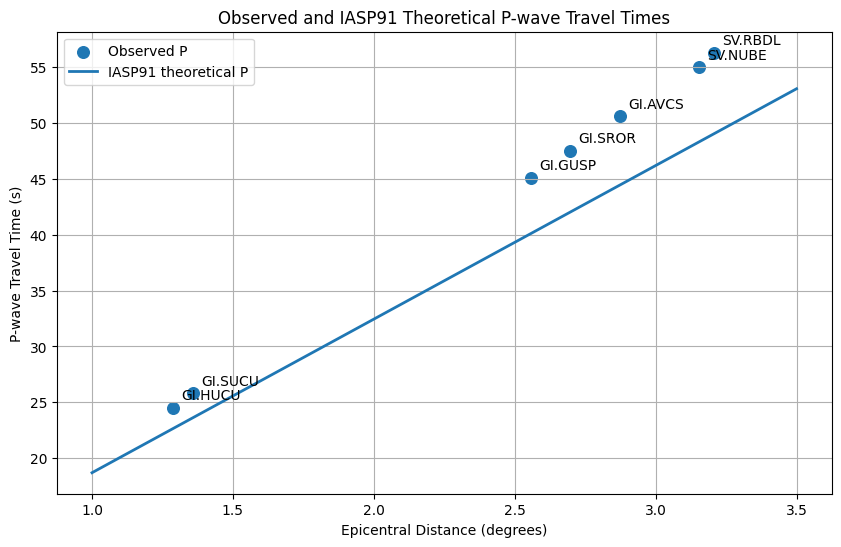

In [127]:
# Generate smooth IASP91 P-wave travel-time curve

dist_range = np.linspace(1.0, 3.5, 150)

p_curve = []

for distance in dist_range:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    p_curve.append(
        min(a.time for a in arrivals)
    )


plt.figure(figsize=(10, 6))

# Observed P picks
plt.scatter(
    p_data["Distance_deg"],
    p_data["P_obs_s"],
    s=70,
    label="Observed P"
)

# Station names
for _, row in p_data.iterrows():
    plt.annotate(
        row["Station"],
        (row["Distance_deg"], row["P_obs_s"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# IASP91 curve
plt.plot(
    dist_range,
    p_curve,
    linewidth=2,
    label="IASP91 theoretical P"
)

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("P-wave Travel Time (s)")
plt.title("Observed and IASP91 Theoretical P-wave Travel Times")
plt.legend()
plt.grid()

plt.show()

In [128]:
# Generate the SECOND IASP91 P-arrival curve

dist_range = np.linspace(1.0, 3.5, 150)

p_second_curve = []

for distance in dist_range:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    p_arrivals = sorted(
        [a.time for a in arrivals if a.name.startswith("P")]
    )

    if len(p_arrivals) >= 2:
        p_second_curve.append(p_arrivals[1])
    else:
        p_second_curve.append(np.nan)

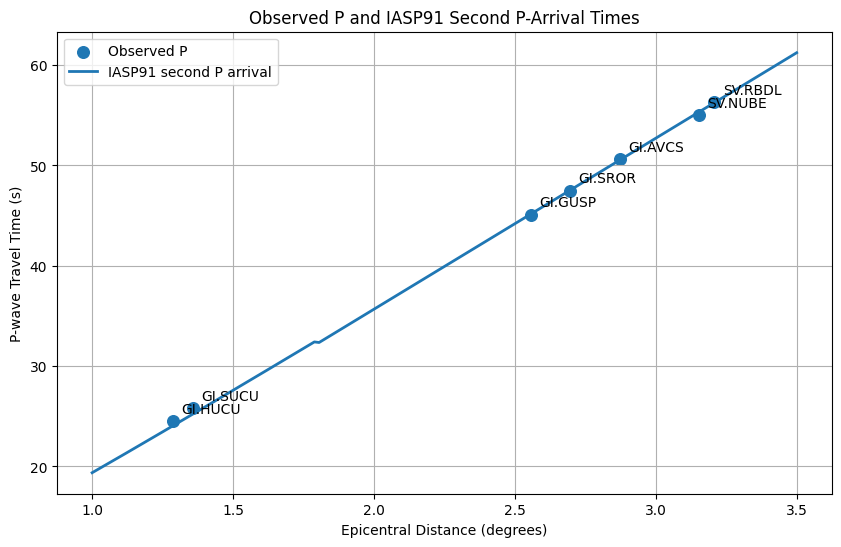

In [129]:
plt.figure(figsize=(10, 6))

# Observed P
plt.scatter(
    p_data["Distance_deg"],
    p_data["P_obs_s"],
    s=70,
    label="Observed P"
)

# Station labels
for _, row in p_data.iterrows():
    plt.annotate(
        row["Station"],
        (row["Distance_deg"], row["P_obs_s"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Second theoretical P branch
plt.plot(
    dist_range,
    p_second_curve,
    linewidth=2,
    label="IASP91 second P arrival"
)

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("P-wave Travel Time (s)")
plt.title("Observed P and IASP91 Second P-Arrival Times")
plt.legend()
plt.grid()

plt.show()

In [130]:
p_comparison = p_data.copy()

second_p_values = []

for distance in p_comparison["Distance_deg"]:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    p_arrivals = sorted(
        [a.time for a in arrivals if a.name.startswith("P")]
    )

    second_p_values.append(p_arrivals[1])

p_comparison["P_theory_second_s"] = second_p_values

p_comparison["P_residual_second_s"] = (
    p_comparison["P_obs_s"]
    - p_comparison["P_theory_second_s"]
)

p_comparison

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s,P_theory_s,P_residual_s,P_theory_second_s,P_residual_second_s
0,GI.HUCU,1.2881,24.5,41.0,16.5,22.655713,1.844287,24.069595,0.430405
1,GI.SUCU,1.3579,25.8,43.7,17.9,23.615735,2.184265,25.223082,0.576918
4,GI.GUSP,2.5584,45.1,NaN,NaN,40.125884,4.974116,45.188101,-0.088101
5,GI.SROR,2.6962,47.5,84.8,37.3,42.020904,5.479096,47.537127,-0.037127
6,GI.AVCS,2.8735,50.6,NaN,NaN,44.458944,6.141056,50.559420,0.040580
7,SV.NUBE,3.1539,55.0,97.6,42.6,48.314495,6.685505,55.338994,-0.338994
8,SV.RBDL,3.2079,56.3,97.6,41.3,49.056987,7.243013,56.259426,0.040574


In [131]:
p_mean_residual = p_comparison["P_residual_second_s"].mean()

p_mae = p_comparison["P_residual_second_s"].abs().mean()

p_rmse = np.sqrt(
    np.mean(p_comparison["P_residual_second_s"]**2)
)

print(f"Mean P residual       = {p_mean_residual:.3f} s")
print(f"Mean absolute P error = {p_mae:.3f} s")
print(f"P-wave RMSE           = {p_rmse:.3f} s")

Mean P residual       = 0.089 s
Mean absolute P error = 0.222 s
P-wave RMSE           = 0.304 s


In [132]:
# Compare observed S picks with the second IASP91 S arrival

s_data = results.dropna(subset=["S_obs_s"]).copy()

s_theory_second = []

for distance in s_data["Distance_deg"]:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["S"]
    )

    s_arrivals = sorted(
        [a.time for a in arrivals if a.name.startswith("S")]
    )

    if len(s_arrivals) >= 2:
        s_theory_second.append(s_arrivals[1])
    else:
        s_theory_second.append(np.nan)

s_data["S_theory_second_s"] = s_theory_second

s_data["S_residual_second_s"] = (
    s_data["S_obs_s"]
    - s_data["S_theory_second_s"]
)

s_data

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s,S_theory_second_s,S_residual_second_s
0,GI.HUCU,1.2881,24.5,41.0,16.5,41.671823,-0.671823
1,GI.SUCU,1.3579,25.8,43.7,17.9,43.670649,0.029351
5,GI.SROR,2.6962,47.5,84.8,37.3,82.343114,2.456886
7,SV.NUBE,3.1539,55.0,97.6,42.6,95.866405,1.733595
8,SV.RBDL,3.2079,56.3,97.6,41.3,97.461817,0.138183


In [133]:
sp_data = results.dropna(subset=["P_obs_s", "S_obs_s"]).copy()

model = TauPyModel(model="iasp91")

sp_theory = []

for distance in sp_data["Distance_deg"]:

    arrivals = model.get_travel_times(
        source_depth_in_km=22.0,
        distance_in_degree=distance,
        phase_list=["P", "S"]
    )

    p_arrivals = sorted([a.time for a in arrivals if a.name.startswith("P")])
    s_arrivals = sorted([a.time for a in arrivals if a.name.startswith("S")])

    P2 = p_arrivals[1]
    S2 = s_arrivals[1]

    sp_theory.append(S2 - P2)

sp_data["SP_theory_s"] = sp_theory

sp_data["SP_residual_s"] = (
    sp_data["S_minus_P_s"] - sp_data["SP_theory_s"]
)

sp_data

,Station,Distance_deg,P_obs_s,S_obs_s,S_minus_P_s,SP_theory_s,SP_residual_s
0,GI.HUCU,1.2881,24.5,41.0,16.5,17.602228,-1.102228
1,GI.SUCU,1.3579,25.8,43.7,17.9,18.447567,-0.547567
5,GI.SROR,2.6962,47.5,84.8,37.3,34.805987,2.494013
7,SV.NUBE,3.1539,55.0,97.6,42.6,40.527411,2.072589
8,SV.RBDL,3.2079,56.3,97.6,41.3,41.202390,0.097610


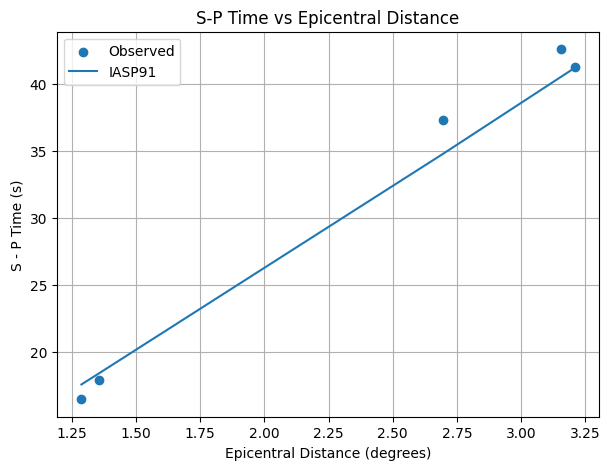

In [134]:
plt.figure(figsize=(7,5))

plt.scatter(
    sp_data["Distance_deg"],
    sp_data["S_minus_P_s"],
    label="Observed"
)

plt.plot(
    sp_data["Distance_deg"],
    sp_data["SP_theory_s"],
    label="IASP91"
)

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("S - P Time (s)")
plt.title("S-P Time vs Epicentral Distance")
plt.legend()
plt.grid()
plt.show()

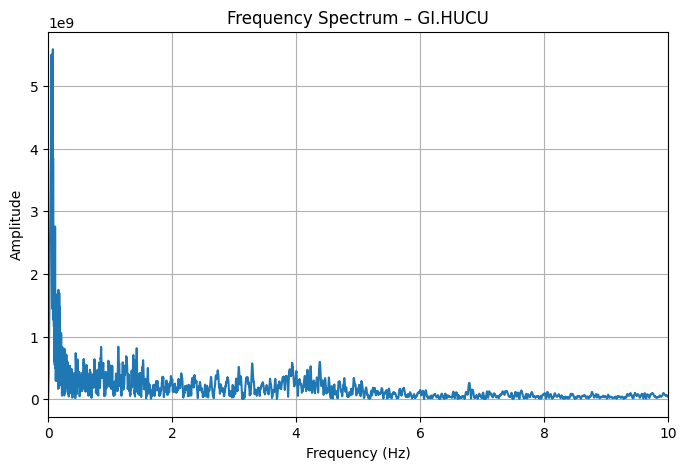

In [135]:
tr = st_processed[0]

data = tr.data
n = len(data)
dt = tr.stats.delta

freq = np.fft.rfftfreq(n, d=dt)
spectrum = np.abs(np.fft.rfft(data))

plt.figure(figsize=(8,5))
plt.plot(freq, spectrum)

plt.xlim(0, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum – GI.HUCU")
plt.grid()
plt.show()